# What Builds Democratic Connection?  
## ESS11 Germany Analysis Notebook

## 0. Analytical Logic and Process Map

This notebook follows a structured analytical pipeline from raw survey data to evidence-informed democratic engagement insights.

The goal is not only to describe attitudes toward democracy, but to understand how different dimensions of democratic connection relate to each other. The analysis therefore moves step by step from selected survey indicators to validated trust gaps, regression models, exploratory profiles and strategic implications.

The core logic is:

> Raw survey data → selected indicators → constructed indices → group comparisons → statistical validation → regression models → democratic connection profiles → strategic implications

```mermaid
flowchart TD

A[ESS Round 11 Germany Data<br/>Germany subset: n = 2,420] --> B[Variable Selection]

B --> C1[Democratic Trust Outcomes]
B --> C2[Explanatory Factors]
B --> C3[Participation Variable]
B --> C4[Control Variables]

C1 --> D1[Democracy Satisfaction<br/>stfdem]
C1 --> D2[Trust in Parliament<br/>trstprl]
C1 --> D3[Trust in Politicians<br/>trstplt]
C1 --> D4[Trust in Political Parties<br/>trstprt]

C2 --> E1[Political Efficacy Index]
C2 --> E2[Social Trust Index]
C2 --> E3[Income Feeling<br/>hincfel]
C2 --> E4[Left-Right Placement<br/>lrscale]

C3 --> F1[Voting Behavior<br/>Voted vs Did not vote]

C4 --> G1[Age]
C4 --> G2[Gender]
C4 --> G3[Education]

E1 --> H1[Political Efficacy Groups<br/>Low / Medium / High]
E2 --> H2[Social Trust Groups<br/>Low / Medium / High]
E3 --> H3[Economic Security Groups<br/>Secure or coping / Strained]
E4 --> H4[Political Orientation Groups<br/>Left / Center / Right]
F1 --> H5[Participation Groups<br/>Voted / Did not vote]

H1 --> I[Hypothesis Testing]
H2 --> I
H3 --> I
H4 --> I
H5 --> I

I --> J[Effect Size Interpretation]
J --> K[Regression Models]
K --> L[Democratic Connection Profiles]
L --> M[PCA Visualization]
M --> N[Strategic Interpretation]
```

### Analytical Building Blocks

| Analytical layer | What it does | Main output |
|---|---|---|
| Data selection | Filters the ESS Round 11 dataset for Germany and selects relevant variables | Germany analysis subset |
| Data cleaning | Removes missing values for specific analyses and recodes key variables | Clean analysis datasets |
| Index construction | Combines several ESS items into broader analytical indicators | Political efficacy index and social trust index |
| Exploratory analysis | Identifies first visible patterns in democratic trust and participation | Descriptive tables and visualizations |
| Group comparisons | Compares trust outcomes across meaningful groups | Trust gap tables |
| Statistical validation | Tests whether observed differences are statistically meaningful | Welch’s t-tests, Kruskal-Wallis tests, effect sizes |
| Regression modeling | Tests whether key associations remain visible when controlling for other variables | OLS regression models |
| Clustering | Groups respondents into exploratory democratic connection profiles | Three Democratic Connection Profiles |
| PCA visualization | Reduces multidimensional profile structure into visual components | 2D and 3D profile maps |
| Strategy interpretation | Translates analytical patterns into democratic engagement priorities | Strategic profile recommendations |

### Conceptual Logic

The project defines democratic connection as a combination of several measurable dimensions:

- satisfaction with democracy
- trust in political institutions and parties
- perceived political efficacy
- social trust
- economic security
- political participation

The analysis tests whether weaker democratic connection is associated with specific factors such as low political efficacy, low social trust, economic strain, non-voting or political self-placement.

The central assumption is:

> Democratic disconnection is not one single problem. Different forms of disconnection may require different democratic responses.

### Main Hypotheses

| Hypothesis | Analytical comparison | Method |
|---|---|---|
| Participation Gap | Voters vs non-voters | Welch’s t-test and Cohen’s d |
| Political Efficacy Gap | Low, medium and high political efficacy groups | Kruskal-Wallis test and epsilon-squared |
| Social Trust Gap | Low, medium and high social trust groups | Kruskal-Wallis test and epsilon-squared |
| Economic Security Gap | Economically secure/coping vs economically strained respondents | Welch’s t-test and Cohen’s d |
| Political Orientation Pattern | Left, center and right self-placement groups | Kruskal-Wallis test and epsilon-squared |

### How to Read the Results

The analysis is based on cross-sectional survey data. Therefore, the results show associations, not causal effects.

Statistical significance indicates whether observed differences are unlikely to be random. Effect sizes indicate whether these differences are also practically meaningful.

The regression models help assess whether political efficacy and social trust remain important when other variables are considered at the same time.

The cluster analysis is exploratory. The Democratic Connection Profiles should be understood as analytical segmentation patterns, not as fixed social groups.

### Core Analytical Story

The project starts from the question of what builds or weakens democratic connection in Germany.

The strongest emerging signals are political efficacy and social trust. Respondents who feel politically influential and socially trusting tend to show higher democratic satisfaction and higher trust in political parties and institutions.

The profile analysis adds a strategic layer. It shows that democratic disconnection is not only visible among non-voters. A large group still participates electorally but already shows low democratic satisfaction, low party trust and lower political efficacy.

This supports the main project argument:

> To strengthen democracy, democratic actors should not only communicate better. They need to rebuild political efficacy, social confidence and credible democratic responsiveness.

## 1. Import libraries

This step loads the Python libraries needed for reading the ESS11 SPSS file, handling tabular data, working with file paths, and exporting results.

In [1]:
pip install pyreadstat pandas openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
conda install -c conda-forge pyreadstat pandas openpyxl

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


## 2. Define file path

This step defines the path to the downloaded ESS11 SPSS file.  
Using `Path()` makes the file path easier to manage across different operating systems and project folders.

## 3. Load ESS11 SPSS data

This step loads the official ESS11 dataset from the `.sav` file.  
`pyreadstat.read_sav()` returns two objects:  
`df` contains the actual survey data, while `meta` contains metadata such as variable labels and value labels.

## 4. Inspect dataset size

This step checks the overall size of the full ESS11 dataset.  
The output shows the number of rows/respondents and the number of columns/variables before filtering by country.

In [3]:
import pandas as pd
import pyreadstat
from pathlib import Path

data_path = Path("../data/raw/ESS11e04_1.sav")

df, meta = pyreadstat.read_sav(data_path)

print("Dataset shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset shape: (50116, 691)
Rows: 50116
Columns: 691


## 5. Check available countries

This step shows how many respondents are included for each country.  
The country variable `cntry` is used to identify Germany and possible comparison countries for later analysis.

In [4]:
df["cntry"].value_counts().sort_index()

cntry
AT    2354
BE    1594
BG    2239
CH    1384
CY     685
DE    2420
EE    1293
ES    1844
FI    1563
FR    1771
GB    1684
GR    2757
HR    1563
HU    2118
IE    2017
IL     906
IS     842
IT    2865
LT    1365
LV    1252
ME    1609
NL    1695
NO    1337
PL    1442
PT    1373
RS    1563
SE    1230
SI    1248
SK    1442
UA    2661
Name: count, dtype: int64

## 6. Filter dataset for Germany

This step creates a Germany-only dataset by filtering the integrated ESS11 dataset where `cntry == "DE"`.  
This Germany subset will be used as the main dataset for the first stage of analysis.

In [5]:
df_de = df[df["cntry"] == "DE"].copy()

print("Germany rows:", df_de.shape[0])
print("Germany columns:", df_de.shape[1])

Germany rows: 2420
Germany columns: 691


## 8. Create a column overview

This step creates an overview table for all variables in the Germany dataset.  
For each variable, it shows the column name, data type, variable label, number and percentage of missing values, and number of unique values.

## 9. Display first variables in the column overview

This step displays the first rows of the variable overview.  
It helps to understand the structure of the dataset and identify potentially relevant variables for the capstone analysis.

In [6]:
columns_snapshot = pd.DataFrame({
    "column": df_de.columns,
    "dtype": [df_de[col].dtype for col in df_de.columns],
    "label": [meta.column_names_to_labels.get(col, "") for col in df_de.columns],
    "missing_count": [df_de[col].isna().sum() for col in df_de.columns],
    "missing_percent": [round(df_de[col].isna().mean() * 100, 2) for col in df_de.columns],
    "unique_values": [df_de[col].nunique(dropna=True) for col in df_de.columns]
})

columns_snapshot.head(50)

,column,dtype,label,missing_count,missing_percent,unique_values
0,name,str,Title of dataset,0,0.00,1
1,essround,float64,ESS round,0,0.00,1
2,edition,str,Edition,0,0.00,1
3,proddate,str,Production date,0,0.00,1
4,idno,float64,Respondent's identification number,0,0.00,2420
5,cntry,str,Country,0,0.00,1
6,dweight,float64,Design weight,0,0.00,20
7,pspwght,float64,Post-stratification weight including design we...,0,0.00,319
8,pweight,float64,Population size weight (must be combined with ...,0,0.00,1
9,anweight,float64,Analysis weight,0,0.00,319


## 10. Generate descriptive statistics for numeric variables

This step creates descriptive statistics for all numeric variables in the Germany dataset.  
The output includes count, mean, standard deviation, minimum, quartiles, and maximum values.

In [7]:
describe_numeric = df_de.describe().T

describe_numeric.head(50)

,count,mean,min,25%,50%,75%,max,std
essround,2420.0,11.0,11.0,11.0,11.0,11.0,11.0,0.0
idno,2420.0,67782.440496,50004.0,58109.25,67615.5,77282.75,86478.0,10754.634848
dweight,2420.0,1.0,0.995869,0.995869,0.995869,0.995869,1.765337,0.019055
pspwght,2420.0,1.0,0.118618,0.259189,0.617519,1.054607,4.342649,1.162002
pweight,2420.0,2.99297,2.99297,2.99297,2.99297,2.99297,2.99297,0.0
anweight,2420.0,2.99297,0.355022,0.775745,1.848217,3.156407,12.997417,3.477836
nwspol,2417.0,234.664046,0.0,30.0,60.0,210.0,1200.0,341.647761
netusoft,2420.0,4.482645,1.0,5.0,5.0,5.0,5.0,1.177906
netustm,2075.0,232.55759,0.0,90.0,180.0,300.0,1440.0,195.431298
ppltrst,2420.0,5.189669,0.0,4.0,5.0,7.0,10.0,2.231343


## 11. Export dataset snapshot to Excel

This step exports the variable overview and descriptive statistics to an Excel file.  
The exported snapshot can be used for variable selection, documentation, and project planning.

In [8]:
output_path = Path("../data/processed/ess11_germany_snapshot.xlsx")

with pd.ExcelWriter(output_path) as writer:
    columns_snapshot.to_excel(writer, sheet_name="columns_overview", index=False)
    describe_numeric.to_excel(writer, sheet_name="describe_numeric")

print(f"Exported to: {output_path}")

Exported to: ../data/processed/ess11_germany_snapshot.xlsx


## 12. Define core variables for the capstone project

This step defines a first set of core variables related to trust in democracy, political orientation, socio-economic situation, education, age, and gender.  
These variables will be used for the initial analytical exploration.

## 13. Preview core variables

This step displays the first rows of the selected core variables.  
It provides a quick check that the variables are available, correctly selected, and plausible in their values.

In [9]:
core_vars = [
    "cntry",
    "trstprl",   # trust in parliament
    "trstplt",   # trust in politicians
    "trstprt",   # trust in political parties
    "stfdem",    # satisfaction with democracy
    "hincfel",   # feeling about household income
    "lrscale",   # left-right placement
    "eduyrs",    # years of education
    "agea",      # age
    "gndr"       # gender
]

df_de[core_vars].head()

,cntry,trstprl,trstplt,trstprt,stfdem,hincfel,lrscale,eduyrs,agea,gndr
8256,DE,7.0,5.0,5.0,8.0,1.0,5.0,17.0,34.0,1.0
8257,DE,4.0,5.0,3.0,7.0,2.0,3.0,17.0,42.0,2.0
8258,DE,8.0,7.0,7.0,5.0,2.0,5.0,5.0,41.0,1.0
8259,DE,7.0,8.0,7.0,8.0,1.0,5.0,13.0,58.0,2.0
8260,DE,7.0,7.0,7.0,8.0,1.0,6.0,17.0,40.0,1.0


## 14. Check missing values in core variables

This step checks how many values are missing for each selected core variable.  
This is important to assess whether the variables are reliable enough for further analysis.

In [10]:
df_de.shape

(2420, 691)

## 15. Check complete cases for core variables

This step checks how many respondents have valid values for all selected core variables.  
The comparison between all German respondents and complete cases indicates how much data would remain if missing values were removed.

In [11]:
df_de[core_vars].dropna().shape

(2267, 10)

In [12]:
print("Germany sample size:", df_de.shape[0])
print("Number of variables:", df_de.shape[1])

Germany sample size: 2420
Number of variables: 691


## 18. Inspect outcome variables

This step focuses on the main outcome variables: trust in parliament, trust in politicians, trust in political parties, and satisfaction with democracy.  
These variables represent the central dimensions of political trust and democratic satisfaction in the project.

In [13]:
df_core = df_de[core_vars].copy()

print("Rows before dropping missing values:", df_core.shape[0])
print("Rows after dropping missing values:", df_core.dropna().shape[0])

Rows before dropping missing values: 2420
Rows after dropping missing values: 2267


In [14]:
missing_core = pd.DataFrame({
    "missing_count": df_core.isna().sum(),
    "missing_percent": round(df_core.isna().mean() * 100, 2)
})

missing_core

,missing_count,missing_percent
cntry,0,0.00
trstprl,18,0.74
trstplt,19,0.79
trstprt,29,1.20
stfdem,21,0.87
hincfel,7,0.29
lrscale,103,4.26
eduyrs,7,0.29
agea,5,0.21
gndr,0,0.00


## 16. Create cleaned core dataset

This step creates a preliminary working dataset that contains only the selected core variables. Missing values are inspected before deciding which rows to remove for specific analyses.

In [15]:
print("Cleaned core dataset shape:", df_core.shape)

df_core.head()

Cleaned core dataset shape: (2420, 10)


,cntry,trstprl,trstplt,trstprt,stfdem,hincfel,lrscale,eduyrs,agea,gndr
8256,DE,7.0,5.0,5.0,8.0,1.0,5.0,17.0,34.0,1.0
8257,DE,4.0,5.0,3.0,7.0,2.0,3.0,17.0,42.0,2.0
8258,DE,8.0,7.0,7.0,5.0,2.0,5.0,5.0,41.0,1.0
8259,DE,7.0,8.0,7.0,8.0,1.0,5.0,13.0,58.0,2.0
8260,DE,7.0,7.0,7.0,8.0,1.0,6.0,17.0,40.0,1.0


## 17. Describe core variables

This step creates descriptive statistics for the cleaned core dataset.
The output helps to understand the distribution, average values, minimum, maximum and spread of the selected variables.

In [16]:
# Overview of core variables
df_core.describe().T

,count,mean,std,min,25%,50%,75%,max
trstprl,2402.0,5.049958,2.660899,0.0,3.0,5.0,7.0,10.0
trstplt,2401.0,4.004165,2.361317,0.0,2.0,4.0,6.0,10.0
trstprt,2391.0,3.974069,2.203306,0.0,2.0,4.0,6.0,10.0
stfdem,2399.0,5.696540,2.550334,0.0,4.0,6.0,8.0,10.0
hincfel,2413.0,1.596353,0.676804,1.0,1.0,2.0,2.0,4.0
lrscale,2317.0,4.548123,1.770499,0.0,3.0,5.0,5.0,10.0
eduyrs,2413.0,14.466639,3.425986,0.0,12.0,14.0,17.0,33.0
agea,2415.0,50.383851,18.997265,15.0,35.0,52.0,65.0,90.0
gndr,2420.0,1.498347,0.500101,1.0,1.0,1.0,2.0,2.0


In [17]:
# Valid sample size for each variable
valid_counts = pd.DataFrame({
    "valid_count": df_core.notna().sum(),
    "missing_count": df_core.isna().sum(),
    "missing_percent": round(df_core.isna().mean() * 100, 2),
    "unique_values": df_core.nunique(dropna=True)
})

valid_counts

,valid_count,missing_count,missing_percent,unique_values
cntry,2420,0,0.00,1
trstprl,2402,18,0.74,11
trstplt,2401,19,0.79,11
trstprt,2391,29,1.20,11
stfdem,2399,21,0.87,11
hincfel,2413,7,0.29,4
lrscale,2317,103,4.26,11
eduyrs,2413,7,0.29,30
agea,2415,5,0.21,76
gndr,2420,0,0.00,2


## 18. Inspect outcome variables

This step focuses on the main outcome variables of the project
trust in parliament, trust in politicians, trust in political parties and satisfaction with democracy.
These variables represent the central dimensions of political trust and democratic satisfaction.


In [18]:
# Valid cases for main outcome variables
outcome_vars = ["trstprl", "trstplt", "trstprt", "stfdem"]

df_de[outcome_vars].notna().sum()

trstprl    2402
trstplt    2401
trstprt    2391
stfdem     2399
dtype: int64

## 19. Check correlations between outcome variables

This step checks how strongly the main outcome variables are related to each other.
High correlations would suggest that institutional trust and democratic satisfaction are connected,
but not necessarily identical concepts.

In [19]:


df_core[outcome_vars].corr()

,trstprl,trstplt,trstprt,stfdem
trstprl,1.000000,0.771613,0.721631,0.653851
trstplt,0.771613,1.000000,0.840480,0.632722
trstprt,0.721631,0.840480,1.000000,0.601777
stfdem,0.653851,0.632722,0.601777,1.000000


## 20. Check relationships between trust and explanatory variables

This step explores first correlations between trust/democratic satisfaction and selected explanatory variables
The explanatory variables include household income feeling, left-right placement, education years and age.
This is an initial exploration and does not yet imply causality.

In [20]:
explanatory_vars = ["hincfel", "lrscale", "eduyrs", "agea"]

analysis_vars = outcome_vars + explanatory_vars

df_core[analysis_vars].corr()

,trstprl,trstplt,trstprt,stfdem,hincfel,lrscale,eduyrs,agea
trstprl,1.000000,0.771613,0.721631,0.653851,-0.182538,-0.195080,0.224896,-0.123936
trstplt,0.771613,1.000000,0.840480,0.632722,-0.170397,-0.175683,0.154994,-0.066447
trstprt,0.721631,0.840480,1.000000,0.601777,-0.139511,-0.141572,0.151442,-0.152002
stfdem,0.653851,0.632722,0.601777,1.000000,-0.194769,-0.162642,0.153029,-0.075538
hincfel,-0.182538,-0.170397,-0.139511,-0.194769,1.000000,0.029836,-0.227703,-0.037525
lrscale,-0.195080,-0.175683,-0.141572,-0.162642,0.029836,1.000000,-0.104152,0.052996
eduyrs,0.224896,0.154994,0.151442,0.153029,-0.227703,-0.104152,1.000000,-0.087068
agea,-0.123936,-0.066447,-0.152002,-0.075538,-0.037525,0.052996,-0.087068,1.000000


## 21. Create simple age groups

This step creates age groups to make group comparisons easier
Instead of analyzing every single age separately, respondents are grouped into broader age categories.

In [21]:

df_core["age_group"] = pd.cut(

    df_core["agea"],

    bins=[17, 29, 44, 59, 120],

    labels=["18-29", "30-44", "45-59", "60+"]

)

df_core[["agea", "age_group"]].head()

,agea,age_group
8256,34.0,30-44
8257,42.0,30-44
8258,41.0,30-44
8259,58.0,45-59
8260,40.0,30-44


## 22. Compare democratic satisfaction by age group

This step compares average satisfaction with democracy across age groups.
It gives a first indication of whether democratic satisfaction differs between younger, middle-aged and older respondents.

In [22]:
df_core.groupby("age_group", observed=False)["stfdem"].agg(

    ["count", "mean", "median", "std"]

).round(2)

,count,mean,median,std
age_group,,,,
18-29,363,6.13,7.0,2.30
30-44,530,5.66,6.0,2.50
45-59,578,5.50,6.0,2.75
60+,855,5.55,6.0,2.54


## 23. Compare trust in parliament by income feeling

This step compares average trust in parliament by respondents' subjective household income situation.
The goal is to explore whether people who feel economically more insecure also show lower levels of institutional trust.
This is an exploratory group comparison and does not imply causality.

In [23]:
df_core.groupby("hincfel")["trstprl"].agg(

    ["count", "mean", "median", "std"]

).round(2)

,count,mean,median,std
hincfel,,,,
1.0,1187,5.50,6.0,2.59
2.0,1026,4.69,5.0,2.60
3.0,142,4.24,4.0,2.89
4.0,40,3.42,3.5,2.92


## 24. Compare democratic satisfaction by left-right placement

This step compares average satisfaction with democracy across the political left-right scale.
The goal is to explore whether democratic satisfaction differs depending on respondents' political self-placement.
This helps identify whether dissatisfaction is concentrated more strongly in specific political orientation groups.

In [24]:
df_core.groupby("lrscale")["stfdem"].agg(

    ["count", "mean", "median", "std"]

).round(2)

,count,mean,median,std
lrscale,,,,
0.0,66,4.71,5.0,2.76
1.0,51,6.24,7.0,2.49
2.0,157,6.55,7.0,2.19
3.0,327,6.48,7.0,2.09
4.0,300,6.32,7.0,2.12
5.0,916,5.43,6.0,2.62
6.0,220,5.58,6.0,2.50
7.0,168,5.02,5.0,2.54
8.0,67,4.97,5.0,2.70


## 25. Export cleaned core dataset

This step exports the cleaned core dataset as a CSV file.
The exported dataset can later be used for further analysis, Tableau dashboards, SQL import, or documentation of the analytical workflow.
This creates a reproducible working dataset based on the selected core variables.

In [25]:
df_core.to_csv("../data/clean/ess11_germany_core_clean.csv", index=False)

print("Exported cleaned core dataset to ../data/ess11_germany_core_clean.csv")

Exported cleaned core dataset to ../data/ess11_germany_core_clean.csv


In [26]:
# Check whether variables containing "vote" exist in the dataset

vote_vars = [col for col in df_de.columns if "vote" in col.lower()]

vote_vars

['vote']

In [27]:
# %% [markdown]
# ## 26. Inspect vote variable
#
# This step checks the meaning, value labels and distribution of the `vote` variable.
# The variable is potentially important because it can connect political trust and democratic satisfaction
# with actual political participation.
#
# Before using it in the analysis, we inspect whether the values represent voting, non-voting,
# ineligibility, or missing/special response categories.

print("Variable label:")
print(meta.column_names_to_labels.get("vote"))

print("\nValue labels:")
print(meta.variable_value_labels.get("vote"))

print("\nDistribution:")
print(df_de["vote"].value_counts(dropna=False).sort_index())

Variable label:
Voted last national election

Value labels:
{1.0: 'Yes', 2.0: 'No', 3.0: 'Not eligible to vote', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
vote
1.0    1906
2.0     254
3.0     255
NaN       5
Name: count, dtype: int64


In [28]:
# %% [markdown]
# ## 27. Clean vote variable
#
# This step creates a cleaned voting variable.
# Only respondents who were eligible to vote are kept for voting-behavior analysis.
# `1 = voted` and `2 = did not vote` are recoded into readable labels.
# Respondents who were not eligible to vote are set to missing for this specific analysis.

df_de["vote_clean"] = df_de["vote"].map({
    1.0: "Voted",
    2.0: "Did not vote"
})

df_de["vote_clean"].value_counts(dropna=False)

vote_clean
Voted           1906
NaN              260
Did not vote     254
Name: count, dtype: int64

In [29]:
# %% [markdown]
# ## 28. Add cleaned vote variable to core variables
#
# This step adds the cleaned voting variable to the selected core variables.
# The cleaned variable allows the analysis to connect political trust and democratic satisfaction
# with actual voting participation among eligible respondents.

core_vars = [
    "cntry",
    "trstprl",       # trust in parliament
    "trstplt",       # trust in politicians
    "trstprt",       # trust in political parties
    "stfdem",        # satisfaction with democracy
    "vote_clean",    # voted or did not vote in last national election
    "hincfel",       # feeling about household income
    "lrscale",       # left-right placement
    "eduyrs",        # years of education
    "agea",          # age
    "gndr"           # gender
]

df_core = df_de[core_vars].dropna().copy()

print("Updated cleaned core dataset shape:", df_core.shape)
df_core.head()

Updated cleaned core dataset shape: (2059, 11)


,cntry,trstprl,trstplt,trstprt,stfdem,vote_clean,hincfel,lrscale,eduyrs,agea,gndr
8256,DE,7.0,5.0,5.0,8.0,Voted,1.0,5.0,17.0,34.0,1.0
8257,DE,4.0,5.0,3.0,7.0,Voted,2.0,3.0,17.0,42.0,2.0
8259,DE,7.0,8.0,7.0,8.0,Voted,1.0,5.0,13.0,58.0,2.0
8260,DE,7.0,7.0,7.0,8.0,Voted,1.0,6.0,17.0,40.0,1.0
8261,DE,8.0,7.0,7.0,9.0,Voted,2.0,3.0,17.0,46.0,1.0


In [30]:
# %% [markdown]
# ## 29. Compare democratic satisfaction by voting behavior
#
# This step compares average satisfaction with democracy between respondents who voted
# and respondents who did not vote in the last national election.
# The goal is to explore whether democratic dissatisfaction is associated with lower political participation.

df_core.groupby("vote_clean")["stfdem"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
vote_clean,,,,
Did not vote,227,4.42,4.0,2.68
Voted,1832,5.76,6.0,2.47


In [31]:
# %% [markdown]
# ## 30. Compare institutional trust by voting behavior
#
# This step compares average trust in parliament, politicians and political parties
# between voters and non-voters.
# This helps assess whether lower institutional trust is associated with democratic disengagement.

df_core.groupby("vote_clean")[["trstprl", "trstplt", "trstprt"]].mean().round(2)

,trstprl,trstplt,trstprt
vote_clean,,,
Did not vote,3.63,2.84,2.91
Voted,5.17,4.11,4.05


## 31. First interpretation: voting behavior and democratic trust

The first group comparisons show clear differences between voters and non-voters.

Respondents who reported that they voted in the last national election show higher average satisfaction with democracy and higher average trust in parliament, politicians and political parties.

The largest difference appears in trust in parliament, followed by satisfaction with democracy, trust in politicians and trust in political parties.

This suggests that political participation is associated with higher democratic satisfaction and institutional trust. However, this is an exploratory association and does not imply causality.

In [32]:
# Calculate group means and differences between voters and non-voters

trust_by_vote = df_core.groupby("vote_clean")[["stfdem", "trstprl", "trstplt", "trstprt"]].mean().round(2)

difference = (
    trust_by_vote.loc["Voted"] - trust_by_vote.loc["Did not vote"]
).round(2)

difference_table = pd.DataFrame({
    "Did not vote": trust_by_vote.loc["Did not vote"],
    "Voted": trust_by_vote.loc["Voted"],
    "Difference (Voted - Did not vote)": difference
})

difference_table

,Did not vote,Voted,Difference (Voted - Did not vote)
stfdem,4.42,5.76,1.34
trstprl,3.63,5.17,1.54
trstplt,2.84,4.11,1.27
trstprt,2.91,4.05,1.14


## 32. Define extended candidate variables

This step defines an extended set of candidate variables for the next stage of the analysis.

The goal is to move beyond the initial trust and democracy variables and include additional dimensions that are relevant for the updated project framing:

- party trust and institutional trust
- political efficacy and perceived responsiveness
- social trust
- voting behavior
- economic security
- political orientation
- socio-demographic context

This helps assess whether the ESS11 dataset can support the refined focus on democratic performance, party trust, political efficacy and social confidence.

In [33]:
new_candidate_vars = [
    "stfdem",
    "trstprl", "trstplt", "trstprt", "trstlgl", "trstplc", "trstep", "trstun",
    "ppltrst", "pplfair", "pplhlp",
    "polintr", "psppsgva", "psppipla", "cptppola", "actrolga",
    "hincfel", "lrscale", "eduyrs", "agea", "gndr",
    "vote", "vote_clean"
]

candidate_overview = pd.DataFrame({
    "column": new_candidate_vars,
    "label": [meta.column_names_to_labels.get(col, "created variable") for col in new_candidate_vars],
    "valid_count": [df_de[col].notna().sum() if col in df_de.columns else df_core[col].notna().sum() for col in new_candidate_vars],
    "missing_count": [df_de[col].isna().sum() if col in df_de.columns else df_core[col].isna().sum() for col in new_candidate_vars],
    "missing_percent": [round(df_de[col].isna().mean() * 100, 2) if col in df_de.columns else round(df_core[col].isna().mean() * 100, 2) for col in new_candidate_vars],
    "unique_values": [df_de[col].nunique(dropna=True) if col in df_de.columns else df_core[col].nunique(dropna=True) for col in new_candidate_vars]
})

candidate_overview

,column,label,valid_count,missing_count,missing_percent,unique_values
0,stfdem,How satisfied with the way democracy works in ...,2399,21,0.87,11
1,trstprl,Trust in country's parliament,2402,18,0.74,11
2,trstplt,Trust in politicians,2401,19,0.79,11
3,trstprt,Trust in political parties,2391,29,1.20,11
4,trstlgl,Trust in the legal system,2401,19,0.79,11
5,trstplc,Trust in the police,2414,6,0.25,11
6,trstep,Trust in the European Parliament,2357,63,2.60,11
7,trstun,Trust in the United Nations,2337,83,3.43,11
8,ppltrst,Most people can be trusted or you can't be too...,2420,0,0.00,11
9,pplfair,"Most people try to take advantage of you, or t...",2418,2,0.08,11


## 33. Inspect value labels of key variables

This step checks the value labels of the most important candidate variables.

This is necessary because many ESS variables use coded numerical scales. Before interpreting means, correlations or building indices, we need to understand what higher and lower values mean.

This is especially important for:

- household income feeling
- political interest
- political efficacy variables
- social trust variables

The output helps decide whether variables can be used directly or need to be recoded.

In [34]:
vars_to_check = [
    "hincfel",
    "polintr",
    "psppsgva",
    "psppipla",
    "cptppola",
    "actrolga",
    "ppltrst",
    "pplfair",
    "pplhlp"
]

for var in vars_to_check:
    print("\n" + "=" * 70)
    print("Variable:", var)
    print("Label:", meta.column_names_to_labels.get(var))
    print("Value labels:", meta.variable_value_labels.get(var))
    print("\nDistribution:")
    print(df_de[var].value_counts(dropna=False).sort_index())


Variable: hincfel
Label: Feeling about household's income nowadays
Value labels: {1.0: 'Living comfortably on present income', 2.0: 'Coping on present income', 3.0: 'Difficult on present income', 4.0: 'Very difficult on present income', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
hincfel
1.0    1196
2.0    1035
3.0     142
4.0      40
NaN       7
Name: count, dtype: int64

Variable: polintr
Label: How interested in politics
Value labels: {1.0: 'Very interested', 2.0: 'Quite interested', 3.0: 'Hardly interested', 4.0: 'Not at all interested', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
polintr
1.0    628
2.0    917
3.0    733
4.0    141
NaN      1
Name: count, dtype: int64

Variable: psppsgva
Label: Political system allows people to have a say in what government does
Value labels: {1.0: 'Not at all', 2.0: 'Very little', 3.0: 'Some', 4.0: 'A lot', 5.0: 'A great deal', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
pspp

## 34. Compare democratic satisfaction and institutional trust

This step compares the average values of democratic satisfaction and different trust variables.

The goal is to explore whether trust in political parties and politicians is lower than trust in other institutions.

This is important for the refined project framing around a possible party-trust gap or democratic performance gap.

The analysis is descriptive and does not imply causality.

In [35]:
trust_vars = [
    "stfdem",
    "trstprl",
    "trstplt",
    "trstprt",
    "trstlgl",
    "trstplc",
    "trstep",
    "trstun"
]

trust_summary = df_de[trust_vars].describe().T[
    ["count", "mean", "std", "min", "50%", "max"]
].round(2)

trust_summary

,count,mean,std,min,50%,max
stfdem,2399.0,5.70,2.55,0.0,6.0,10.0
trstprl,2402.0,5.05,2.66,0.0,5.0,10.0
trstplt,2401.0,4.00,2.36,0.0,4.0,10.0
trstprt,2391.0,3.97,2.20,0.0,4.0,10.0
trstlgl,2401.0,6.37,2.45,0.0,7.0,10.0
trstplc,2414.0,7.12,2.16,0.0,8.0,10.0
trstep,2357.0,4.60,2.51,0.0,5.0,10.0
trstun,2337.0,5.04,2.44,0.0,5.0,10.0


## 35. Create readable labels for trust variables

This step creates readable labels for the trust and democratic satisfaction variables.

These labels make tables and visualizations easier to interpret, especially for the final dashboard or presentation.

The original ESS variable names are technically precise, but they are not always intuitive for audiences.

In [36]:
trust_labels = {
    "stfdem": "Satisfaction with democracy",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties",
    "trstlgl": "Trust in legal system",
    "trstplc": "Trust in police",
    "trstep": "Trust in European Parliament",
    "trstun": "Trust in United Nations"
}

trust_summary_labeled = trust_summary.copy()
trust_summary_labeled["label"] = trust_summary_labeled.index.map(trust_labels)
trust_summary_labeled = trust_summary_labeled[
    ["label", "count", "mean", "std", "min", "50%", "max"]
]

trust_summary_labeled.sort_values("mean")

,label,count,mean,std,min,50%,max
trstprt,Trust in political parties,2391.0,3.97,2.20,0.0,4.0,10.0
trstplt,Trust in politicians,2401.0,4.00,2.36,0.0,4.0,10.0
trstep,Trust in European Parliament,2357.0,4.60,2.51,0.0,5.0,10.0
trstun,Trust in United Nations,2337.0,5.04,2.44,0.0,5.0,10.0
trstprl,Trust in parliament,2402.0,5.05,2.66,0.0,5.0,10.0
stfdem,Satisfaction with democracy,2399.0,5.70,2.55,0.0,6.0,10.0
trstlgl,Trust in legal system,2401.0,6.37,2.45,0.0,7.0,10.0
trstplc,Trust in police,2414.0,7.12,2.16,0.0,8.0,10.0


## 36. Visualize the party-trust and institutional-trust gap (initial rough visualization)

This step creates a first bar chart comparing democratic satisfaction and trust in different institutions.

The aim is to visually inspect whether trust in political parties and politicians is lower than trust in other institutions.

This directly supports the refined storyline around a possible performance gap or party-trust gap.

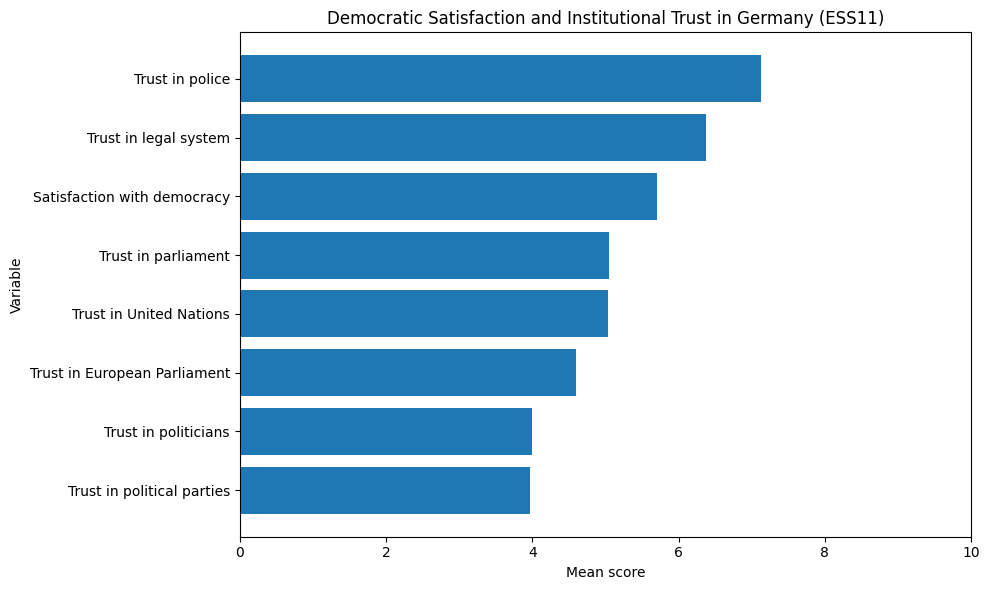

In [37]:
import matplotlib.pyplot as plt

plot_data = trust_summary_labeled.sort_values("mean", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_data["label"], plot_data["mean"])
plt.xlabel("Mean score")
plt.ylabel("Variable")
plt.title("Democratic Satisfaction and Institutional Trust in Germany (ESS11)")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

## 37. Check relationship between social trust and democratic trust

This step explores whether social trust is associated with democratic satisfaction and institutional trust.

The social trust variables are used as proxies for broader assumptions about whether people see others as trustworthy, fair and helpful.

This is relevant for the conceptual extension inspired by the idea that democratic confidence may be linked to broader social confidence.

This analysis is exploratory and does not prove causality.

In [38]:
social_trust_vars = ["ppltrst", "pplfair", "pplhlp"]
political_trust_vars = ["stfdem", "trstprl", "trstplt", "trstprt"]

social_political_corr = df_de[
    social_trust_vars + political_trust_vars
].corr().round(2)

social_political_corr

,ppltrst,pplfair,pplhlp,stfdem,trstprl,trstplt,trstprt
ppltrst,1.00,0.47,0.38,0.29,0.33,0.34,0.31
pplfair,0.47,1.00,0.42,0.28,0.28,0.30,0.29
pplhlp,0.38,0.42,1.00,0.24,0.26,0.30,0.28
stfdem,0.29,0.28,0.24,1.00,0.65,0.63,0.60
trstprl,0.33,0.28,0.26,0.65,1.00,0.77,0.72
trstplt,0.34,0.30,0.30,0.63,0.77,1.00,0.84
trstprt,0.31,0.29,0.28,0.60,0.72,0.84,1.00


## 38. Create a social trust index

This step creates a simple social trust index based on three ESS variables:

- whether most people can be trusted
- whether most people try to be fair
- whether most people are helpful

The index is calculated as the average of the three variables.

This index is used as a proxy for social confidence. It does not directly measure a philosophical view of human nature, but it helps analyze whether trust in people is associated with democratic trust.

In [39]:
df_de["social_trust_index"] = df_de[["ppltrst", "pplfair", "pplhlp"]].mean(axis=1)

df_de["social_trust_index"].describe()

count    2420.000000
mean        5.567011
std         1.642011
min         0.000000
25%         4.666667
50%         5.666667
75%         6.666667
max        10.000000
Name: social_trust_index, dtype: float64

## 39. Create social trust groups

This step divides respondents into three groups based on their social trust index:

- low social trust
- medium social trust
- high social trust

The goal is to compare democratic satisfaction and institutional trust across social trust groups.

This makes the analysis easier to interpret than using only continuous correlation values.

In [40]:
df_de["social_trust_group"] = pd.qcut(
    df_de["social_trust_index"],
    q=3,
    labels=["Low social trust", "Medium social trust", "High social trust"]
)

df_de["social_trust_group"].value_counts(dropna=False)

social_trust_group
Low social trust       900
Medium social trust    777
High social trust      743
Name: count, dtype: int64

## 40. Compare democratic trust by social trust group

This step compares democratic satisfaction and institutional trust across low, medium and high social trust groups.

The goal is to test whether people with higher social trust also show higher democratic satisfaction and higher trust in political institutions.

This supports the broader question of whether democratic confidence is connected to social confidence.

In [41]:
df_de.groupby("social_trust_group", observed=False)[
    ["stfdem", "trstprl", "trstplt", "trstprt"]
].agg(["count", "mean", "median", "std"]).round(2)

stfdem                    trstprl                     \
                     count  mean median   std   count  mean median   std   
social_trust_group                                                         
Low social trust       888  4.70    5.0  2.72     894  3.93    4.0  2.67   
Medium social trust    771  5.96    6.0  2.28     769  5.40    6.0  2.42   
High social trust      740  6.61    7.0  2.16     739  6.04    6.0  2.39   

                    trstplt                    trstprt                     
                      count  mean median   std   count  mean median   std  
social_trust_group                                                         
Low social trust        892  2.96    3.0  2.31     888  3.07    3.0  2.21  
Medium social trust     774  4.22    4.0  2.12     770  4.19    4.0  1.99  
High social trust       735  5.04    5.0  2.13     733  4.84    5.0  1.99

## 41. Check political efficacy variables

This step inspects the political efficacy variables in more detail.

Political efficacy refers to whether respondents feel that they can influence politics, have a say, and are able to participate.

This dimension is central for the updated project framing because it can help operationalize perceived democratic responsiveness and political agency.

In [42]:
efficacy_vars = ["psppsgva", "psppipla", "cptppola", "actrolga"]

for var in efficacy_vars:
    print("\n" + "=" * 70)
    print("Variable:", var)
    print("Label:", meta.column_names_to_labels.get(var))
    print("Value labels:", meta.variable_value_labels.get(var))
    print("\nDistribution:")
    print(df_de[var].value_counts(dropna=False).sort_index())


Variable: psppsgva
Label: Political system allows people to have a say in what government does
Value labels: {1.0: 'Not at all', 2.0: 'Very little', 3.0: 'Some', 4.0: 'A lot', 5.0: 'A great deal', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
psppsgva
1.0    391
2.0    785
3.0    873
4.0    307
5.0     32
NaN     32
Name: count, dtype: int64

Variable: psppipla
Label: Political system allows people to have influence on politics
Value labels: {1.0: 'Not at all', 2.0: 'Very little', 3.0: 'Some', 4.0: 'A lot', 5.0: 'A great deal', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answer'}

Distribution:
psppipla
1.0    379
2.0    804
3.0    898
4.0    295
5.0     24
NaN     20
Name: count, dtype: int64

Variable: cptppola
Label: Confident in own ability to participate in politics
Value labels: {1.0: 'Not at all confident', 2.0: 'A little confident', 3.0: 'Quite confident', 4.0: 'Very confident', 5.0: 'Completely confident', 7.0: 'Refusal', 8.0: "Don't know", 9.0: 'No answ

## 42. Confirm coding direction of political efficacy variables

This step confirms that the political efficacy variables are already coded in the correct direction.

For all selected political efficacy variables, higher values indicate higher perceived political efficacy:

- 1 means low efficacy, such as not at all, not at all confident, or not at all able.
- 5 means high efficacy, such as a great deal, completely confident, or completely able.

Therefore, no reverse-coding is needed.

This is important before creating the political efficacy index.

In [43]:
efficacy_vars = ["psppsgva", "psppipla", "cptppola", "actrolga"]

df_de[efficacy_vars].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
psppsgva,2388.0,2.50,0.96,1.0,2.0,3.0,3.0,5.0
psppipla,2400.0,2.49,0.93,1.0,2.0,3.0,3.0,5.0
cptppola,2384.0,2.66,1.01,1.0,2.0,3.0,3.0,5.0
actrolga,2400.0,2.29,1.06,1.0,1.0,2.0,3.0,5.0


## 43. Create a correctly coded political efficacy index

This step creates a political efficacy index based on the original ESS variables.

The selected variables are already coded so that higher values indicate higher perceived political efficacy.

The index summarizes whether respondents feel that the political system allows people to have a say, allows people to influence politics, and whether they feel confident and able to participate politically.

This index is used as a proxy for democratic self-efficacy and perceived political responsiveness.

In [44]:
df_de["political_efficacy_index"] = df_de[efficacy_vars].mean(axis=1)

df_de["political_efficacy_index"].describe()

count    2417.000000
mean        2.479313
std         0.729391
min         1.000000
25%         2.000000
50%         2.500000
75%         3.000000
max         5.000000
Name: political_efficacy_index, dtype: float64

## 44. Create political efficacy groups

This step divides respondents into three groups based on the correctly coded political efficacy index:

- low political efficacy
- medium political efficacy
- high political efficacy

Higher values indicate higher perceived political efficacy.

The goal is to compare democratic satisfaction and institutional trust across different levels of perceived political agency.

In [45]:
df_de["efficacy_group"] = pd.qcut(
    df_de["political_efficacy_index"],
    q=3,
    labels=["Low efficacy", "Medium efficacy", "High efficacy"]
)

df_de["efficacy_group"].value_counts(dropna=False)

efficacy_group
Low efficacy       1075
High efficacy       691
Medium efficacy     651
NaN                   3
Name: count, dtype: int64

## 45. Compare democratic trust by political efficacy group

This step compares democratic satisfaction and institutional trust across political efficacy groups.

The goal is to test whether people with lower perceived political influence also show lower trust in democracy, parliament, politicians and parties.

This analysis directly supports the hypothesis of a political efficacy or responsiveness gap.

The analysis is exploratory and does not imply causality.

In [46]:
df_de.groupby("efficacy_group", observed=False)[
    ["stfdem", "trstprl", "trstplt", "trstprt"]
].agg(["count", "mean", "median", "std"]).round(2)

stfdem                    trstprl                    trstplt  \
                 count  mean median   std   count  mean median   std   count   
efficacy_group                                                                 
Low efficacy      1057  4.82    5.0  2.60    1064  3.93    4.0  2.57    1066   
Medium efficacy    651  5.82    6.0  2.33     647  5.23    5.0  2.34     647   
High efficacy      690  6.92    7.0  2.11     689  6.61    7.0  2.22     688   

                                   trstprt                     
                 mean median   std   count  mean median   std  
efficacy_group                                                 
Low efficacy     3.12    3.0  2.32    1058  3.17    3.0  2.14  
Medium efficacy  4.15    4.0  2.08     646  4.10    4.0  1.96  
High efficacy    5.24    5.0  2.08     687  5.10    5.0  1.99

In [47]:
rev_cols = ["psppsgva_rev", "psppipla_rev", "cptppola_rev", "actrolga_rev"]

df_de = df_de.drop(columns=[col for col in rev_cols if col in df_de.columns])

## 46. Create grouped left-right political orientation variable

This step groups the left-right self-placement scale into broader categories.

The original scale from 0 to 10 contains small sample sizes at the extremes. Grouping makes the analysis more stable and easier to interpret.

The grouped variable will be used to compare democratic satisfaction and institutional trust across broader political orientation groups.

In [48]:
df_de["lr_group"] = pd.cut(
    df_de["lrscale"],
    bins=[-0.1, 3, 6, 10],
    labels=["Left (0-3)", "Center (4-6)", "Right (7-10)"]
)

df_de["lr_group"].value_counts(dropna=False)

lr_group
Center (4-6)    1444
Left (0-3)       602
Right (7-10)     271
NaN              103
Name: count, dtype: int64

## 47. Compare democratic trust by political orientation group

This step compares democratic satisfaction and institutional trust across broader left-right orientation groups.

The goal is to test whether trust and democratic satisfaction differ between respondents who place themselves on the left, center or right of the political spectrum.

This should be interpreted carefully and without causal or stigmatizing claims.

In [49]:
df_de.groupby("lr_group", observed=False)[
    ["stfdem", "trstprl", "trstplt", "trstprt"]
].agg(["count", "mean", "median", "std"]).round(2)

stfdem                    trstprl                    trstplt  \
              count  mean median   std   count  mean median   std   count   
lr_group                                                                    
Left (0-3)      601  6.28    7.0  2.30     601  5.75    6.0  2.47     601   
Center (4-6)   1436  5.64    6.0  2.53    1436  5.01    5.0  2.62    1436   
Right (7-10)    270  4.77    5.0  2.73     270  3.96    4.0  2.66     271   

                                trstprt                     
              mean median   std   count  mean median   std  
lr_group                                                    
Left (0-3)    4.60    5.0  2.21     598  4.42    5.0  2.04  
Center (4-6)  3.96    4.0  2.35    1432  3.96    4.0  2.19  
Right (7-10)  3.16    3.0  2.27     270  3.31    3.0  2.19

## 48. Create an extended clean analysis dataset

This step creates an extended clean dataset that includes the main variables for the refined project focus.

The dataset includes:

- democratic satisfaction
- institutional trust
- party and politician trust
- social trust index
- political efficacy index
- voting behavior
- income feeling
- political orientation
- education
- age
- gender

This dataset will be used for deeper analysis, visualizations and potential dashboard export.

In [50]:
extended_core_vars = [
    "cntry",
    "stfdem",
    "trstprl", "trstplt", "trstprt", "trstlgl", "trstplc", "trstep", "trstun",
    "social_trust_index", "social_trust_group",
    "political_efficacy_index", "efficacy_group",
    "vote_clean",
    "hincfel",
    "lrscale", "lr_group",
    "eduyrs",
    "agea",
    "gndr"
]

df_extended = df_de[extended_core_vars].dropna().copy()

print("Extended clean dataset shape:", df_extended.shape)
df_extended.head()

Extended clean dataset shape: (2004, 20)


,cntry,stfdem,trstprl,trstplt,trstprt,trstlgl,trstplc,trstep,trstun,social_trust_index,social_trust_group,political_efficacy_index,efficacy_group,vote_clean,hincfel,lrscale,lr_group,eduyrs,agea,gndr
8256,DE,8.0,7.0,5.0,5.0,7.0,8.0,6.0,6.0,3.333333,Low social trust,2.75,Medium efficacy,Voted,1.0,5.0,Center (4-6),17.0,34.0,1.0
8257,DE,7.0,4.0,5.0,3.0,8.0,8.0,3.0,7.0,7.333333,High social trust,2.75,Medium efficacy,Voted,2.0,3.0,Left (0-3),17.0,42.0,2.0
8259,DE,8.0,7.0,8.0,7.0,8.0,8.0,9.0,9.0,6.666667,High social trust,2.00,Low efficacy,Voted,1.0,5.0,Center (4-6),13.0,58.0,2.0
8260,DE,8.0,7.0,7.0,7.0,8.0,9.0,8.0,2.0,7.333333,High social trust,3.25,High efficacy,Voted,1.0,6.0,Center (4-6),17.0,40.0,1.0
8261,DE,9.0,8.0,7.0,7.0,9.0,9.0,6.0,7.0,4.666667,Low social trust,3.25,High efficacy,Voted,2.0,3.0,Left (0-3),17.0,46.0,1.0


## 49. Export extended clean analysis dataset

This step exports the extended clean analysis dataset as a CSV file.

The exported file can be used for:

- Tableau dashboarding
- Streamlit prototyping
- SQL import
- documentation
- reproducible analysis

This creates a clean working dataset for the next project phase.

In [51]:
df_extended.to_csv("../data/clean/ess11_germany_extended_clean.csv", index=False)

print("Exported extended clean dataset to ../data/ess11_germany_extended_clean.csv")

Exported extended clean dataset to ../data/ess11_germany_extended_clean.csv


## 50. First interpretation of the extended analytical direction

This step summarizes the updated analytical direction after adding social trust, political efficacy and broader institutional trust variables.

The project now moves from a general analysis of democratic trust toward a more precise analysis of democratic connection, party trust and perceived responsiveness.

The key question becomes whether lower trust is mainly a rejection of democracy itself, or whether it reflects a gap between democratic satisfaction, trust in parties, perceived political influence and everyday security.

The next analytical phase should validate whether the observed trust gaps remain visible across social trust groups, political efficacy groups, voting behavior, income feeling and political orientation.

## 51. Early visualisations for Stand-up 1

### 51.1 Institutional trust ranking

This visualization compares average democratic satisfaction and trust in different institutions in Germany.

The goal is to identify whether trust in political parties and politicians is lower than trust in other institutions. This supports the project framing around a possible party-trust gap or democratic performance gap.

The values are mean scores on a 0–10 scale. The analysis is descriptive and exploratory.

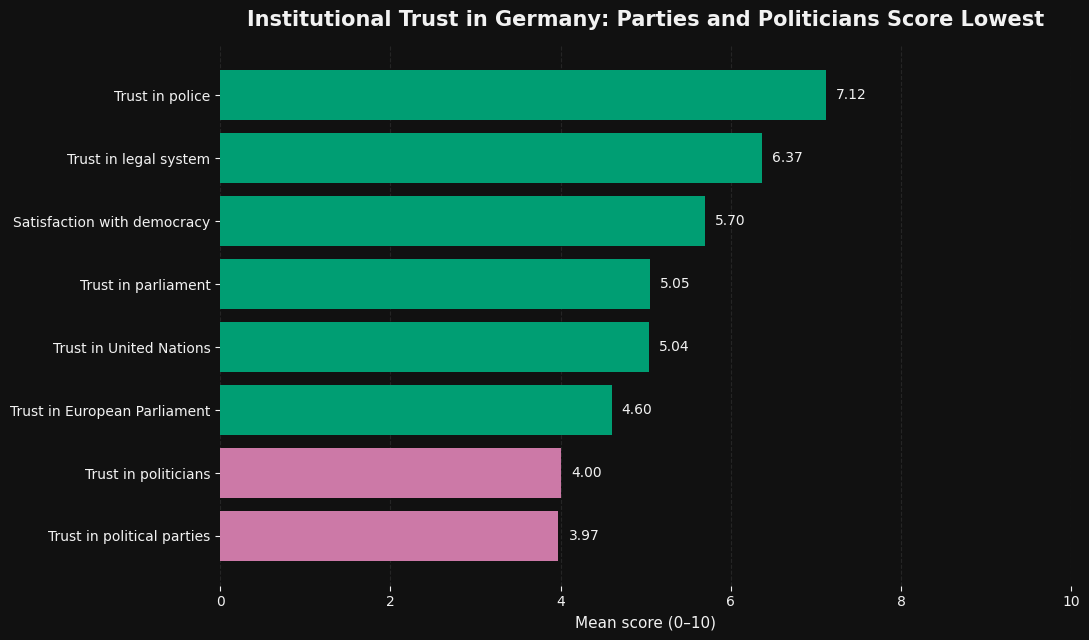

In [56]:
# 51.1 Visualize institutional trust ranking with accessible dark theme

import matplotlib.pyplot as plt
from pathlib import Path

viz_path = Path("../visualizations")
viz_path.mkdir(parents=True, exist_ok=True)

trust_vars = [
    "stfdem",
    "trstprl",
    "trstplt",
    "trstprt",
    "trstlgl",
    "trstplc",
    "trstep",
    "trstun"
]

trust_labels = {
    "stfdem": "Satisfaction with democracy",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties",
    "trstlgl": "Trust in legal system",
    "trstplc": "Trust in police",
    "trstep": "Trust in European Parliament",
    "trstun": "Trust in United Nations"
}

trust_summary = (
    df_de[trust_vars]
    .mean()
    .rename("mean")
    .reset_index()
    .rename(columns={"index": "variable"})
)

trust_summary["label"] = trust_summary["variable"].map(trust_labels)
trust_summary = trust_summary.sort_values("mean", ascending=True)

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"
purple = "#CC79A7"
teal = "#009E73"
yellow = "#F0E442"

colors = [
    purple if var in ["trstprt", "trstplt"] else teal
    for var in trust_summary["variable"]
]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

bars = ax.barh(trust_summary["label"], trust_summary["mean"], color=colors)

ax.set_title(
    "Institutional Trust in Germany: Parties and Politicians Score Lowest",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 10)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar, value in zip(bars, trust_summary["mean"]):
    ax.text(
        value + 0.12,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        color=text_col,
        fontsize=10
    )

plt.tight_layout()
plt.savefig(viz_path / "01_institutional_trust_ranking_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### 51.2 Political efficacy gap

This visualization compares democratic satisfaction and institutional trust across groups with low, medium and high perceived political efficacy.

Political efficacy describes whether respondents feel that people can have a say in politics, influence politics, and participate politically.

The goal is to test visually whether lower perceived political influence is associated with lower democratic satisfaction and lower institutional trust. The analysis is exploratory and does not imply causality.

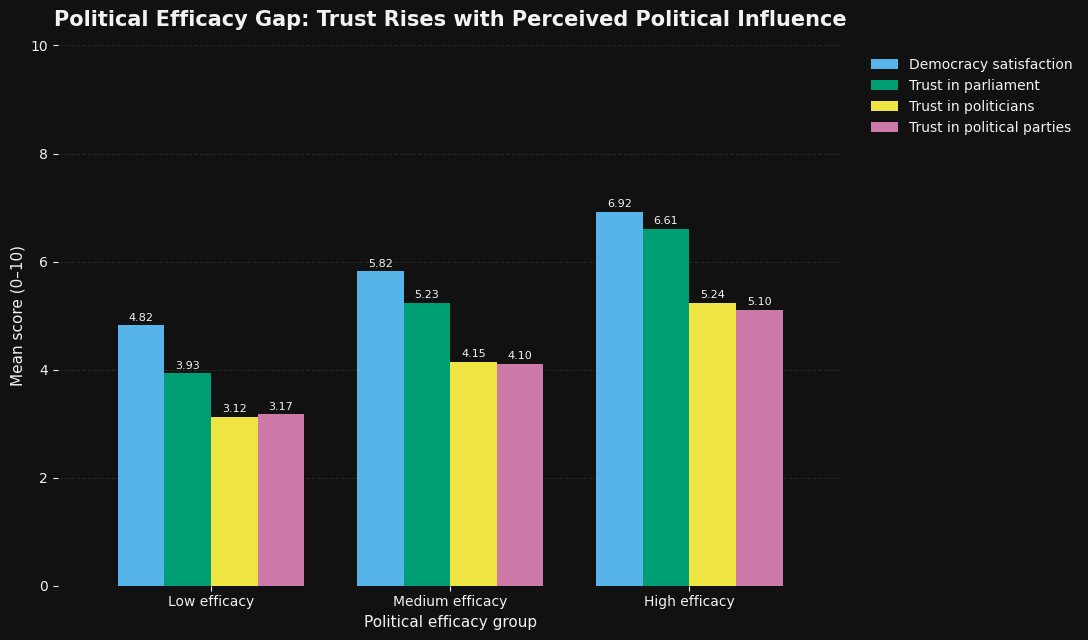

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties
efficacy_group,,,,
Low efficacy,4.82,3.93,3.12,3.17
Medium efficacy,5.82,5.23,4.15,4.10
High efficacy,6.92,6.61,5.24,5.10


In [57]:
# 51.2 Visualize democratic trust by political efficacy group with accessible dark theme

efficacy_plot = (
    df_de.groupby("efficacy_group", observed=False)[
        ["stfdem", "trstprl", "trstplt", "trstprt"]
    ]
    .mean()
    .round(2)
)

efficacy_plot = efficacy_plot.rename(columns={
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties"
})

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

palette = ["#56B4E9", "#009E73", "#F0E442", "#CC79A7"]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

efficacy_plot.plot(
    kind="bar",
    ax=ax,
    color=palette,
    width=0.78
)

ax.set_title(
    "Political Efficacy Gap: Trust Rises with Perceived Political Influence",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Political efficacy group", color=text_col, fontsize=11)
ax.set_ylabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylim(0, 10)

ax.tick_params(axis="x", colors=text_col, rotation=0)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

for text in legend.get_texts():
    text.set_color(text_col)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", color=text_col, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(viz_path / "02_political_efficacy_gap_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

efficacy_plot

### 51.3 Social trust gap

This visualization compares democratic satisfaction and institutional trust across respondents with low, medium and high social trust.

The social trust index is based on three ESS variables: whether people can be trusted, whether people are fair, and whether people are helpful.

The goal is to explore whether democratic trust is linked to broader social confidence. This is conceptually important because democratic trust may not only depend on institutions, but also on how people perceive society and other citizens.

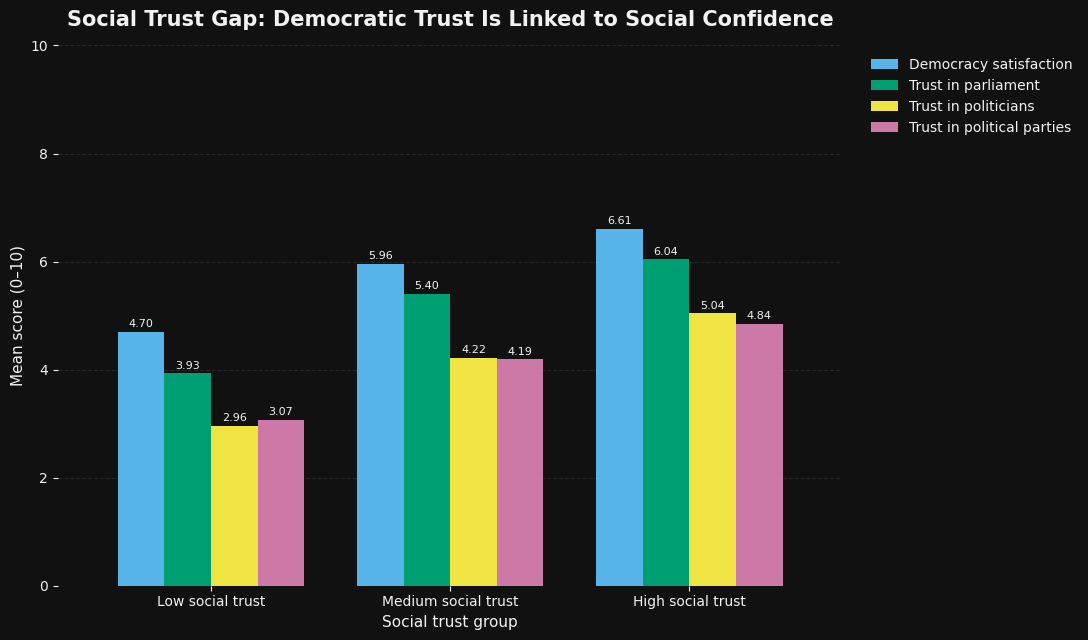

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties
social_trust_group,,,,
Low social trust,4.70,3.93,2.96,3.07
Medium social trust,5.96,5.40,4.22,4.19
High social trust,6.61,6.04,5.04,4.84


In [58]:
# 51.3 Visualize democratic trust by social trust group with accessible dark theme

social_plot = (
    df_de.groupby("social_trust_group", observed=False)[
        ["stfdem", "trstprl", "trstplt", "trstprt"]
    ]
    .mean()
    .round(2)
)

social_plot = social_plot.rename(columns={
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties"
})

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

palette = ["#56B4E9", "#009E73", "#F0E442", "#CC79A7"]

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

social_plot.plot(
    kind="bar",
    ax=ax,
    color=palette,
    width=0.78
)

ax.set_title(
    "Social Trust Gap: Democratic Trust Is Linked to Social Confidence",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Social trust group", color=text_col, fontsize=11)
ax.set_ylabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylim(0, 10)

ax.tick_params(axis="x", colors=text_col, rotation=0)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

for text in legend.get_texts():
    text.set_color(text_col)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", color=text_col, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(viz_path / "03_social_trust_gap_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

social_plot

-> Preliminary interpretation: Democratic trust appears to be linked not only to institutions, but also to broader social confidence.

### 51.4 Participation gap

This visualization compares democratic satisfaction and institutional trust between respondents who voted and respondents who did not vote in the last national election.

The goal is to explore whether non-voting is associated with weaker democratic connection. This is strategically relevant because non-voters should not only be understood as missing votes, but potentially as a group with lower institutional trust and weaker political connection.

The analysis is exploratory and does not imply causality.

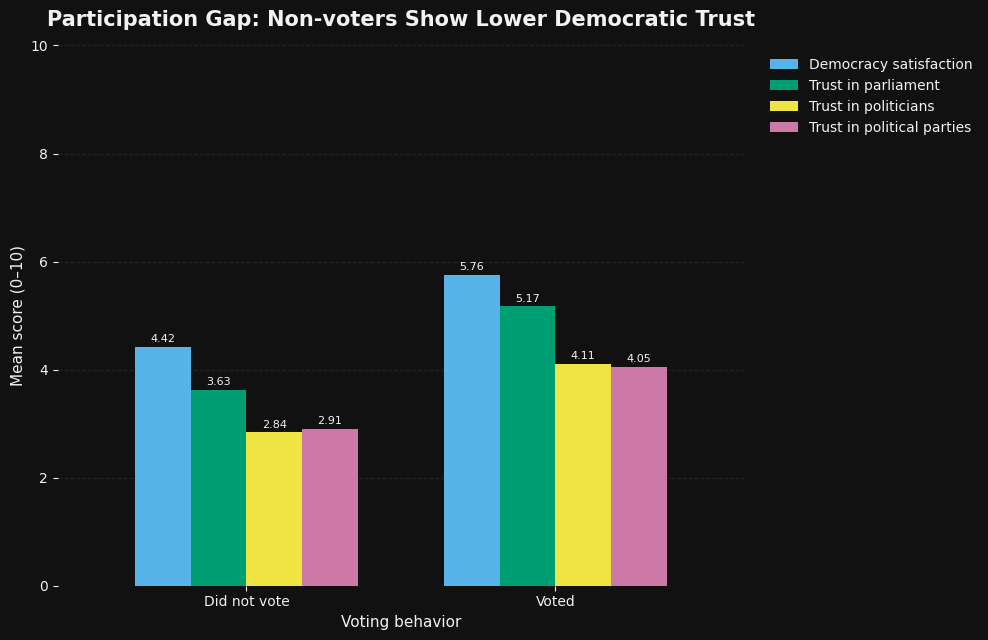

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties
vote_clean,,,,
Did not vote,4.42,3.63,2.84,2.91
Voted,5.76,5.17,4.11,4.05


In [59]:
# 51.4 Visualize democratic trust by voting behavior with accessible dark theme

vote_plot = (
    df_core.groupby("vote_clean")[
        ["stfdem", "trstprl", "trstplt", "trstprt"]
    ]
    .mean()
    .round(2)
)

vote_plot = vote_plot.rename(columns={
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties"
})

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

palette = ["#56B4E9", "#009E73", "#F0E442", "#CC79A7"]

fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

vote_plot.plot(
    kind="bar",
    ax=ax,
    color=palette,
    width=0.72
)

ax.set_title(
    "Participation Gap: Non-voters Show Lower Democratic Trust",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Voting behavior", color=text_col, fontsize=11)
ax.set_ylabel("Mean score (0–10)", color=text_col, fontsize=11)
ax.set_ylim(0, 10)

ax.tick_params(axis="x", colors=text_col, rotation=0)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

for text in legend.get_texts():
    text.set_color(text_col)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", color=text_col, fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(viz_path / "04_participation_gap_dark.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

vote_plot

-> Preliminary interpretation: Non-voters are not only missing votes. In this dataset, they also show lower democratic satisfaction and lower institutional trust.

I have completed the first EDA layer. The ESS11 Germany subset includes 2,420 respondents and 691 variables. After cleaning and selecting the relevant variables, the extended analysis dataset contains 2,004 respondents.

The early visualizations show four promising patterns: trust is lowest toward political parties and politicians; democratic satisfaction and institutional trust rise strongly with perceived political efficacy; social trust is clearly associated with higher democratic trust; and non-voters show lower democratic satisfaction and institutional trust.

At this stage, these are exploratory associations, not causal claims. The next step is statistical validation through group comparison tests, effect sizes and regression models.

## 52. Statistical validation setup

This section moves from exploratory data analysis to statistical validation.

The previous EDA identified visible trust gaps in the ESS11 Germany data. The next steps test whether these observed differences are statistically meaningful and practically relevant.

The analysis focuses on:

- participation gap
- political efficacy gap
- social trust gap
- economic security gap
- political orientation pattern

The goal is not to prove causality, but to assess whether the observed associations are strong enough to support careful interpretation.

This section prepares the statistical tools needed for group comparisons, effect sizes and later regression models.

In [60]:
# 52. Statistical validation setup

import numpy as np
import pandas as pd
from scipy import stats

# Define main outcome variables for repeated statistical checks
main_outcomes = ["stfdem", "trstprl", "trstplt", "trstprt"]

outcome_labels = {
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties"
}

def cohens_d(group1, group2):
    """
    Calculate Cohen's d for two independent groups.
    Positive values mean that group1 has a higher mean than group2.
    """
    group1 = pd.Series(group1).dropna()
    group2 = pd.Series(group2).dropna()
    
    n1 = len(group1)
    n2 = len(group2)
    
    s1 = group1.std(ddof=1)
    s2 = group2.std(ddof=1)
    
    pooled_sd = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
    )
    
    return (group1.mean() - group2.mean()) / pooled_sd


def interpret_cohens_d(d):
    """
    Interpret Cohen's d using common rule-of-thumb thresholds.
    """
    abs_d = abs(d)
    
    if abs_d < 0.2:
        return "very small"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"


def epsilon_squared_kruskal(h_stat, n_total, k_groups):
    """
    Calculate epsilon-squared as an approximate effect size for Kruskal-Wallis tests.
    """
    return (h_stat - k_groups + 1) / (n_total - k_groups)


def interpret_epsilon_squared(eps):
    """
    Rough interpretation of epsilon-squared effect sizes.
    """
    if eps < 0.01:
        return "very small"
    elif eps < 0.06:
        return "small"
    elif eps < 0.14:
        return "medium"
    else:
        return "large"


print("Statistical validation setup completed.")
print("Main outcomes:", main_outcomes)

Statistical validation setup completed.
Main outcomes: ['stfdem', 'trstprl', 'trstplt', 'trstprt']


## 53. Participation Gap validation

This step validates the participation gap identified during the exploratory data analysis.

The comparison focuses on respondents who voted and respondents who did not vote in the last national election.

The tested outcome variables are:

- satisfaction with democracy
- trust in parliament
- trust in politicians
- trust in political parties

Because the two groups have different sample sizes, Welch’s t-test is used. Welch’s t-test does not assume equal variances between groups.

Cohen’s d is calculated as an effect size to assess the practical relevance of the observed differences.

The results are interpreted as associations, not causal effects.

In [61]:
# 53. Participation Gap validation: Welch's t-test and Cohen's d

participation_results = []

for var in main_outcomes:
    voted = df_core.loc[df_core["vote_clean"] == "Voted", var].dropna()
    did_not_vote = df_core.loc[df_core["vote_clean"] == "Did not vote", var].dropna()
    
    t_stat, p_value = stats.ttest_ind(
        voted,
        did_not_vote,
        equal_var=False,
        nan_policy="omit"
    )
    
    d = cohens_d(voted, did_not_vote)
    
    participation_results.append({
        "outcome": outcome_labels[var],
        "variable": var,
        "n_voted": len(voted),
        "mean_voted": voted.mean(),
        "n_did_not_vote": len(did_not_vote),
        "mean_did_not_vote": did_not_vote.mean(),
        "mean_difference": voted.mean() - did_not_vote.mean(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "cohens_d": d,
        "effect_size_interpretation": interpret_cohens_d(d)
    })

participation_results_df = pd.DataFrame(participation_results)

participation_results_df = participation_results_df.round({
    "mean_voted": 2,
    "mean_did_not_vote": 2,
    "mean_difference": 2,
    "t_statistic": 2,
    "p_value": 5,
    "cohens_d": 2
})

participation_results_df

,outcome,variable,n_voted,mean_voted,n_did_not_vote,mean_did_not_vote,mean_difference,t_statistic,p_value,cohens_d,effect_size_interpretation
0,Democracy satisfaction,stfdem,1832,5.76,227,4.42,1.34,7.19,0.0,0.54,medium
1,Trust in parliament,trstprl,1832,5.17,227,3.63,1.54,8.37,0.0,0.59,medium
2,Trust in politicians,trstplt,1832,4.11,227,2.84,1.27,7.84,0.0,0.55,medium
3,Trust in political parties,trstprt,1832,4.05,227,2.91,1.14,7.22,0.0,0.54,medium


### 53.1 Interpretation of the Participation Gap validation

This table summarizes whether the observed differences between voters and non-voters are statistically meaningful and practically relevant.

A statistically significant p-value indicates that the observed difference is unlikely to be due to random sampling variation alone.

Cohen’s d helps assess the size of the difference:

- around 0.2 = small effect
- around 0.5 = medium effect
- around 0.8 = large effect

For this project, the effect size is especially important because the goal is not only to detect statistically significant differences, but to identify trust gaps that are meaningful for strategic interpretation.

In [62]:
# 53.1 Sort participation results by effect size

participation_results_df.sort_values(
    by="cohens_d",
    key=lambda x: x.abs(),
    ascending=False
)

,outcome,variable,n_voted,mean_voted,n_did_not_vote,mean_did_not_vote,mean_difference,t_statistic,p_value,cohens_d,effect_size_interpretation
1,Trust in parliament,trstprl,1832,5.17,227,3.63,1.54,8.37,0.0,0.59,medium
2,Trust in politicians,trstplt,1832,4.11,227,2.84,1.27,7.84,0.0,0.55,medium
0,Democracy satisfaction,stfdem,1832,5.76,227,4.42,1.34,7.19,0.0,0.54,medium
3,Trust in political parties,trstprt,1832,4.05,227,2.91,1.14,7.22,0.0,0.54,medium


### 53.2 Export Participation Gap validation results

This step exports the participation gap validation table.

The exported results can later be used for documentation, dashboard preparation or final presentation tables.

In [63]:
# 53.2 Export Participation Gap validation results

output_path = Path("../data/processed/participation_gap_validation.csv")

participation_results_df.to_csv(output_path, index=False)

print(f"Participation gap validation results exported to: {output_path}")

Participation gap validation results exported to: ../data/processed/participation_gap_validation.csv


### 53.3 Interpretation of Participation Gap validation

The statistical validation confirms a clear participation gap in the ESS11 Germany data.

Respondents who reported that they voted in the last national election show higher average democratic satisfaction and higher trust in parliament, politicians and political parties than respondents who did not vote.

All four Welch’s t-tests indicate statistically meaningful differences between voters and non-voters. The effect sizes are consistently in the medium range, with Cohen’s d values between approximately 0.54 and 0.59.

The strongest difference appears in trust in parliament, followed by trust in politicians, democratic satisfaction and trust in political parties.

This suggests that non-voting is associated with a broader pattern of weaker democratic connection. Non-voters should therefore not only be understood as missing electoral support, but also as a group with lower institutional trust and lower democratic satisfaction.

The result supports the Participation Gap hypothesis. However, the analysis shows association, not causality.

## 54. Political Efficacy Gap validation

This step validates the Political Efficacy Gap identified during the exploratory data analysis.

Political efficacy describes whether respondents feel that people can have a say in politics, influence politics, and participate politically.

The comparison focuses on three groups:

- low political efficacy
- medium political efficacy
- high political efficacy

The tested outcome variables are:

- satisfaction with democracy
- trust in parliament
- trust in politicians
- trust in political parties

Because the analysis compares more than two groups and the variables are based on survey scales, the Kruskal-Wallis test is used. This non-parametric test assesses whether at least one group differs from the others.

Epsilon-squared is calculated as an approximate effect size.

The results are interpreted as associations, not causal effects.

In [64]:
# 54. Political Efficacy Gap validation: Kruskal-Wallis test and epsilon-squared

efficacy_validation_results = []

for var in main_outcomes:
    grouped_data = [
        group[var].dropna()
        for name, group in df_de.groupby("efficacy_group", observed=False)
    ]
    
    group_names = [
        str(name)
        for name, group in df_de.groupby("efficacy_group", observed=False)
    ]
    
    h_stat, p_value = stats.kruskal(*grouped_data)
    
    n_total = sum(len(g) for g in grouped_data)
    k_groups = len(grouped_data)
    eps_sq = epsilon_squared_kruskal(h_stat, n_total, k_groups)
    
    group_means = (
        df_de.groupby("efficacy_group", observed=False)[var]
        .mean()
        .round(2)
        .to_dict()
    )
    
    group_medians = (
        df_de.groupby("efficacy_group", observed=False)[var]
        .median()
        .round(2)
        .to_dict()
    )
    
    efficacy_validation_results.append({
        "outcome": outcome_labels[var],
        "variable": var,
        "groups": ", ".join(group_names),
        "n_total": n_total,
        "mean_low_efficacy": group_means.get("Low efficacy"),
        "mean_medium_efficacy": group_means.get("Medium efficacy"),
        "mean_high_efficacy": group_means.get("High efficacy"),
        "median_low_efficacy": group_medians.get("Low efficacy"),
        "median_medium_efficacy": group_medians.get("Medium efficacy"),
        "median_high_efficacy": group_medians.get("High efficacy"),
        "kruskal_h": h_stat,
        "p_value": p_value,
        "epsilon_squared": eps_sq,
        "effect_size_interpretation": interpret_epsilon_squared(eps_sq)
    })

efficacy_validation_df = pd.DataFrame(efficacy_validation_results)

efficacy_validation_df = efficacy_validation_df.round({
    "kruskal_h": 2,
    "p_value": 5,
    "epsilon_squared": 3
})

efficacy_validation_df

,outcome,variable,groups,n_total,mean_low_efficacy,mean_medium_efficacy,mean_high_efficacy,median_low_efficacy,median_medium_efficacy,median_high_efficacy,kruskal_h,p_value,epsilon_squared,effect_size_interpretation
0,Democracy satisfaction,stfdem,"Low efficacy, Medium efficacy, High efficacy",2398,4.82,5.82,6.92,5.0,6.0,7.0,298.94,0.0,0.124,medium
1,Trust in parliament,trstprl,"Low efficacy, Medium efficacy, High efficacy",2400,3.93,5.23,6.61,4.0,5.0,7.0,444.88,0.0,0.185,large
2,Trust in politicians,trstplt,"Low efficacy, Medium efficacy, High efficacy",2401,3.12,4.15,5.24,3.0,4.0,5.0,351.01,0.0,0.146,large
3,Trust in political parties,trstprt,"Low efficacy, Medium efficacy, High efficacy",2391,3.17,4.10,5.10,3.0,4.0,5.0,332.32,0.0,0.138,medium


### 54.1 Sort Political Efficacy Gap results by effect size

This step sorts the Political Efficacy Gap validation results by effect size.

This helps identify which democratic trust outcomes differ most strongly across political efficacy groups.^

In [65]:
# 54.1 Sort Political Efficacy Gap validation results by effect size

efficacy_validation_df.sort_values(
    by="epsilon_squared",
    ascending=False
)

,outcome,variable,groups,n_total,mean_low_efficacy,mean_medium_efficacy,mean_high_efficacy,median_low_efficacy,median_medium_efficacy,median_high_efficacy,kruskal_h,p_value,epsilon_squared,effect_size_interpretation
1,Trust in parliament,trstprl,"Low efficacy, Medium efficacy, High efficacy",2400,3.93,5.23,6.61,4.0,5.0,7.0,444.88,0.0,0.185,large
2,Trust in politicians,trstplt,"Low efficacy, Medium efficacy, High efficacy",2401,3.12,4.15,5.24,3.0,4.0,5.0,351.01,0.0,0.146,large
3,Trust in political parties,trstprt,"Low efficacy, Medium efficacy, High efficacy",2391,3.17,4.10,5.10,3.0,4.0,5.0,332.32,0.0,0.138,medium
0,Democracy satisfaction,stfdem,"Low efficacy, Medium efficacy, High efficacy",2398,4.82,5.82,6.92,5.0,6.0,7.0,298.94,0.0,0.124,medium


### 54.2 Export Political Efficacy Gap validation results

This step exports the Political Efficacy Gap validation table.

The exported results can later be used for documentation, dashboard preparation or final presentation tables.

In [66]:
# 54.2 Export Political Efficacy Gap validation results

output_path = Path("../data/processed/political_efficacy_gap_validation.csv")

efficacy_validation_df.to_csv(output_path, index=False)

print(f"Political Efficacy Gap validation results exported to: {output_path}")

Political Efficacy Gap validation results exported to: ../data/processed/political_efficacy_gap_validation.csv


### 54.3 Interpretation of Political Efficacy Gap validation

The statistical validation confirms a strong Political Efficacy Gap in the ESS11 Germany data.

Respondents with higher perceived political efficacy report substantially higher democratic satisfaction and higher trust in parliament, politicians and political parties.

The pattern is clearly graded across all outcomes: low efficacy respondents show the lowest trust scores, medium efficacy respondents show intermediate trust scores, and high efficacy respondents show the highest trust scores.

The Kruskal-Wallis tests indicate statistically meaningful differences across efficacy groups for all four outcomes.

The strongest effect appears for trust in parliament, followed by trust in politicians. These outcomes show large effect sizes according to the applied epsilon-squared interpretation. Democratic satisfaction and trust in political parties also show meaningful medium-sized effects.

This makes political efficacy one of the strongest analytical signals in the project so far.

Substantively, the result suggests that democratic connection is closely associated with whether people feel that politics gives them a voice, influence and the ability to participate.

The finding supports the Political Efficacy Gap hypothesis. However, the analysis shows association, not causality.

## 55. Social Trust Gap validation

This step validates the Social Trust Gap identified during the exploratory data analysis.

Social trust is measured through a constructed index based on three ESS variables:

- whether most people can be trusted
- whether most people try to be fair
- whether most people are helpful

The comparison focuses on three groups:

- low social trust
- medium social trust
- high social trust

The tested outcome variables are:

- satisfaction with democracy
- trust in parliament
- trust in politicians
- trust in political parties

Because the analysis compares more than two groups and the variables are based on survey scales, the Kruskal-Wallis test is used.

Epsilon-squared is calculated as an approximate effect size.

The results are interpreted as associations, not causal effects.

In [67]:
# 55. Social Trust Gap validation: Kruskal-Wallis test and epsilon-squared

social_trust_validation_results = []

for var in main_outcomes:
    grouped_data = [
        group[var].dropna()
        for name, group in df_de.groupby("social_trust_group", observed=False)
    ]
    
    group_names = [
        str(name)
        for name, group in df_de.groupby("social_trust_group", observed=False)
    ]
    
    h_stat, p_value = stats.kruskal(*grouped_data)
    
    n_total = sum(len(g) for g in grouped_data)
    k_groups = len(grouped_data)
    eps_sq = epsilon_squared_kruskal(h_stat, n_total, k_groups)
    
    group_means = (
        df_de.groupby("social_trust_group", observed=False)[var]
        .mean()
        .round(2)
        .to_dict()
    )
    
    group_medians = (
        df_de.groupby("social_trust_group", observed=False)[var]
        .median()
        .round(2)
        .to_dict()
    )
    
    social_trust_validation_results.append({
        "outcome": outcome_labels[var],
        "variable": var,
        "groups": ", ".join(group_names),
        "n_total": n_total,
        "mean_low_social_trust": group_means.get("Low social trust"),
        "mean_medium_social_trust": group_means.get("Medium social trust"),
        "mean_high_social_trust": group_means.get("High social trust"),
        "median_low_social_trust": group_medians.get("Low social trust"),
        "median_medium_social_trust": group_medians.get("Medium social trust"),
        "median_high_social_trust": group_medians.get("High social trust"),
        "kruskal_h": h_stat,
        "p_value": p_value,
        "epsilon_squared": eps_sq,
        "effect_size_interpretation": interpret_epsilon_squared(eps_sq)
    })

social_trust_validation_df = pd.DataFrame(social_trust_validation_results)

social_trust_validation_df = social_trust_validation_df.round({
    "kruskal_h": 2,
    "p_value": 5,
    "epsilon_squared": 3
})

social_trust_validation_df

,outcome,variable,groups,n_total,mean_low_social_trust,mean_medium_social_trust,mean_high_social_trust,median_low_social_trust,median_medium_social_trust,median_high_social_trust,kruskal_h,p_value,epsilon_squared,effect_size_interpretation
0,Democracy satisfaction,stfdem,"Low social trust, Medium social trust, High so...",2399,4.70,5.96,6.61,5.0,6.0,7.0,224.76,0.0,0.093,medium
1,Trust in parliament,trstprl,"Low social trust, Medium social trust, High so...",2402,3.93,5.40,6.04,4.0,6.0,6.0,267.99,0.0,0.111,medium
2,Trust in politicians,trstplt,"Low social trust, Medium social trust, High so...",2401,2.96,4.22,5.04,3.0,4.0,5.0,318.95,0.0,0.132,medium
3,Trust in political parties,trstprt,"Low social trust, Medium social trust, High so...",2391,3.07,4.19,4.84,3.0,4.0,5.0,277.28,0.0,0.115,medium


### 55.1 Sort Social Trust Gap results by effect size

This step sorts the Social Trust Gap validation results by effect size.

This helps identify which democratic trust outcomes differ most strongly across social trust groups.

In [68]:
# 55.1 Sort Social Trust Gap validation results by effect size

social_trust_validation_df.sort_values(
    by="epsilon_squared",
    ascending=False
)

,outcome,variable,groups,n_total,mean_low_social_trust,mean_medium_social_trust,mean_high_social_trust,median_low_social_trust,median_medium_social_trust,median_high_social_trust,kruskal_h,p_value,epsilon_squared,effect_size_interpretation
2,Trust in politicians,trstplt,"Low social trust, Medium social trust, High so...",2401,2.96,4.22,5.04,3.0,4.0,5.0,318.95,0.0,0.132,medium
3,Trust in political parties,trstprt,"Low social trust, Medium social trust, High so...",2391,3.07,4.19,4.84,3.0,4.0,5.0,277.28,0.0,0.115,medium
1,Trust in parliament,trstprl,"Low social trust, Medium social trust, High so...",2402,3.93,5.40,6.04,4.0,6.0,6.0,267.99,0.0,0.111,medium
0,Democracy satisfaction,stfdem,"Low social trust, Medium social trust, High so...",2399,4.70,5.96,6.61,5.0,6.0,7.0,224.76,0.0,0.093,medium


### 55.2 Export Social Trust Gap validation results

This step exports the Social Trust Gap validation table.

The exported results can later be used for documentation, dashboard preparation or final presentation tables.

In [69]:
# 55.2 Export Social Trust Gap validation results

output_path = Path("../data/processed/social_trust_gap_validation.csv")

social_trust_validation_df.to_csv(output_path, index=False)

print(f"Social Trust Gap validation results exported to: {output_path}")

Social Trust Gap validation results exported to: ../data/processed/social_trust_gap_validation.csv


### 55.3 Interpretation of Social Trust Gap validation

The statistical validation confirms a clear Social Trust Gap in the ESS11 Germany data.

Respondents with higher social trust report higher democratic satisfaction and higher trust in parliament, politicians and political parties.

The pattern is graded across all outcomes: low social trust respondents show the lowest democratic and institutional trust scores, medium social trust respondents show intermediate scores, and high social trust respondents show the highest scores.

The Kruskal-Wallis tests indicate statistically meaningful differences across social trust groups for all four outcomes.

The effect sizes are consistently in the medium range. The strongest difference appears for trust in politicians, followed by trust in political parties, trust in parliament and democratic satisfaction.

Substantively, this suggests that democratic connection may not only be linked to how people evaluate institutions, but also to broader social confidence: whether people see others as trustworthy, fair and helpful.

The finding supports the Social Trust Gap hypothesis. However, the analysis shows association, not causality.

## 56. Economic Security Gap validation

This step validates the Economic Security Gap identified during the exploratory data analysis.

Economic security is measured through the ESS variable `hincfel`, which captures how respondents feel about their household income nowadays.

The original categories are:

- living comfortably on present income
- coping on present income
- difficult on present income
- very difficult on present income

The analysis first compares all original income-feeling groups using the Kruskal-Wallis test.

Because the group reporting that living on present income is very difficult is relatively small, a second binary comparison is created:

- economically secure or coping
- economically strained

This makes the interpretation more robust and easier to communicate.

The tested outcome variables are:

- satisfaction with democracy
- trust in parliament
- trust in politicians
- trust in political parties

The results are interpreted as associations, not causal effects.

In [70]:
# 56. Economic Security Gap validation using original hincfel groups

income_validation_results = []

hincfel_labels = {
    1.0: "Living comfortably",
    2.0: "Coping",
    3.0: "Difficult",
    4.0: "Very difficult"
}

df_de["hincfel_label"] = df_de["hincfel"].map(hincfel_labels)

for var in main_outcomes:
    grouped_data = [
        group[var].dropna()
        for name, group in df_de.groupby("hincfel_label", observed=False)
    ]
    
    group_names = [
        str(name)
        for name, group in df_de.groupby("hincfel_label", observed=False)
    ]
    
    h_stat, p_value = stats.kruskal(*grouped_data)
    
    n_total = sum(len(g) for g in grouped_data)
    k_groups = len(grouped_data)
    eps_sq = epsilon_squared_kruskal(h_stat, n_total, k_groups)
    
    group_means = (
        df_de.groupby("hincfel_label", observed=False)[var]
        .mean()
        .round(2)
        .to_dict()
    )
    
    group_counts = (
        df_de.groupby("hincfel_label", observed=False)[var]
        .count()
        .to_dict()
    )
    
    income_validation_results.append({
        "outcome": outcome_labels[var],
        "variable": var,
        "groups": ", ".join(group_names),
        "n_total": n_total,
        "n_living_comfortably": group_counts.get("Living comfortably"),
        "n_coping": group_counts.get("Coping"),
        "n_difficult": group_counts.get("Difficult"),
        "n_very_difficult": group_counts.get("Very difficult"),
        "mean_living_comfortably": group_means.get("Living comfortably"),
        "mean_coping": group_means.get("Coping"),
        "mean_difficult": group_means.get("Difficult"),
        "mean_very_difficult": group_means.get("Very difficult"),
        "kruskal_h": h_stat,
        "p_value": p_value,
        "epsilon_squared": eps_sq,
        "effect_size_interpretation": interpret_epsilon_squared(eps_sq)
    })

income_validation_df = pd.DataFrame(income_validation_results)

income_validation_df = income_validation_df.round({
    "kruskal_h": 2,
    "p_value": 5,
    "epsilon_squared": 3
})

income_validation_df

,outcome,variable,groups,n_total,n_living_comfortably,n_coping,n_difficult,n_very_difficult,mean_living_comfortably,mean_coping,mean_difficult,mean_very_difficult,kruskal_h,p_value,epsilon_squared,effect_size_interpretation
0,Democracy satisfaction,stfdem,"Coping, Difficult, Living comfortably, Very di...",2392,1192,1023,139,38,6.17,5.33,4.77,4.26,85.84,0.0,0.035,small
1,Trust in parliament,trstprl,"Coping, Difficult, Living comfortably, Very di...",2395,1187,1026,142,40,5.50,4.69,4.24,3.42,80.37,0.0,0.032,small
2,Trust in politicians,trstplt,"Coping, Difficult, Living comfortably, Very di...",2394,1189,1026,139,40,4.37,3.73,3.06,3.02,72.28,0.0,0.029,small
3,Trust in political parties,trstprt,"Coping, Difficult, Living comfortably, Very di...",2384,1181,1025,139,39,4.25,3.77,3.32,3.05,48.85,0.0,0.019,small


### 56.1 Binary Economic Security Gap validation

This step creates a binary economic security variable.

Respondents are grouped into:

- economically secure or coping: living comfortably or coping on present income
- economically strained: difficult or very difficult on present income

This binary comparison is useful because the original “very difficult” category has a small sample size.

Welch’s t-test is used for the two-group comparison, and Cohen’s d is calculated as an effect size.

In [71]:
# 56.1 Binary Economic Security Gap validation: Welch's t-test and Cohen's d

df_de["economic_security_group"] = df_de["hincfel"].map({
    1.0: "Secure or coping",
    2.0: "Secure or coping",
    3.0: "Economically strained",
    4.0: "Economically strained"
})

economic_binary_results = []

for var in main_outcomes:
    secure = df_de.loc[df_de["economic_security_group"] == "Secure or coping", var].dropna()
    strained = df_de.loc[df_de["economic_security_group"] == "Economically strained", var].dropna()
    
    t_stat, p_value = stats.ttest_ind(
        secure,
        strained,
        equal_var=False,
        nan_policy="omit"
    )
    
    d = cohens_d(secure, strained)
    
    economic_binary_results.append({
        "outcome": outcome_labels[var],
        "variable": var,
        "n_secure_or_coping": len(secure),
        "mean_secure_or_coping": secure.mean(),
        "n_economically_strained": len(strained),
        "mean_economically_strained": strained.mean(),
        "mean_difference": secure.mean() - strained.mean(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "cohens_d": d,
        "effect_size_interpretation": interpret_cohens_d(d)
    })

economic_binary_df = pd.DataFrame(economic_binary_results)

economic_binary_df = economic_binary_df.round({
    "mean_secure_or_coping": 2,
    "mean_economically_strained": 2,
    "mean_difference": 2,
    "t_statistic": 2,
    "p_value": 5,
    "cohens_d": 2
})

economic_binary_df

,outcome,variable,n_secure_or_coping,mean_secure_or_coping,n_economically_strained,mean_economically_strained,mean_difference,t_statistic,p_value,cohens_d,effect_size_interpretation
0,Democracy satisfaction,stfdem,2215,5.78,177,4.66,1.12,4.74,0.00000,0.44,small
1,Trust in parliament,trstprl,2213,5.13,182,4.06,1.06,4.79,0.00000,0.40,small
2,Trust in politicians,trstplt,2215,4.08,179,3.05,1.03,5.46,0.00000,0.44,small
3,Trust in political parties,trstprt,2206,4.03,178,3.26,0.77,4.16,0.00005,0.35,small


### 56.2 Export Economic Security Gap validation results

This step exports both Economic Security Gap validation tables.

The exported results can later be used for documentation, dashboard preparation or final presentation tables.

In [72]:
# 56.2 Export Economic Security Gap validation results

income_output_path = Path("../data/processed/economic_security_gap_original_groups_validation.csv")
binary_income_output_path = Path("../data/processed/economic_security_gap_binary_validation.csv")

income_validation_df.to_csv(income_output_path, index=False)
economic_binary_df.to_csv(binary_income_output_path, index=False)

print(f"Original income group validation results exported to: {income_output_path}")
print(f"Binary economic security validation results exported to: {binary_income_output_path}")

Original income group validation results exported to: ../data/processed/economic_security_gap_original_groups_validation.csv
Binary economic security validation results exported to: ../data/processed/economic_security_gap_binary_validation.csv


### 56.3 Interpretation of Economic Security Gap validation

The statistical validation confirms an Economic Security Gap in the ESS11 Germany data.

Respondents who feel more economically secure report higher democratic satisfaction and higher trust in parliament, politicians and political parties than respondents who feel economically strained.

The original four-category comparison shows a consistent gradient: respondents living comfortably on their present income show the highest trust scores, while respondents who find it difficult or very difficult to live on their present income show lower trust scores.

The binary comparison between respondents who are economically secure or coping and respondents who are economically strained confirms the same pattern.

However, the effect sizes are smaller than for political efficacy, social trust and voting participation. This suggests that subjective economic security is relevant, but may not be the strongest explanatory dimension in the current analysis.

Substantively, the result suggests that economic security should be treated as part of democratic trust-building, but not as the only factor shaping democratic connection.

The finding supports the Economic Security Gap hypothesis. However, the analysis shows association, not causality.

## 57. Political Orientation Pattern validation

This step validates whether democratic satisfaction and institutional trust differ across political self-placement groups.

The ESS variable `lrscale` measures respondents’ self-placement on a left-right scale from 0 to 10.

For more stable interpretation, the scale was grouped into:

- Left (0–3)
- Center (4–6)
- Right (7–10)

The tested outcome variables are:

- satisfaction with democracy
- trust in parliament
- trust in politicians
- trust in political parties

Because the analysis compares more than two groups and the variables are based on survey scales, the Kruskal-Wallis test is used.

The results should be interpreted carefully and without stigmatizing political groups. Political self-placement is treated as an analytical variable, not as a normative judgement.

The results are interpreted as associations, not causal effects.

In [73]:
# 57. Political Orientation Pattern validation: Kruskal-Wallis test and epsilon-squared

lr_validation_results = []

for var in main_outcomes:
    grouped_data = [
        group[var].dropna()
        for name, group in df_de.groupby("lr_group", observed=False)
    ]
    
    group_names = [
        str(name)
        for name, group in df_de.groupby("lr_group", observed=False)
    ]
    
    h_stat, p_value = stats.kruskal(*grouped_data)
    
    n_total = sum(len(g) for g in grouped_data)
    k_groups = len(grouped_data)
    eps_sq = epsilon_squared_kruskal(h_stat, n_total, k_groups)
    
    group_means = (
        df_de.groupby("lr_group", observed=False)[var]
        .mean()
        .round(2)
        .to_dict()
    )
    
    group_medians = (
        df_de.groupby("lr_group", observed=False)[var]
        .median()
        .round(2)
        .to_dict()
    )
    
    group_counts = (
        df_de.groupby("lr_group", observed=False)[var]
        .count()
        .to_dict()
    )
    
    lr_validation_results.append({
        "outcome": outcome_labels[var],
        "variable": var,
        "groups": ", ".join(group_names),
        "n_total": n_total,
        "n_left": group_counts.get("Left (0-3)"),
        "n_center": group_counts.get("Center (4-6)"),
        "n_right": group_counts.get("Right (7-10)"),
        "mean_left": group_means.get("Left (0-3)"),
        "mean_center": group_means.get("Center (4-6)"),
        "mean_right": group_means.get("Right (7-10)"),
        "median_left": group_medians.get("Left (0-3)"),
        "median_center": group_medians.get("Center (4-6)"),
        "median_right": group_medians.get("Right (7-10)"),
        "kruskal_h": h_stat,
        "p_value": p_value,
        "epsilon_squared": eps_sq,
        "effect_size_interpretation": interpret_epsilon_squared(eps_sq)
    })

lr_validation_df = pd.DataFrame(lr_validation_results)

lr_validation_df = lr_validation_df.round({
    "kruskal_h": 2,
    "p_value": 5,
    "epsilon_squared": 3
})

lr_validation_df

,outcome,variable,groups,n_total,n_left,n_center,n_right,mean_left,mean_center,mean_right,median_left,median_center,median_right,kruskal_h,p_value,epsilon_squared,effect_size_interpretation
0,Democracy satisfaction,stfdem,"Left (0-3), Center (4-6), Right (7-10)",2307,601,1436,270,6.28,5.64,4.77,7.0,6.0,5.0,62.92,0.0,0.026,small
1,Trust in parliament,trstprl,"Left (0-3), Center (4-6), Right (7-10)",2307,601,1436,270,5.75,5.01,3.96,6.0,5.0,4.0,87.62,0.0,0.037,small
2,Trust in politicians,trstplt,"Left (0-3), Center (4-6), Right (7-10)",2308,601,1436,271,4.60,3.96,3.16,5.0,4.0,3.0,73.21,0.0,0.031,small
3,Trust in political parties,trstprt,"Left (0-3), Center (4-6), Right (7-10)",2300,598,1432,270,4.42,3.96,3.31,5.0,4.0,3.0,51.19,0.0,0.021,small


### 57.1 Sort Political Orientation Pattern results by effect size

This step sorts the Political Orientation Pattern validation results by effect size.

This helps identify which democratic trust outcomes differ most strongly across left-right self-placement groups.

In [74]:
# 57.1 Sort Political Orientation Pattern validation results by effect size

lr_validation_df.sort_values(
    by="epsilon_squared",
    ascending=False
)

,outcome,variable,groups,n_total,n_left,n_center,n_right,mean_left,mean_center,mean_right,median_left,median_center,median_right,kruskal_h,p_value,epsilon_squared,effect_size_interpretation
1,Trust in parliament,trstprl,"Left (0-3), Center (4-6), Right (7-10)",2307,601,1436,270,5.75,5.01,3.96,6.0,5.0,4.0,87.62,0.0,0.037,small
2,Trust in politicians,trstplt,"Left (0-3), Center (4-6), Right (7-10)",2308,601,1436,271,4.60,3.96,3.16,5.0,4.0,3.0,73.21,0.0,0.031,small
0,Democracy satisfaction,stfdem,"Left (0-3), Center (4-6), Right (7-10)",2307,601,1436,270,6.28,5.64,4.77,7.0,6.0,5.0,62.92,0.0,0.026,small
3,Trust in political parties,trstprt,"Left (0-3), Center (4-6), Right (7-10)",2300,598,1432,270,4.42,3.96,3.31,5.0,4.0,3.0,51.19,0.0,0.021,small


### 57.2 Export Political Orientation Pattern validation results

This step exports the Political Orientation Pattern validation table.

The exported results can later be used for documentation, dashboard preparation or final presentation tables.

In [75]:
# 57.2 Export Political Orientation Pattern validation results

output_path = Path("../data/processed/political_orientation_pattern_validation.csv")

lr_validation_df.to_csv(output_path, index=False)

print(f"Political Orientation Pattern validation results exported to: {output_path}")

Political Orientation Pattern validation results exported to: ../data/processed/political_orientation_pattern_validation.csv


### 57.3 Interpretation of Political Orientation Pattern validation

The statistical validation confirms that democratic satisfaction and institutional trust differ across left-right self-placement groups in the ESS11 Germany data.

Respondents who place themselves on the left show the highest average democratic satisfaction and institutional trust scores. Respondents in the center show intermediate scores, while respondents who place themselves on the right show lower scores.

The Kruskal-Wallis tests indicate statistically meaningful differences across political orientation groups for all four outcomes.

However, the effect sizes are consistently small. This means that political self-placement is associated with democratic trust, but it is not among the strongest explanatory dimensions in the current analysis.

The strongest difference appears for trust in parliament, followed by trust in politicians, democratic satisfaction and trust in political parties.

Substantively, this suggests that political orientation matters, but democratic connection should not be reduced to ideology alone. Political efficacy, social trust and participation currently appear to be stronger analytical signals.

The finding supports the Political Orientation Pattern hypothesis. However, the analysis shows association, not causality and should be interpreted carefully without stigmatizing political groups.

## 58. Overall Trust Gap Strength Ranking

This step summarizes the statistical validation results across the main trust gap hypotheses.

The goal is to compare which observed trust gaps appear strongest in the ESS11 Germany data.

The ranking combines the strongest available effect size for each tested gap:

- Participation Gap: strongest Cohen’s d across voter vs. non-voter comparisons
- Political Efficacy Gap: strongest epsilon-squared across efficacy group comparisons
- Social Trust Gap: strongest epsilon-squared across social trust group comparisons
- Economic Security Gap: strongest Cohen’s d from the binary economic security comparison
- Political Orientation Pattern: strongest epsilon-squared across left-right group comparisons

Because Cohen’s d and epsilon-squared are different effect size metrics, the ranking should be interpreted as a structured comparison, not as a mathematically perfect single scale.

The purpose is to identify which hypotheses appear most promising for the next analytical phase.

In [76]:
# 58. Overall Trust Gap Strength Ranking

gap_strength_results = []

# Participation Gap: strongest Cohen's d
participation_best = participation_results_df.loc[
    participation_results_df["cohens_d"].abs().idxmax()
]

gap_strength_results.append({
    "trust_gap": "Participation Gap",
    "strongest_outcome": participation_best["outcome"],
    "effect_size_metric": "Cohen's d",
    "effect_size_value": participation_best["cohens_d"],
    "effect_size_interpretation": participation_best["effect_size_interpretation"],
    "main_pattern": "Voters show higher democratic satisfaction and institutional trust than non-voters."
})

# Political Efficacy Gap: strongest epsilon-squared
efficacy_best = efficacy_validation_df.loc[
    efficacy_validation_df["epsilon_squared"].idxmax()
]

gap_strength_results.append({
    "trust_gap": "Political Efficacy Gap",
    "strongest_outcome": efficacy_best["outcome"],
    "effect_size_metric": "epsilon-squared",
    "effect_size_value": efficacy_best["epsilon_squared"],
    "effect_size_interpretation": efficacy_best["effect_size_interpretation"],
    "main_pattern": "Higher perceived political efficacy is associated with higher democratic satisfaction and institutional trust."
})

# Social Trust Gap: strongest epsilon-squared
social_best = social_trust_validation_df.loc[
    social_trust_validation_df["epsilon_squared"].idxmax()
]

gap_strength_results.append({
    "trust_gap": "Social Trust Gap",
    "strongest_outcome": social_best["outcome"],
    "effect_size_metric": "epsilon-squared",
    "effect_size_value": social_best["epsilon_squared"],
    "effect_size_interpretation": social_best["effect_size_interpretation"],
    "main_pattern": "Higher social trust is associated with higher democratic satisfaction and institutional trust."
})

# Economic Security Gap: strongest Cohen's d from binary comparison
economic_best = economic_binary_df.loc[
    economic_binary_df["cohens_d"].abs().idxmax()
]

gap_strength_results.append({
    "trust_gap": "Economic Security Gap",
    "strongest_outcome": economic_best["outcome"],
    "effect_size_metric": "Cohen's d",
    "effect_size_value": economic_best["cohens_d"],
    "effect_size_interpretation": economic_best["effect_size_interpretation"],
    "main_pattern": "Respondents who are economically secure or coping show higher trust than economically strained respondents."
})

# Political Orientation Pattern: strongest epsilon-squared
lr_best = lr_validation_df.loc[
    lr_validation_df["epsilon_squared"].idxmax()
]

gap_strength_results.append({
    "trust_gap": "Political Orientation Pattern",
    "strongest_outcome": lr_best["outcome"],
    "effect_size_metric": "epsilon-squared",
    "effect_size_value": lr_best["epsilon_squared"],
    "effect_size_interpretation": lr_best["effect_size_interpretation"],
    "main_pattern": "Democratic satisfaction and trust differ across left-right self-placement groups, but effects are small."
})

gap_strength_df = pd.DataFrame(gap_strength_results)

gap_strength_df = gap_strength_df.round({
    "effect_size_value": 3
})

gap_strength_df

,trust_gap,strongest_outcome,effect_size_metric,effect_size_value,effect_size_interpretation,main_pattern
0,Participation Gap,Trust in parliament,Cohen's d,0.590,medium,Voters show higher democratic satisfaction and...
1,Political Efficacy Gap,Trust in parliament,epsilon-squared,0.185,large,Higher perceived political efficacy is associa...
2,Social Trust Gap,Trust in politicians,epsilon-squared,0.132,medium,Higher social trust is associated with higher ...
3,Economic Security Gap,Democracy satisfaction,Cohen's d,0.440,small,Respondents who are economically secure or cop...
4,Political Orientation Pattern,Trust in parliament,epsilon-squared,0.037,small,Democratic satisfaction and trust differ acros...


### 58.1 Sort Trust Gaps by effect size strength

This step sorts the trust gap summary by effect size value.

The ranking is mainly useful within comparable effect size types and should be interpreted carefully because different tests use different effect size metrics.

The table helps identify which analytical gaps should be prioritized in the next phase of the project.

In [77]:
# 58.1 Sort Trust Gap Strength Ranking

gap_strength_df.sort_values(
    by="effect_size_value",
    ascending=False
)

,trust_gap,strongest_outcome,effect_size_metric,effect_size_value,effect_size_interpretation,main_pattern
0,Participation Gap,Trust in parliament,Cohen's d,0.590,medium,Voters show higher democratic satisfaction and...
3,Economic Security Gap,Democracy satisfaction,Cohen's d,0.440,small,Respondents who are economically secure or cop...
1,Political Efficacy Gap,Trust in parliament,epsilon-squared,0.185,large,Higher perceived political efficacy is associa...
2,Social Trust Gap,Trust in politicians,epsilon-squared,0.132,medium,Higher social trust is associated with higher ...
4,Political Orientation Pattern,Trust in parliament,epsilon-squared,0.037,small,Democratic satisfaction and trust differ acros...


### 58.1.(b) Methodological note on effect size comparison

The trust gap summary table combines different effect size metrics.

Participation Gap and Economic Security Gap use Cohen’s d because they are based on two-group comparisons.

Political Efficacy Gap, Social Trust Gap and Political Orientation Pattern use epsilon-squared because they are based on Kruskal-Wallis tests with three or more groups.

These effect size values are not directly comparable on a single numerical scale.

Therefore, the table should not be interpreted as a mathematically exact ranking across all gaps. Instead, it provides a structured overview of the strongest observed effect within each analytical gap.

Substantively, Political Efficacy currently appears to be the strongest analytical signal because it shows large effect sizes within its appropriate test framework and a clear graded pattern across all trust outcomes.

Social Trust and Participation also show meaningful patterns. Economic Security is relevant but weaker, while Political Orientation shows statistically significant but comparatively small effects.

### 58.2 Export Trust Gap Strength Ranking

This step exports the summarized trust gap ranking.

The exported table can be used for dashboard preparation, project documentation and final presentation slides.

In [78]:
# 58.2 Export Trust Gap Strength Ranking

output_path = Path("../data/processed/trust_gap_strength_ranking.csv")

gap_strength_df.to_csv(output_path, index=False)

print(f"Trust gap strength ranking exported to: {output_path}")

Trust gap strength ranking exported to: ../data/processed/trust_gap_strength_ranking.csv


### 58.3 Interim interpretation of validated trust gaps

The validation results suggest a clear hierarchy of analytical relevance.

Political efficacy is currently the strongest validated signal in the project. Respondents who feel more politically influential show substantially higher democratic satisfaction and higher institutional trust.

Social trust is also a strong and conceptually important signal. Respondents with higher social trust report higher trust in democratic institutions and political actors.

Voting participation shows a meaningful gap as well. Non-voters report lower democratic satisfaction and lower institutional trust than voters.

Economic security is relevant, but the effect sizes are smaller. This suggests that subjective economic strain matters for democratic trust, but does not fully explain democratic disconnection on its own.

Political orientation is associated with trust differences, but the effect sizes are small. This suggests that democratic connection should not be reduced to left-right ideology alone.

Overall, the strongest project storyline is not simply that people are dissatisfied with democracy. The stronger analytical finding is that democratic connection appears weaker where people feel politically powerless, socially distrustful, less politically engaged or economically strained.

These results remain associational and will be further tested through regression models and, if feasible, exploratory trust profile clustering.

### 58.5 Analytical priority table

This step creates an interpretative priority table for storytelling and dashboard development.

The table does not rank gaps only by numerical effect size. Instead, it combines statistical evidence, interpretability and strategic relevance for democratic actors.

This helps identify which findings should become central in the final storyline.

In [79]:
# 58.5 Create analytical priority table for storytelling

priority_table = pd.DataFrame([
    {
        "priority": 1,
        "trust_gap": "Political Efficacy Gap",
        "analytical_strength": "Very strong",
        "strategic_relevance": "Very high",
        "reason": "Shows large effects for trust in parliament and politicians and a clear graded pattern across all outcomes.",
        "recommended_role_in_story": "Core finding"
    },
    {
        "priority": 2,
        "trust_gap": "Social Trust Gap",
        "analytical_strength": "Strong",
        "strategic_relevance": "High",
        "reason": "Shows medium effects across all outcomes and connects institutional trust with broader social confidence.",
        "recommended_role_in_story": "Core finding"
    },
    {
        "priority": 3,
        "trust_gap": "Participation Gap",
        "analytical_strength": "Strong",
        "strategic_relevance": "Very high",
        "reason": "Shows medium effects between voters and non-voters and is directly relevant for democratic re-engagement.",
        "recommended_role_in_story": "Core finding / political action point"
    },
    {
        "priority": 4,
        "trust_gap": "Economic Security Gap",
        "analytical_strength": "Moderate",
        "strategic_relevance": "High",
        "reason": "Shows consistent but smaller effects; important as a contextual factor for democratic trust.",
        "recommended_role_in_story": "Supporting factor"
    },
    {
        "priority": 5,
        "trust_gap": "Political Orientation Pattern",
        "analytical_strength": "Weak to moderate",
        "strategic_relevance": "Medium",
        "reason": "Shows statistically significant but small effects; should be interpreted carefully and not overemphasized.",
        "recommended_role_in_story": "Contextual pattern"
    }
])

priority_table

,priority,trust_gap,analytical_strength,strategic_relevance,reason,recommended_role_in_story
0,1,Political Efficacy Gap,Very strong,Very high,Shows large effects for trust in parliament an...,Core finding
1,2,Social Trust Gap,Strong,High,Shows medium effects across all outcomes and c...,Core finding
2,3,Participation Gap,Strong,Very high,Shows medium effects between voters and non-vo...,Core finding / political action point
3,4,Economic Security Gap,Moderate,High,Shows consistent but smaller effects; importan...,Supporting factor
4,5,Political Orientation Pattern,Weak to moderate,Medium,Shows statistically significant but small effe...,Contextual pattern


In [80]:
# 58.6 Export analytical priority table

output_path = Path("../data/processed/analytical_priority_table.csv")

priority_table.to_csv(output_path, index=False)

print(f"Analytical priority table exported to: {output_path}")

Analytical priority table exported to: ../data/processed/analytical_priority_table.csv


## 59. Correlation matrix for final analytical variables

This step examines correlations between the main democratic trust outcomes and the most relevant explanatory variables.

The goal is to identify which variables are most strongly associated with:

- satisfaction with democracy
- trust in parliament
- trust in politicians
- trust in political parties

The correlation matrix includes:

- political efficacy index
- social trust index
- household income feeling
- left-right self-placement
- education
- age

This step helps prepare the regression models by showing which variables may be important predictors.

The correlations are interpreted as associations, not causal effects.

In [88]:
# 59. Correlation matrix for final analytical variables

correlation_vars = [
    "stfdem",
    "trstprl",
    "trstplt",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "eduyrs",
    "agea"
]

correlation_labels = {
    "stfdem": "Democracy satisfaction",
    "trstprl": "Trust in parliament",
    "trstplt": "Trust in politicians",
    "trstprt": "Trust in political parties",
    "political_efficacy_index": "Political efficacy index",
    "social_trust_index": "Social trust index",
    "hincfel": "Income feeling",
    "lrscale": "Left-right placement",
    "eduyrs": "Years of education",
    "agea": "Age"
}

correlation_matrix = df_de[correlation_vars].corr().round(2)

correlation_matrix_labeled = correlation_matrix.rename(
    index=correlation_labels,
    columns=correlation_labels
)

correlation_matrix_labeled

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties,Political efficacy index,Social trust index,Income feeling,Left-right placement,Years of education,Age
Democracy satisfaction,1.00,0.65,0.63,0.60,0.38,0.34,-0.19,-0.16,0.15,-0.08
Trust in parliament,0.65,1.00,0.77,0.72,0.48,0.37,-0.18,-0.20,0.22,-0.12
Trust in politicians,0.63,0.77,1.00,0.84,0.42,0.40,-0.17,-0.18,0.15,-0.07
Trust in political parties,0.60,0.72,0.84,1.00,0.42,0.38,-0.14,-0.14,0.15,-0.15
Political efficacy index,0.38,0.48,0.42,0.42,1.00,0.28,-0.26,-0.14,0.40,-0.14
Social trust index,0.34,0.37,0.40,0.38,0.28,1.00,-0.20,-0.12,0.22,0.04
Income feeling,-0.19,-0.18,-0.17,-0.14,-0.26,-0.20,1.00,0.03,-0.23,-0.04
Left-right placement,-0.16,-0.20,-0.18,-0.14,-0.14,-0.12,0.03,1.00,-0.10,0.05
Years of education,0.15,0.22,0.15,0.15,0.40,0.22,-0.23,-0.10,1.00,-0.09
Age,-0.08,-0.12,-0.07,-0.15,-0.14,0.04,-0.04,0.05,-0.09,1.00


### 59.1 Correlations with main democratic trust outcomes

This step extracts the correlations between explanatory variables and the four main democratic trust outcomes.

This makes it easier to identify which variables are most relevant for the next regression models.

In [89]:
# 59.1 Extract correlations with key democratic trust outcomes

key_outcomes = ["stfdem", "trstprl", "trstplt", "trstprt"]

explanatory_correlation_vars = [
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "eduyrs",
    "agea"
]

outcome_correlation_summary = (
    df_de[explanatory_correlation_vars + key_outcomes]
    .corr()
    .loc[explanatory_correlation_vars, key_outcomes]
    .round(2)
)

outcome_correlation_summary = outcome_correlation_summary.rename(
    index=correlation_labels,
    columns=correlation_labels
)

outcome_correlation_summary

,Democracy satisfaction,Trust in parliament,Trust in politicians,Trust in political parties
Political efficacy index,0.38,0.48,0.42,0.42
Social trust index,0.34,0.37,0.40,0.38
Income feeling,-0.19,-0.18,-0.17,-0.14
Left-right placement,-0.16,-0.20,-0.18,-0.14
Years of education,0.15,0.22,0.15,0.15
Age,-0.08,-0.12,-0.07,-0.15


### 59.2 Rank explanatory variables by association with party trust

This step ranks explanatory variables by their absolute correlation with trust in political parties.

Trust in political parties is especially important for the project because the early EDA identified a clear party-trust gap.

This ranking helps identify which variables should be prioritized in the regression model for party trust.

In [90]:
# 59.2 Rank explanatory variables by association with trust in political parties

party_trust_correlations = (
    df_de[explanatory_correlation_vars + ["trstprt"]]
    .corr()["trstprt"]
    .drop("trstprt")
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .round(3)
    .reset_index()
)

party_trust_correlations.columns = [
    "explanatory_variable",
    "correlation_with_party_trust"
]

party_trust_correlations["label"] = party_trust_correlations["explanatory_variable"].map(correlation_labels)

party_trust_correlations = party_trust_correlations[
    ["label", "explanatory_variable", "correlation_with_party_trust"]
]

party_trust_correlations

,label,explanatory_variable,correlation_with_party_trust
0,Political efficacy index,political_efficacy_index,0.420
1,Social trust index,social_trust_index,0.375
2,Age,agea,-0.152
3,Years of education,eduyrs,0.151
4,Left-right placement,lrscale,-0.142
5,Income feeling,hincfel,-0.140


### 59.3 Rank explanatory variables by association with democratic satisfaction

This step ranks explanatory variables by their absolute correlation with satisfaction with democracy.

Satisfaction with democracy is used as a broader outcome variable, while trust in political parties captures the more specific party-trust dimension.

Comparing both rankings helps assess whether the same variables are associated with general democratic satisfaction and party trust.

In [91]:
# 59.3 Rank explanatory variables by association with democratic satisfaction

democracy_satisfaction_correlations = (
    df_de[explanatory_correlation_vars + ["stfdem"]]
    .corr()["stfdem"]
    .drop("stfdem")
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .round(3)
    .reset_index()
)

democracy_satisfaction_correlations.columns = [
    "explanatory_variable",
    "correlation_with_democracy_satisfaction"
]

democracy_satisfaction_correlations["label"] = democracy_satisfaction_correlations["explanatory_variable"].map(correlation_labels)

democracy_satisfaction_correlations = democracy_satisfaction_correlations[
    ["label", "explanatory_variable", "correlation_with_democracy_satisfaction"]
]

democracy_satisfaction_correlations

,label,explanatory_variable,correlation_with_democracy_satisfaction
0,Political efficacy index,political_efficacy_index,0.383
1,Social trust index,social_trust_index,0.341
2,Income feeling,hincfel,-0.195
3,Left-right placement,lrscale,-0.163
4,Years of education,eduyrs,0.153
5,Age,agea,-0.076


### 59.4 Visualize correlations with party trust and democratic satisfaction

This step visualizes the correlations between explanatory variables and two key outcomes:

- trust in political parties
- satisfaction with democracy

The chart helps compare whether the same variables are associated with both general democratic satisfaction and the more specific party-trust dimension.

The visualization is exploratory and does not imply causality.

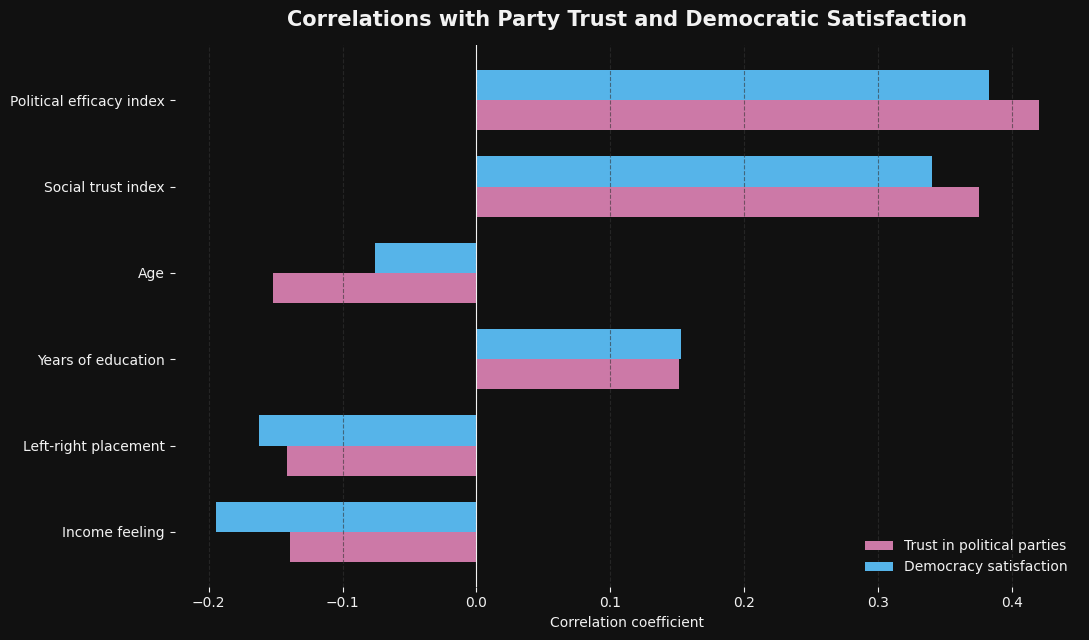

,variable,label,party_trust,democracy_satisfaction
2,hincfel,Income feeling,-0.140,-0.195
3,lrscale,Left-right placement,-0.142,-0.163
4,eduyrs,Years of education,0.151,0.153
5,agea,Age,-0.152,-0.076
1,social_trust_index,Social trust index,0.375,0.341
0,political_efficacy_index,Political efficacy index,0.420,0.383


In [92]:
# 59.4 Visualize correlations with party trust and democratic satisfaction

corr_plot_df = pd.DataFrame({
    "variable": explanatory_correlation_vars,
    "label": [correlation_labels[var] for var in explanatory_correlation_vars],
    "party_trust": [
        df_de[[var, "trstprt"]].corr().iloc[0, 1]
        for var in explanatory_correlation_vars
    ],
    "democracy_satisfaction": [
        df_de[[var, "stfdem"]].corr().iloc[0, 1]
        for var in explanatory_correlation_vars
    ]
})

corr_plot_df = corr_plot_df.sort_values(
    by="party_trust",
    key=lambda x: x.abs(),
    ascending=True
)

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

y = np.arange(len(corr_plot_df))
height = 0.35

ax.barh(
    y - height / 2,
    corr_plot_df["party_trust"],
    height,
    label="Trust in political parties",
    color="#CC79A7"
)

ax.barh(
    y + height / 2,
    corr_plot_df["democracy_satisfaction"],
    height,
    label="Democracy satisfaction",
    color="#56B4E9"
)

ax.set_yticks(y)
ax.set_yticklabels(corr_plot_df["label"], color=text_col)

ax.set_xlabel("Correlation coefficient", color=text_col)
ax.set_title(
    "Correlations with Party Trust and Democratic Satisfaction",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.axvline(0, color=text_col, linewidth=0.8)
ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(frameon=False, loc="lower right")

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "05_correlations_party_trust_democracy_satisfaction_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

corr_plot_df.round(3)

### 59.5 Export correlation outputs

This step exports the correlation outputs for documentation, dashboard preparation and final presentation.

The exported files summarize:

- full correlation matrix
- correlations with key democratic trust outcomes
- ranked correlations with party trust
- ranked correlations with democratic satisfaction

In [93]:
# 59.5 Export correlation outputs

correlation_matrix_labeled.to_csv("../data/processed/final_variable_correlation_matrix.csv")
outcome_correlation_summary.to_csv("../data/processed/outcome_correlation_summary.csv", index=True)
party_trust_correlations.to_csv("../data/processed/party_trust_correlation_ranking.csv", index=False)
democracy_satisfaction_correlations.to_csv("../data/processed/democracy_satisfaction_correlation_ranking.csv", index=False)

print("Correlation outputs exported to ../data/processed/")

Correlation outputs exported to ../data/processed/


### 59.6 Interpretation of final correlation analysis

The correlation analysis confirms the emerging analytical direction of the project.

Political efficacy and social trust show the strongest associations with the main democratic trust outcomes.

Political efficacy has the strongest correlation with trust in parliament, trust in politicians, trust in political parties and democratic satisfaction. Social trust is the second strongest explanatory dimension across most outcomes.

Subjective income feeling, left-right placement, education and age are also associated with democratic trust, but the correlations are weaker.

This suggests that democratic connection should not be reduced to demographic factors, economic insecurity or ideology alone. The strongest signals in the current analysis are linked to whether people feel politically influential and whether they have broader social trust.

The trust variables themselves are strongly correlated with each other, especially trust in politicians and trust in political parties. Therefore, the next regression models should treat democratic satisfaction and party trust as separate outcome variables rather than using institutional trust variables as predictors of each other.

The correlation results support the decision to use political efficacy, social trust, income feeling, left-right placement, education, age, gender and voting behavior as predictors in the next regression models.

The results remain associational and do not imply causality.

## 60. Regression setup

This step prepares the data for regression models.

The previous EDA, group comparisons and correlation analysis identified political efficacy and social trust as two of the strongest analytical signals.

Regression models are used to assess whether these associations remain visible when controlling for other variables.

Two outcome variables are modeled:

- `stfdem`: satisfaction with democracy
- `trstprt`: trust in political parties

The predictor variables are:

- political efficacy index
- social trust index
- subjective income feeling
- left-right political self-placement
- years of education
- age
- gender
- voting behavior

Voting behavior is recoded into a binary variable:

- 1 = voted
- 0 = did not vote

The models are interpreted as associational models, not causal models.

In [94]:
# 60. Regression setup

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Create regression dataset
regression_vars = [
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "eduyrs",
    "agea",
    "gndr",
    "vote_clean"
]

df_reg = df_de[regression_vars].dropna().copy()

# Recode voting behavior into binary variable
df_reg["vote_binary"] = df_reg["vote_clean"].map({
    "Did not vote": 0,
    "Voted": 1
})

# Check final regression dataset
print("Regression dataset shape:", df_reg.shape)
df_reg.head()

Regression dataset shape: (2064, 11)


,stfdem,trstprt,political_efficacy_index,social_trust_index,hincfel,lrscale,eduyrs,agea,gndr,vote_clean,vote_binary
8256,8.0,5.0,2.75,3.333333,1.0,5.0,17.0,34.0,1.0,Voted,1
8257,7.0,3.0,2.75,7.333333,2.0,3.0,17.0,42.0,2.0,Voted,1
8259,8.0,7.0,2.00,6.666667,1.0,5.0,13.0,58.0,2.0,Voted,1
8260,8.0,7.0,3.25,7.333333,1.0,6.0,17.0,40.0,1.0,Voted,1
8261,9.0,7.0,3.25,4.666667,2.0,3.0,17.0,46.0,1.0,Voted,1


### 60.1 Regression dataset overview

This step checks the regression dataset after selecting variables, removing missing values and recoding voting behavior.

The purpose is to confirm that the sample size remains sufficient for regression analysis.

In [95]:
# 60.1 Regression dataset overview

regression_overview = pd.DataFrame({
    "valid_count": df_reg.notna().sum(),
    "missing_count": df_reg.isna().sum(),
    "unique_values": df_reg.nunique(dropna=True)
})

regression_overview

,valid_count,missing_count,unique_values
stfdem,2064,0,11
trstprt,2064,0,11
political_efficacy_index,2064,0,21
social_trust_index,2064,0,31
hincfel,2064,0,4
lrscale,2064,0,11
eduyrs,2064,0,29
agea,2064,0,75
gndr,2064,0,2
vote_clean,2064,0,2


### 60.2 Standardize numerical predictors

This step creates standardized versions of the main numerical predictor variables.

Standardization transforms variables so that they have a mean of 0 and a standard deviation of 1.

This makes regression coefficients easier to compare across predictors that are measured on different scales.

The original variables are kept in the dataset.

In [96]:
# 60.2 Standardize numerical predictors

standardize_vars = [
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "eduyrs",
    "agea"
]

for var in standardize_vars:
    df_reg[var + "_z"] = (df_reg[var] - df_reg[var].mean()) / df_reg[var].std(ddof=0)

df_reg[[var + "_z" for var in standardize_vars]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
political_efficacy_index_z,2064.0,0.0,1.0,-2.12,-0.72,-0.02,0.68,3.48
social_trust_index_z,2064.0,0.0,1.0,-3.50,-0.60,0.03,0.65,2.72
hincfel_z,2064.0,0.0,1.0,-0.87,-0.87,-0.87,0.67,3.74
lrscale_z,2064.0,0.0,1.0,-2.57,-0.87,0.26,0.26,3.08
eduyrs_z,2064.0,0.0,1.0,-4.44,-0.83,-0.23,0.67,5.48
agea_z,2064.0,0.0,1.0,-2.10,-0.81,0.08,0.75,2.10


### 60.3 Regression Model 1: Democratic satisfaction

This model uses satisfaction with democracy as the outcome variable.

The model tests whether political efficacy, social trust, income feeling, left-right placement, education, age, gender and voting behavior are associated with democratic satisfaction.

Standardized predictors are used where possible to make coefficient sizes easier to compare.

The model is interpreted as an associational model, not as a causal explanation.

In [97]:
# 60.3 Regression Model 1: Democratic satisfaction

model_stfdem = smf.ols(
    formula="""
    stfdem ~ political_efficacy_index_z
           + social_trust_index_z
           + hincfel_z
           + lrscale_z
           + eduyrs_z
           + agea_z
           + C(gndr)
           + vote_binary
    """,
    data=df_reg
).fit(cov_type="HC3")

print(model_stfdem.summary())

                            OLS Regression Results                            
Dep. Variable:                 stfdem   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     93.05
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          3.90e-132
Time:                        13:10:43   Log-Likelihood:                -4544.5
No. Observations:                2064   AIC:                             9107.
Df Residuals:                    2055   BIC:                             9158.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### 60.4 Regression Model 2: Trust in political parties

This model uses trust in political parties as the outcome variable.

Trust in political parties is central to the project because the EDA identified a specific party-trust gap.

The model tests whether political efficacy, social trust, income feeling, left-right placement, education, age, gender and voting behavior are associated with party trust.

Standardized predictors are used where possible to compare coefficient sizes.

The model is interpreted as an associational model, not as a causal explanation.

In [98]:
# 60.4 Regression Model 2: Trust in political parties

model_party_trust = smf.ols(
    formula="""
    trstprt ~ political_efficacy_index_z
            + social_trust_index_z
            + hincfel_z
            + lrscale_z
            + eduyrs_z
            + agea_z
            + C(gndr)
            + vote_binary
    """,
    data=df_reg
).fit(cov_type="HC3")

print(model_party_trust.summary())

                            OLS Regression Results                            
Dep. Variable:                trstprt   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     101.0
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          4.04e-142
Time:                        13:11:21   Log-Likelihood:                -4167.1
No. Observations:                2064   AIC:                             8352.
Df Residuals:                    2055   BIC:                             8403.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### 60.5 Extract regression coefficients for comparison

This step extracts the regression coefficients, p-values and confidence intervals from both models.

The resulting tables make it easier to compare which variables are most strongly associated with democratic satisfaction and party trust.

In [99]:
# 60.5 Extract regression coefficients for comparison

def extract_model_results(model, model_name):
    results = pd.DataFrame({
        "term": model.params.index,
        "coefficient": model.params.values,
        "p_value": model.pvalues.values,
        "conf_low": model.conf_int()[0].values,
        "conf_high": model.conf_int()[1].values
    })
    
    results["model"] = model_name
    
    return results

stfdem_model_results = extract_model_results(
    model_stfdem,
    "Democracy satisfaction"
)

party_trust_model_results = extract_model_results(
    model_party_trust,
    "Trust in political parties"
)

regression_results_df = pd.concat(
    [stfdem_model_results, party_trust_model_results],
    ignore_index=True
)

regression_results_df = regression_results_df.round({
    "coefficient": 3,
    "p_value": 5,
    "conf_low": 3,
    "conf_high": 3
})

regression_results_df

,term,coefficient,p_value,conf_low,conf_high,model
0,Intercept,5.363,0.00000,5.023,5.703,Democracy satisfaction
1,C(gndr)[T.2.0],-0.087,0.38291,-0.282,0.108,Democracy satisfaction
2,political_efficacy_index_z,0.758,0.00000,0.647,0.870,Democracy satisfaction
3,social_trust_index_z,0.626,0.00000,0.514,0.738,Democracy satisfaction
4,hincfel_z,-0.257,0.00000,-0.363,-0.151,Democracy satisfaction
5,lrscale_z,-0.246,0.00001,-0.357,-0.135,Democracy satisfaction
6,eduyrs_z,-0.051,0.32778,-0.154,0.052,Democracy satisfaction
7,agea_z,0.026,0.60638,-0.072,0.123,Democracy satisfaction
8,vote_binary,0.327,0.06767,-0.024,0.677,Democracy satisfaction
9,Intercept,3.458,0.00000,3.174,3.742,Trust in political parties


### 60.6 Export regression results

This step exports the regression results and model-ready dataset.

The exported files can be used for documentation, dashboard preparation and final presentation tables.

In [100]:
# 60.6 Export regression results

regression_results_df.to_csv("../data/processed/regression_results_democracy_satisfaction_party_trust.csv", index=False)
df_reg.to_csv("../data/clean/ess11_germany_regression_dataset.csv", index=False)

print("Regression results exported to ../data/processed/")
print("Regression dataset exported to ../data/clean/")

Regression results exported to ../data/processed/
Regression dataset exported to ../data/clean/


### 60.7 Interpretation of regression models

The regression models confirm the central analytical direction of the project.

Political efficacy and social trust remain the strongest predictors of both democratic satisfaction and trust in political parties, even when controlling for subjective income feeling, left-right political self-placement, education, age, gender and voting behavior.

For democratic satisfaction, political efficacy shows the strongest positive association, followed by social trust. Subjective income feeling and left-right self-placement also remain statistically significant, but their coefficients are smaller. Education, age, gender and voting behavior are not statistically significant in this model.

For trust in political parties, political efficacy is again the strongest predictor, followed by social trust. Voting behavior also remains statistically significant, indicating that respondents who voted report higher trust in political parties than respondents who did not vote. Age and left-right placement are also statistically significant, while income feeling and education are not significant in this model.

The models explain around one quarter of the variation in the outcomes. This is meaningful for survey-based social and political data.

Substantively, the regression results suggest that democratic connection should not be reduced to economic insecurity, demographics or ideology alone. The strongest signals in the current analysis are linked to whether people feel politically influential and whether they have broader social trust.

This supports the core project logic: different trust problems may require different democratic responses. In particular, rebuilding democratic connection may require strengthening political efficacy and social confidence, not only improving political communication.

The models remain associational and do not prove causality.

## 61. Visualize regression coefficients

This step visualizes the regression coefficients from the two main models:

- satisfaction with democracy
- trust in political parties

The visualization focuses on the predictor variables and excludes the intercept.

The goal is to compare which variables are most strongly associated with democratic satisfaction and party trust after controlling for other factors.

Standardized predictors allow a more direct comparison of coefficient sizes for the main numerical variables.

The results are interpreted as associations, not causal effects.

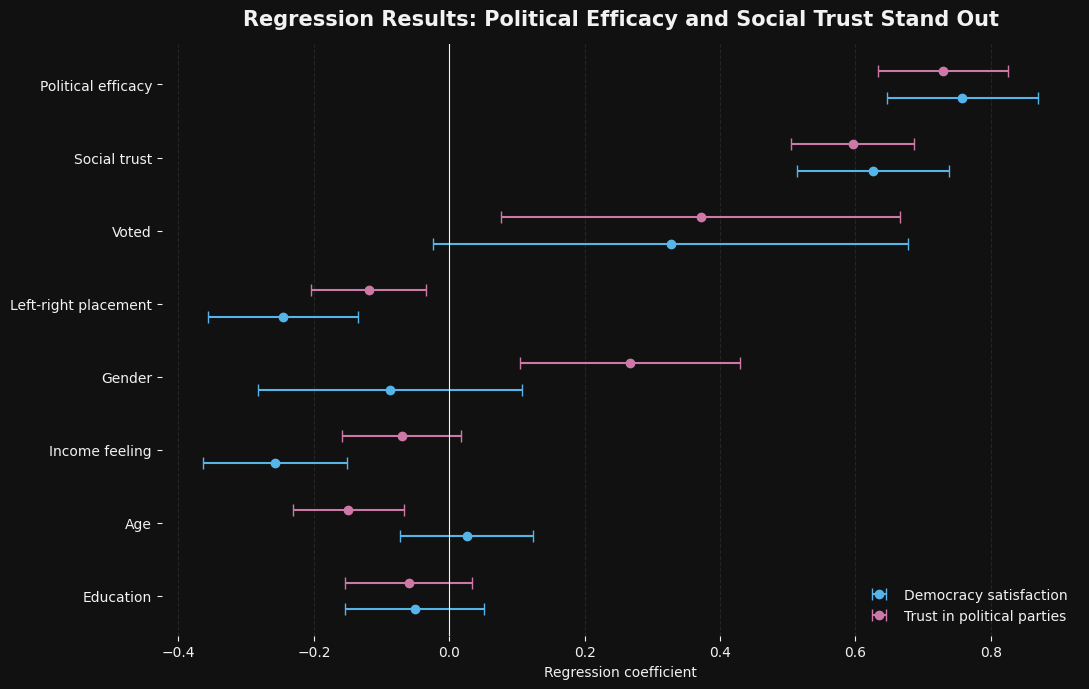

,model,label,coefficient,p_value,conf_low,conf_high
1,Democracy satisfaction,Gender,-0.087,0.38291,-0.282,0.108
2,Democracy satisfaction,Political efficacy,0.758,0.00000,0.647,0.870
3,Democracy satisfaction,Social trust,0.626,0.00000,0.514,0.738
4,Democracy satisfaction,Income feeling,-0.257,0.00000,-0.363,-0.151
5,Democracy satisfaction,Left-right placement,-0.246,0.00001,-0.357,-0.135
6,Democracy satisfaction,Education,-0.051,0.32778,-0.154,0.052
7,Democracy satisfaction,Age,0.026,0.60638,-0.072,0.123
8,Democracy satisfaction,Voted,0.327,0.06767,-0.024,0.677
10,Trust in political parties,Gender,0.267,0.00127,0.105,0.430
11,Trust in political parties,Political efficacy,0.730,0.00000,0.633,0.826


In [101]:
# 61. Visualize regression coefficients

regression_plot_df = regression_results_df.copy()

# Remove intercept
regression_plot_df = regression_plot_df[regression_plot_df["term"] != "Intercept"].copy()

# Create readable labels
term_labels = {
    "C(gndr)[T.2.0]": "Gender",
    "political_efficacy_index_z": "Political efficacy",
    "social_trust_index_z": "Social trust",
    "hincfel_z": "Income feeling",
    "lrscale_z": "Left-right placement",
    "eduyrs_z": "Education",
    "agea_z": "Age",
    "vote_binary": "Voted"
}

regression_plot_df["label"] = regression_plot_df["term"].map(term_labels)

# Keep plot order based on average absolute coefficient
order = (
    regression_plot_df
    .groupby("label")["coefficient"]
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=True)
    .index
)

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

models = regression_plot_df["model"].unique()
colors = {
    "Democracy satisfaction": "#56B4E9",
    "Trust in political parties": "#CC79A7"
}

y_positions = np.arange(len(order))
offset = 0.18

for i, model in enumerate(models):
    data = regression_plot_df[regression_plot_df["model"] == model].set_index("label").loc[order]
    
    y = y_positions + (i - 0.5) * offset * 2
    
    ax.errorbar(
        data["coefficient"],
        y,
        xerr=[
            data["coefficient"] - data["conf_low"],
            data["conf_high"] - data["coefficient"]
        ],
        fmt="o",
        capsize=4,
        label=model,
        color=colors[model]
    )

ax.axvline(0, color=text_col, linewidth=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels(order, color=text_col)

ax.set_xlabel("Regression coefficient", color=text_col)
ax.set_title(
    "Regression Results: Political Efficacy and Social Trust Stand Out",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(frameon=False, loc="lower right")

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "06_regression_coefficients_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

regression_plot_df[["model", "label", "coefficient", "p_value", "conf_low", "conf_high"]]

## 62. Regression model comparison

This step summarizes the two regression models in a compact comparison table.

The table includes:

- outcome variable
- number of observations
- R-squared
- adjusted R-squared
- strongest positive predictor
- interpretation

This helps communicate the model results in a concise format for the final presentation and documentation.

In [102]:
# 62. Regression model comparison

model_comparison = pd.DataFrame([
    {
        "model": "Democracy satisfaction",
        "outcome": "stfdem",
        "n_observations": int(model_stfdem.nobs),
        "r_squared": model_stfdem.rsquared,
        "adj_r_squared": model_stfdem.rsquared_adj,
        "strongest_predictor": "Political efficacy",
        "main_interpretation": "Political efficacy and social trust are the strongest predictors of democratic satisfaction."
    },
    {
        "model": "Trust in political parties",
        "outcome": "trstprt",
        "n_observations": int(model_party_trust.nobs),
        "r_squared": model_party_trust.rsquared,
        "adj_r_squared": model_party_trust.rsquared_adj,
        "strongest_predictor": "Political efficacy",
        "main_interpretation": "Political efficacy and social trust are the strongest predictors of party trust."
    }
])

model_comparison = model_comparison.round({
    "r_squared": 3,
    "adj_r_squared": 3
})

model_comparison

,model,outcome,n_observations,r_squared,adj_r_squared,strongest_predictor,main_interpretation
0,Democracy satisfaction,stfdem,2064,0.254,0.251,Political efficacy,Political efficacy and social trust are the st...
1,Trust in political parties,trstprt,2064,0.281,0.278,Political efficacy,Political efficacy and social trust are the st...


In [103]:
# 62.1 Export regression model comparison

output_path = Path("../data/processed/regression_model_comparison.csv")

model_comparison.to_csv(output_path, index=False)

print(f"Regression model comparison exported to: {output_path}")

Regression model comparison exported to: ../data/processed/regression_model_comparison.csv


## 63. Regression diagnostics and robustness checks

This step checks whether the regression models are sufficiently robust for interpretation.

The previous models showed that political efficacy and social trust are the strongest predictors of democratic satisfaction and trust in political parties.

Before using these models for storytelling and strategic interpretation, this step checks several methodological issues:

- multicollinearity between predictor variables
- residual patterns
- distribution of residuals
- observed versus predicted values
- model fit comparison

The goal is not to build a perfect causal model, but to assess whether the regression results are stable enough to support careful, evidence-informed interpretation.

All models remain associational and do not imply causality.

### 63.1 Check multicollinearity with Variance Inflation Factors

This step checks whether the predictor variables in the regression models are strongly correlated with each other.

Variance Inflation Factor, or VIF, is used to identify possible multicollinearity. High multicollinearity can make regression coefficients unstable and harder to interpret.

As a rough rule of thumb:

- VIF below 5 usually indicates no major multicollinearity problem.
- VIF between 5 and 10 may require attention.
- VIF above 10 is often considered problematic.

The purpose of this step is to check whether the key predictors, especially political efficacy and social trust, can be interpreted separately in the regression models.

In [104]:
# 63.1 Check multicollinearity using Variance Inflation Factor

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = [
    "political_efficacy_index_z",
    "social_trust_index_z",
    "hincfel_z",
    "lrscale_z",
    "eduyrs_z",
    "agea_z",
    "vote_binary"
]

# Add gender as numeric control
df_reg["gender_numeric"] = df_reg["gndr"]

vif_vars_with_gender = vif_vars + ["gender_numeric"]

X_vif = df_reg[vif_vars_with_gender].dropna().copy()

vif_results = pd.DataFrame({
    "variable": X_vif.columns,
    "vif": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_results["vif_interpretation"] = pd.cut(
    vif_results["vif"],
    bins=[0, 2.5, 5, 10, float("inf")],
    labels=[
        "low multicollinearity",
        "moderate multicollinearity",
        "high multicollinearity",
        "very high multicollinearity"
    ]
)

vif_results.round(2)

,variable,vif,vif_interpretation
0,political_efficacy_index_z,1.41,low multicollinearity
1,social_trust_index_z,1.13,low multicollinearity
2,hincfel_z,1.11,low multicollinearity
3,lrscale_z,1.05,low multicollinearity
4,eduyrs_z,1.33,low multicollinearity
5,agea_z,1.10,low multicollinearity
6,vote_binary,5.60,high multicollinearity
7,gender_numeric,5.57,high multicollinearity


### 63.1b Recheck VIF with constant term

This step recalculates Variance Inflation Factors with an explicit constant term.

This is important because VIF calculations can be distorted when the model matrix does not include an intercept. The constant is included for the calculation but excluded from the final interpretation table.

This check helps verify whether the higher VIF values for binary predictors reflect real multicollinearity or a technical artifact of the previous calculation.

In [109]:
# 63.1b Recheck VIF with constant term

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vif_vars = [
    "political_efficacy_index_z",
    "social_trust_index_z",
    "hincfel_z",
    "lrscale_z",
    "eduyrs_z",
    "agea_z",
    "vote_binary"
]

# Create numeric gender variable from the categorical gender variable
df_reg["gender_numeric"] = df_reg["gndr"].astype(float)

vif_vars_with_gender = vif_vars + ["gender_numeric"]

X_vif = df_reg[vif_vars_with_gender].dropna().copy()

# Add constant for correct VIF calculation
X_vif_const = sm.add_constant(X_vif)

vif_results_recheck = pd.DataFrame({
    "variable": X_vif_const.columns,
    "vif": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

# Remove constant from interpretation table
vif_results_recheck = vif_results_recheck[
    vif_results_recheck["variable"] != "const"
].copy()

def interpret_vif(vif):
    if vif < 5:
        return "low multicollinearity"
    elif vif < 10:
        return "moderate multicollinearity"
    else:
        return "high multicollinearity"

vif_results_recheck["vif_interpretation"] = vif_results_recheck["vif"].apply(interpret_vif)

vif_results_recheck = vif_results_recheck.round({
    "vif": 2
})

vif_results_recheck

,variable,vif,vif_interpretation
1,political_efficacy_index_z,1.41,low multicollinearity
2,social_trust_index_z,1.14,low multicollinearity
3,hincfel_z,1.12,low multicollinearity
4,lrscale_z,1.06,low multicollinearity
5,eduyrs_z,1.33,low multicollinearity
6,agea_z,1.10,low multicollinearity
7,vote_binary,1.12,low multicollinearity
8,gender_numeric,1.07,low multicollinearity


### 63.1c Interpretation of multicollinearity diagnostics

The corrected VIF check shows no relevant multicollinearity problem in the regression models.

All predictor variables have VIF values clearly below the common threshold of 5. This means that the predictors are not strongly redundant with each other and that the regression coefficients can be interpreted with reasonable confidence.

This is especially important for the core analytical variables: political efficacy and social trust. Both remain clearly below problematic VIF levels, which supports the interpretation that they capture related but distinct dimensions of democratic connection.

The earlier elevated VIF values for voting behavior and gender were not confirmed after recalculating VIF with an explicit constant term. Therefore, they are treated as technical artifacts of the previous calculation rather than substantive multicollinearity problems.

Overall, the multicollinearity diagnostics support the use of the regression models for cautious associational interpretation.

### 63.2 Summarize regression model fit

This step summarizes the overall fit of the two regression models.

The table includes:

- number of observations
- R-squared
- adjusted R-squared
- mean of residuals
- standard deviation of residuals
- AIC and BIC model information criteria

R-squared indicates how much variation in the outcome variable is explained by the model. In social survey analysis, moderate R-squared values can still be meaningful because attitudes and political trust are shaped by many observed and unobserved factors.

The residual mean is used as a basic check of whether the model systematically overpredicts or underpredicts the outcome on average.

In [111]:
# 63.2 Create residual diagnostics summary

diagnostic_summary = pd.DataFrame([
    {
        "model": "Democracy satisfaction",
        "n_observations": int(model_stfdem.nobs),
        "r_squared": model_stfdem.rsquared,
        "adj_r_squared": model_stfdem.rsquared_adj,
        "residual_mean": model_stfdem.resid.mean(),
        "residual_std": model_stfdem.resid.std(),
        "aic": model_stfdem.aic,
        "bic": model_stfdem.bic
    },
    {
        "model": "Trust in political parties",
        "n_observations": int(model_party_trust.nobs),
        "r_squared": model_party_trust.rsquared,
        "adj_r_squared": model_party_trust.rsquared_adj,
        "residual_mean": model_party_trust.resid.mean(),
        "residual_std": model_party_trust.resid.std(),
        "aic": model_party_trust.aic,
        "bic": model_party_trust.bic
    }
])

diagnostic_summary = diagnostic_summary.round({
    "r_squared": 3,
    "adj_r_squared": 3,
    "residual_mean": 4,
    "residual_std": 3,
    "aic": 1,
    "bic": 1
})

diagnostic_summary

,model,n_observations,r_squared,adj_r_squared,residual_mean,residual_std,aic,bic
0,Democracy satisfaction,2064,0.254,0.251,-0.0,2.188,9107.1,9157.8
1,Trust in political parties,2064,0.281,0.278,-0.0,1.823,8352.3,8403.0


### 63.2 Interpretation of residual diagnostics summary

This table summarizes basic diagnostic information for the two regression models.

The R-squared values indicate how much variation in the outcome variables is explained by the model.

For survey-based social and political data, explaining around one quarter of the variation can already be meaningful, especially when the model uses only a limited number of interpretable variables.

The residual mean should be close to zero. This indicates that the model does not systematically overpredict or underpredict the outcome on average.

AIC and BIC are mainly useful for comparing alternative models. Lower values indicate better model fit relative to model complexity.

### 63.3 Visualize residuals versus fitted values

This step visualizes the relationship between fitted values and residuals.

The residuals are the differences between observed and predicted values. A residual close to zero means that the model prediction is close to the observed response.

This plot helps check whether the residuals are broadly centered around zero and whether there are strong visible patterns that would suggest serious model misspecification.

Because the outcome variables are discrete 0–10 survey scales, visible diagonal bands are expected. These bands are not necessarily a problem; they reflect the limited number of possible observed outcome values.

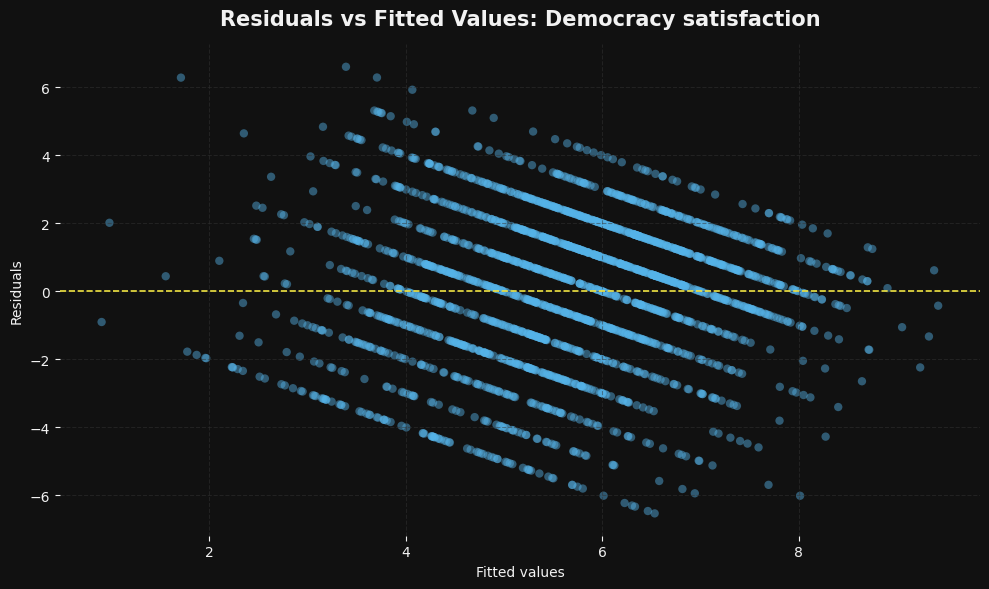

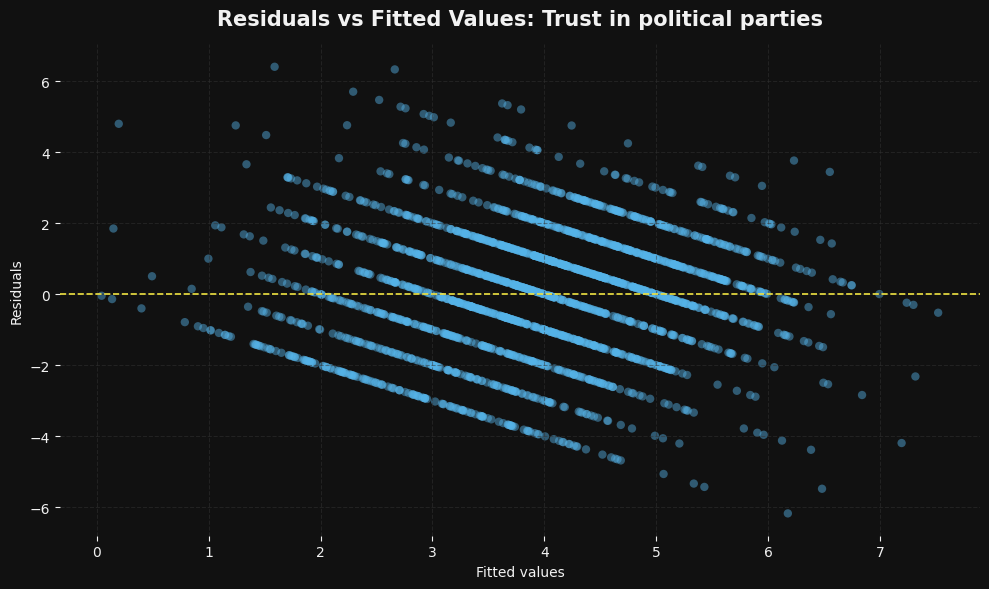

In [112]:
# 63.3 Visualize residuals versus fitted values

import matplotlib.pyplot as plt

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

models_for_diagnostics = [
    {
        "model_name": "Democracy satisfaction",
        "model_object": model_stfdem,
        "filename": "07_residuals_democracy_satisfaction_dark.png"
    },
    {
        "model_name": "Trust in political parties",
        "model_object": model_party_trust,
        "filename": "08_residuals_party_trust_dark.png"
    }
]

for item in models_for_diagnostics:
    model_name = item["model_name"]
    model_object = item["model_object"]
    filename = item["filename"]
    
    fitted_values = model_object.fittedvalues
    residuals = model_object.resid
    
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(dark_bg)
    ax.set_facecolor(dark_bg)
    
    ax.scatter(
        fitted_values,
        residuals,
        alpha=0.45,
        color="#56B4E9",
        edgecolors="none"
    )
    
    ax.axhline(0, color="#F0E442", linestyle="--", linewidth=1.2)
    
    ax.set_title(
        f"Residuals vs Fitted Values: {model_name}",
        color=text_col,
        fontsize=15,
        weight="bold",
        pad=14
    )
    
    ax.set_xlabel("Fitted values", color=text_col)
    ax.set_ylabel("Residuals", color=text_col)
    
    ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
    ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
    
    ax.tick_params(axis="x", colors=text_col)
    ax.tick_params(axis="y", colors=text_col)
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(
        viz_path / filename,
        dpi=300,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.show()

### 63.3 Interpretation of residual plots

The residual plots compare fitted values with model residuals.

A good residual pattern should not show a strong systematic curve or funnel shape.

Some structure is expected because the outcome variables are bounded survey scales from 0 to 10. This means that residuals cannot behave exactly like residuals from a fully continuous normally distributed variable.

The goal is therefore not perfect residual normality, but checking whether the model shows severe visible problems.

If the residuals are broadly centered around zero and do not show a strong systematic pattern, the model can be used for cautious interpretation.

### 63.4 Visualize observed versus predicted values

This step compares observed values with predicted values from the regression models.

The diagonal reference line represents perfect prediction. Points closer to the line are predicted more accurately, while points farther away from the line show larger prediction errors.

The goal is not to achieve perfect individual-level prediction. Instead, the plot helps assess whether the model captures general tendencies in the data.

Because democratic attitudes are complex and measured on 0–10 survey scales, the model is expected to explain meaningful patterns without predicting every individual response precisely.

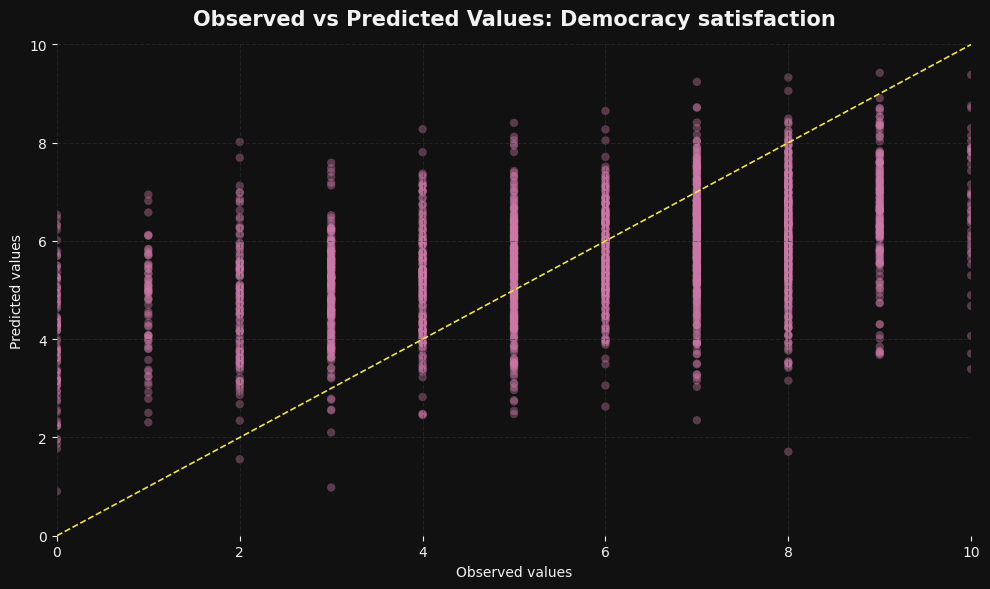

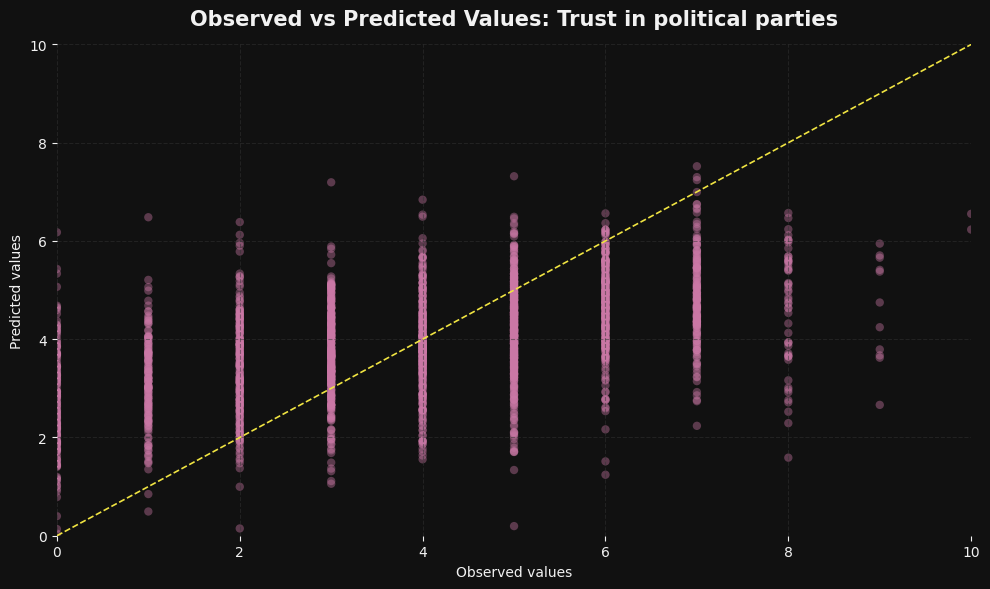

In [113]:
# 63.4 Visualize observed versus predicted values

prediction_plots = [
    {
        "model_name": "Democracy satisfaction",
        "observed": df_reg["stfdem"],
        "predicted": model_stfdem.fittedvalues,
        "filename": "09_observed_predicted_democracy_satisfaction_dark.png"
    },
    {
        "model_name": "Trust in political parties",
        "observed": df_reg["trstprt"],
        "predicted": model_party_trust.fittedvalues,
        "filename": "10_observed_predicted_party_trust_dark.png"
    }
]

for item in prediction_plots:
    model_name = item["model_name"]
    observed = item["observed"]
    predicted = item["predicted"]
    filename = item["filename"]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(dark_bg)
    ax.set_facecolor(dark_bg)
    
    ax.scatter(
        observed,
        predicted,
        alpha=0.4,
        color="#CC79A7",
        edgecolors="none"
    )
    
    ax.plot(
        [0, 10],
        [0, 10],
        color="#F0E442",
        linestyle="--",
        linewidth=1.2
    )
    
    ax.set_title(
        f"Observed vs Predicted Values: {model_name}",
        color=text_col,
        fontsize=15,
        weight="bold",
        pad=14
    )
    
    ax.set_xlabel("Observed values", color=text_col)
    ax.set_ylabel("Predicted values", color=text_col)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    
    ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
    ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
    
    ax.tick_params(axis="x", colors=text_col)
    ax.tick_params(axis="y", colors=text_col)
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(
        viz_path / filename,
        dpi=300,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    plt.show()

### 63.4 Interpretation of observed versus predicted values

This step compares observed survey responses with the values predicted by the regression models.

Because the outcomes are 0–10 survey scales, the model is not expected to predict each individual response perfectly.

The purpose is to check whether predictions broadly follow the observed values and whether there are obvious systematic problems.

These plots are useful for communicating that the models identify meaningful tendencies, but they do not fully explain individual democratic attitudes.

### 63.5 Export regression diagnostics

This step exports the regression diagnostic summary tables.

The exported files can be used for documentation, final reporting and presentation preparation.

Keeping these outputs makes the analytical process more reproducible and helps show that the regression models were checked before interpretation.

In [157]:
# 63.5 Export regression diagnostics outputs

vif_results_recheck.to_csv("../data/processed/regression_vif_results.csv", index=False)
diagnostic_summary.to_csv("../data/processed/regression_diagnostic_summary.csv", index=False)

print("Regression diagnostics exported to ../data/processed/")

Regression diagnostics exported to ../data/processed/


### 63.5 Interpretation of regression robustness checks

The regression diagnostics help assess whether the two main models are methodologically acceptable for the next analytical phase.

The models explain a meaningful share of variation in democratic satisfaction and trust in political parties, especially considering that the data is cross-sectional survey data.

The key analytical result remains stable: political efficacy and social trust are the strongest predictors in both models.

The diagnostics should be interpreted pragmatically. The models are not designed to prove causality or perfectly predict individual attitudes. Instead, they provide evidence that the observed patterns are robust enough to inform further exploratory profiling, visualization and strategic interpretation.

The next analytical step is to translate these validated patterns into Democratic Connection Profiles.

### 63.6 Interpretation of regression diagnostics

The regression diagnostics do not indicate severe model problems, but they show the expected limitations of modeling survey scale outcomes.

The residual plots show visible diagonal bands. This is expected because the outcome variables are discrete 0–10 survey scales. Since residuals are calculated as observed minus predicted values, discrete observed values naturally create parallel residual lines.

The residuals are broadly centered around zero, which suggests that the models do not systematically overpredict or underpredict the outcomes on average.

The observed-versus-predicted plots show that the models capture general tendencies, but they do not perfectly predict individual responses. This is expected for cross-sectional social survey data, where attitudes toward democracy are shaped by many observed and unobserved factors.

The model fit is meaningful but not exhaustive. The democracy satisfaction model explains about one quarter of the variation in the outcome, while the party trust model explains slightly more. This supports using the models for evidence-informed interpretation, but not for causal claims or precise individual-level prediction.

Overall, the diagnostics support the continued use of the regression models as interpretable associational models. The strongest substantive finding remains stable: political efficacy and social trust are the most important predictors in the current model setup.

## 64. Democratic Connection Profiles

This section moves from variable-based analysis to respondent profile analysis.

The previous steps showed that political efficacy, social trust, voting participation and party trust are central dimensions of democratic connection in the ESS11 Germany data.

The goal of this section is to explore whether respondents can be grouped into meaningful democratic connection profiles.

Instead of only asking which individual variables are associated with democratic trust, clustering asks whether combinations of attitudes form recognizable patterns.

This is useful for the strategic part of the project because different democratic trust problems may require different political responses.

The clustering analysis is exploratory. It does not prove fixed population types, but it can help identify analytically useful trust profiles.

### 64.1 Prepare clustering dataset

This step prepares the dataset for clustering.

K-Means clustering works best with numerical variables that are measured on comparable scales. Therefore, the selected variables are standardized before clustering.

The selected variables reflect the main analytical dimensions of the project:

- satisfaction with democracy
- trust in political parties
- political efficacy
- social trust
- subjective income feeling
- left-right self-placement
- voting behavior

These variables combine democratic attitudes, perceived political agency, social confidence, socio-economic perception and political participation.

In [115]:
# 64.1 Prepare clustering dataset

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_vars = [
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "vote_binary"
]

cluster_labels = {
    "stfdem": "Democracy satisfaction",
    "trstprt": "Trust in political parties",
    "political_efficacy_index": "Political efficacy",
    "social_trust_index": "Social trust",
    "hincfel": "Income feeling",
    "lrscale": "Left-right placement",
    "vote_binary": "Voted"
}

df_cluster = df_reg[cluster_vars].dropna().copy()

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(df_cluster)

print("Clustering dataset shape:", df_cluster.shape)
df_cluster.head()

Clustering dataset shape: (2064, 7)


,stfdem,trstprt,political_efficacy_index,social_trust_index,hincfel,lrscale,vote_binary
8256,8.0,5.0,2.75,3.333333,1.0,5.0,1
8257,7.0,3.0,2.75,7.333333,2.0,3.0,1
8259,8.0,7.0,2.00,6.666667,1.0,5.0,1
8260,8.0,7.0,3.25,7.333333,1.0,6.0,1
8261,9.0,7.0,3.25,4.666667,2.0,3.0,1


### 64.2 Elbow Method for selecting the number of clusters

This step uses the Elbow Method to explore how many clusters may be suitable.

The Elbow Method calculates the within-cluster sum of squares for different numbers of clusters. Lower values indicate that respondents are grouped more tightly around their cluster centers.

The goal is to identify a point where adding more clusters no longer improves the model substantially.

This method does not give a perfect answer, but it provides a first indication for a reasonable number of clusters.

In [116]:
# 64.2 Elbow Method for selecting the number of clusters

wcss = []

cluster_range = range(2, 9)

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    "n_clusters": list(cluster_range),
    "wcss": wcss
})

elbow_df

,n_clusters,wcss
0,2,10959.467516
1,3,9205.486139
2,4,8408.636559
3,5,7780.719657
4,6,7339.492445
5,7,6997.910025
6,8,6672.097531


### 64.3 Visualize the Elbow Method

This step visualizes the Elbow Method results.

The chart helps identify whether there is a visible bend in the curve. A clear bend suggests a potentially useful number of clusters.

If the curve decreases smoothly without a clear elbow, the final number of clusters should also be guided by interpretability and strategic usefulness.

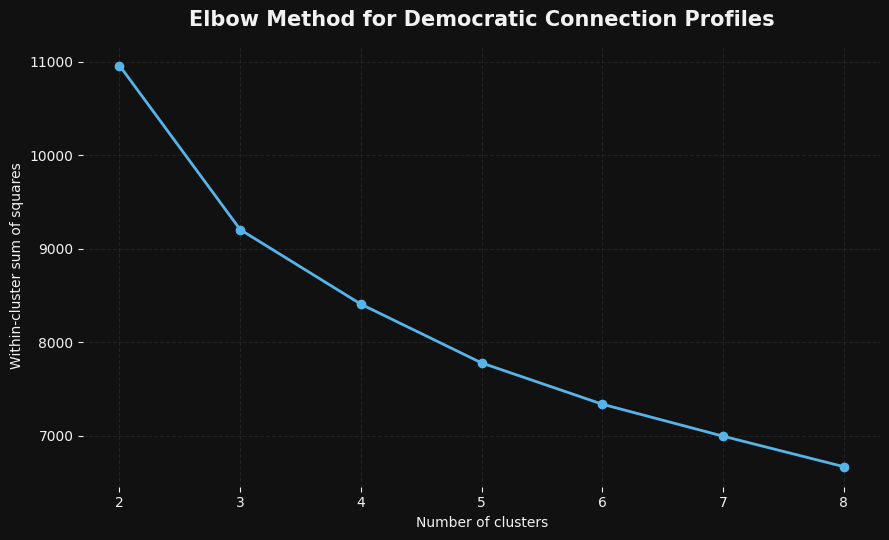

In [117]:
# 64.3 Visualize the Elbow Method

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

ax.plot(
    elbow_df["n_clusters"],
    elbow_df["wcss"],
    marker="o",
    linewidth=2,
    color="#56B4E9"
)

ax.set_title(
    "Elbow Method for Democratic Connection Profiles",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Number of clusters", color=text_col)
ax.set_ylabel("Within-cluster sum of squares", color=text_col)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    viz_path / "11_elbow_method_democratic_connection_profiles_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### 64.4 Silhouette Scores for cluster validation

This step calculates Silhouette Scores for different numbers of clusters.

The Silhouette Score measures how well each respondent fits within their assigned cluster compared with other clusters.

Values range from -1 to 1.

- Higher values indicate better separation between clusters.
- Values close to 0 indicate overlapping clusters.
- Negative values suggest that some observations may fit better into another cluster.

For social survey data, very high Silhouette Scores are uncommon because human attitudes often overlap. Therefore, the result should be interpreted together with the Elbow Method and the substantive interpretability of the final profiles.

In [118]:
# 64.4 Calculate Silhouette Scores

silhouette_results = []

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    cluster_assignments = kmeans.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, cluster_assignments)
    
    silhouette_results.append({
        "n_clusters": k,
        "silhouette_score": score
    })

silhouette_df = pd.DataFrame(silhouette_results).round(3)

silhouette_df

,n_clusters,silhouette_score
0,2,0.232
1,3,0.238
2,4,0.159
3,5,0.164
4,6,0.167
5,7,0.158
6,8,0.158


### 64.5 Visualize Silhouette Scores

This step visualizes the Silhouette Scores for different numbers of clusters.

The chart supports the decision on the final number of clusters.

The best solution is not necessarily the one with the highest score only. The final choice should balance statistical quality, interpretability and usefulness for the project storyline.

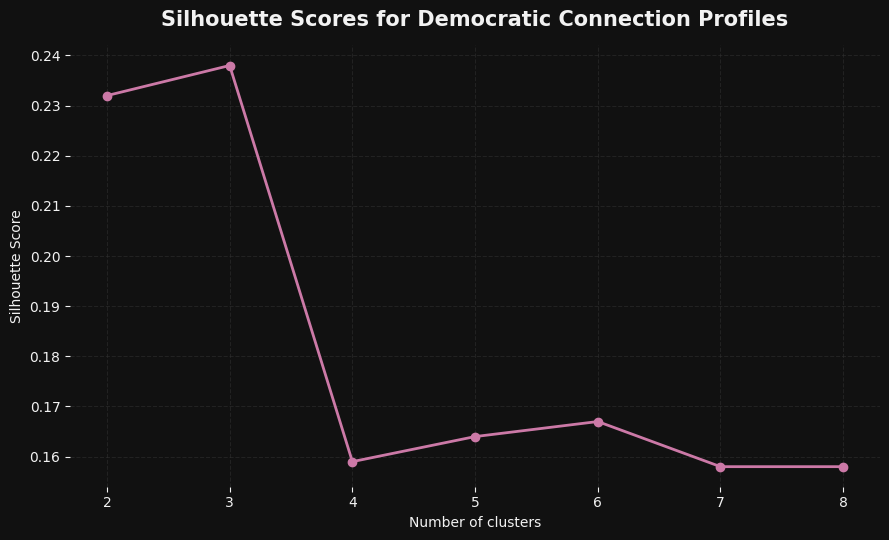

In [119]:
# 64.5 Visualize Silhouette Scores

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

ax.plot(
    silhouette_df["n_clusters"],
    silhouette_df["silhouette_score"],
    marker="o",
    linewidth=2,
    color="#CC79A7"
)

ax.set_title(
    "Silhouette Scores for Democratic Connection Profiles",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Number of clusters", color=text_col)
ax.set_ylabel("Silhouette Score", color=text_col)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    viz_path / "12_silhouette_scores_democratic_connection_profiles_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### 64.6 Interim interpretation of cluster validation

This step prepares the interpretation of the Elbow Method and Silhouette Scores.

The final number of clusters should be selected based on three criteria:

1. statistical indication from the Elbow Method
2. statistical indication from the Silhouette Scores
3. substantive interpretability for democratic trust profiles

For this project, a cluster solution is only useful if the resulting groups can be translated into meaningful democratic connection profiles.

Possible profile types may include:

- democratically connected respondents
- politically powerless but reachable respondents
- socially distrustful respondents
- democratically disconnected respondents

The next step is to choose a final number of clusters and inspect the resulting profile characteristics.

### 64.6.2 Select final cluster solution

Based on the Elbow Method and the Silhouette Scores, a three-cluster solution is selected for the main exploratory profile analysis.

The Elbow Method shows the strongest improvement when moving from two to three clusters. After three clusters, the reduction in within-cluster sum of squares becomes more gradual.

The Silhouette Score is also highest for three clusters. Although the score is moderate, this is expected in social survey data where attitudes often overlap rather than forming perfectly separated groups.

A two-cluster solution would be easier to separate statistically, but it would likely be too simplistic for the project because it would mainly distinguish between more connected and less connected respondents.

A four-cluster solution would offer more detail, but the Silhouette Score drops substantially, making it less convincing as the main cluster solution.

Therefore, three clusters are used as the main exploratory Democratic Connection Profile solution.

In [120]:
# 64.6 Select final cluster solution

final_k = 3

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

df_cluster["cluster"] = kmeans_final.fit_predict(cluster_scaled)

df_cluster["cluster"].value_counts().sort_index()

cluster
0     810
1    1027
2     227
Name: count, dtype: int64

### 64.7 Add cluster labels to the regression dataset

This step adds the final cluster assignment to the model-ready regression dataset.

Each respondent in the clustering dataset receives a cluster label from 0 to 2.

The numerical cluster labels do not yet have substantive meaning. They will be interpreted in the next step by comparing the average values of key variables within each cluster.

In [121]:
# 64.7 Add cluster labels to the regression dataset

df_profiles = df_reg.loc[df_cluster.index].copy()
df_profiles["cluster"] = df_cluster["cluster"]

print("Profile dataset shape:", df_profiles.shape)
df_profiles["cluster"].value_counts().sort_index()

Profile dataset shape: (2064, 19)


cluster
0     810
1    1027
2     227
Name: count, dtype: int64

### 64.8 Profile characteristics by cluster

This step compares the average values of the main clustering variables across the three clusters.

The goal is to understand what distinguishes the clusters from each other.

The cluster interpretation focuses on:

- democratic satisfaction
- trust in political parties
- political efficacy
- social trust
- subjective income feeling
- left-right self-placement
- voting behavior

This is the key step for translating technical clusters into meaningful Democratic Connection Profiles.

In [122]:
# 64.8 Profile characteristics by cluster

profile_summary = (
    df_profiles
    .groupby("cluster")[cluster_vars]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

profile_summary

stfdem                    trstprt                     \
         count  mean median   std   count  mean median   std   
cluster                                                        
0          810  3.91    4.0  2.22     810  2.46    3.0  1.62   
1         1027  7.22    7.0  1.51    1027  5.30    5.0  1.51   
2          227  4.42    4.0  2.68     227  2.91    3.0  2.26   

        political_efficacy_index        ... hincfel       lrscale        \
                           count  mean  ...  median   std   count  mean   
cluster                                 ...                               
0                            810  2.14  ...     2.0  0.65     810  5.12   
1                           1027  2.91  ...     1.0  0.53    1027  4.04   
2                            227  2.06  ...     2.0  0.82     227  4.74   

                     vote_binary                   
        median   std       count mean median  std  
cluster                                            
0          5.0  1.74         810  1.0    1.0  0.0  
1          4.0  1.64        1027  1.0    1.0  0.0  
2          5.0  1.78         227  0.0    0.0  0.0  

[3 rows x 28 columns]

### 64.9 Simplified profile summary

This step creates a simplified cluster profile table using mean values only.

This table is easier to interpret than the full descriptive statistics table and will be useful for storytelling, dashboarding and presentation slides.

In [123]:
# 64.9 Simplified profile summary

profile_means = (
    df_profiles
    .groupby("cluster")[cluster_vars]
    .mean()
    .round(2)
)

profile_means_labeled = profile_means.rename(columns=cluster_labels)

profile_means_labeled

,Democracy satisfaction,Trust in political parties,Political efficacy,Social trust,Income feeling,Left-right placement,Voted
cluster,,,,,,,
0,3.91,2.46,2.14,4.82,1.72,5.12,1.0
1,7.22,5.30,2.91,6.40,1.36,4.04,1.0
2,4.42,2.91,2.06,4.98,1.95,4.74,0.0


### 64.10 Cluster size table

This step calculates the number and percentage of respondents in each cluster.

Cluster size is important for interpretation because a very small cluster may be analytically interesting but less useful for broad strategic conclusions.

The percentage values help communicate how large each Democratic Connection Profile is within the cleaned analysis sample.

In [124]:
# 64.10 Cluster size table

cluster_size_table = (
    df_profiles["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_size_table.columns = ["cluster", "n_respondents"]

cluster_size_table["percentage"] = (
    cluster_size_table["n_respondents"] / cluster_size_table["n_respondents"].sum() * 100
).round(1)

cluster_size_table

,cluster,n_respondents,percentage
0,0,810,39.2
1,1,1027,49.8
2,2,227,11.0


### 64.11 Visualize Democratic Connection Profiles

This visualization compares the three clusters across the most important democratic connection variables.

The chart helps identify the substantive profile of each cluster.

Because the selected variables use different scales, the chart is based on standardized mean values.

Values above zero indicate that a cluster scores above the sample average on a variable. Values below zero indicate that a cluster scores below the sample average.

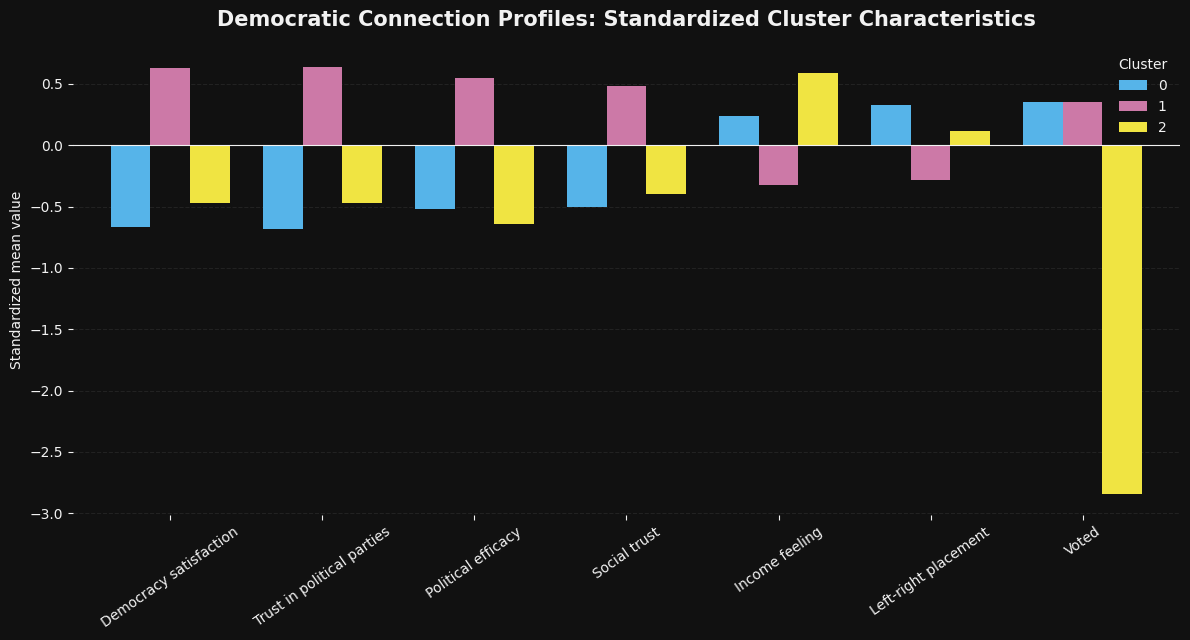

,Democracy satisfaction,Trust in political parties,Political efficacy,Social trust,Income feeling,Left-right placement,Voted
cluster,,,,,,,
0,-0.67,-0.68,-0.52,-0.50,0.24,0.33,0.35
1,0.63,0.64,0.55,0.48,-0.32,-0.28,0.35
2,-0.47,-0.47,-0.64,-0.40,0.59,0.12,-2.84


In [125]:
# 64.11 Visualize Democratic Connection Profiles using standardized means

cluster_scaled_df = pd.DataFrame(
    cluster_scaled,
    columns=[cluster_labels[var] for var in cluster_vars],
    index=df_cluster.index
)

cluster_scaled_df["cluster"] = df_cluster["cluster"]

cluster_profile_z = (
    cluster_scaled_df
    .groupby("cluster")
    .mean()
    .round(2)
)

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

fig, ax = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

cluster_profile_z.T.plot(
    kind="bar",
    ax=ax,
    width=0.78,
    color=["#56B4E9", "#CC79A7", "#F0E442"]
)

ax.axhline(0, color=text_col, linewidth=0.8)

ax.set_title(
    "Democratic Connection Profiles: Standardized Cluster Characteristics",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("")
ax.set_ylabel("Standardized mean value", color=text_col)

ax.tick_params(axis="x", colors=text_col, rotation=35)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    title="Cluster",
    frameon=False,
    loc="upper right"
)

legend.get_title().set_color(text_col)

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "13_democratic_connection_profiles_standardized_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

cluster_profile_z

### 64.12 Name Democratic Connection Profiles

This step assigns substantive names to the three clusters.

The numerical cluster labels are replaced with interpretable profile names based on the average values of democratic satisfaction, party trust, political efficacy, social trust, income feeling and voting behavior.

The profile names are analytical labels. They should not be interpreted as fixed identities of respondents, but as exploratory democratic connection profiles within the ESS11 Germany sample.

In [126]:
# 64.12 Name Democratic Connection Profiles

cluster_name_map = {
    0: "At-risk democratic participants",
    1: "Connected democratic core",
    2: "Disengaged non-voters"
}

df_profiles["connection_profile"] = df_profiles["cluster"].map(cluster_name_map)

df_profiles["connection_profile"].value_counts()

connection_profile
Connected democratic core          1027
At-risk democratic participants     810
Disengaged non-voters               227
Name: count, dtype: int64

### 64.13 Create final Democratic Connection Profile summary

This step creates a final summary table for the three Democratic Connection Profiles.

The table includes the number of respondents, percentage of the profile and mean values for the main analytical variables.

This table translates the cluster analysis into a format that can be used for interpretation, dashboarding and final presentation.

In [127]:
# 64.13 Create final Democratic Connection Profile summary

profile_summary_final = (
    df_profiles
    .groupby("connection_profile")
    .agg(
        n_respondents=("connection_profile", "size"),
        democracy_satisfaction=("stfdem", "mean"),
        trust_in_political_parties=("trstprt", "mean"),
        political_efficacy=("political_efficacy_index", "mean"),
        social_trust=("social_trust_index", "mean"),
        income_feeling=("hincfel", "mean"),
        left_right_placement=("lrscale", "mean"),
        voted=("vote_binary", "mean")
    )
    .reset_index()
)

profile_summary_final["percentage"] = (
    profile_summary_final["n_respondents"] / profile_summary_final["n_respondents"].sum() * 100
)

profile_summary_final = profile_summary_final[
    [
        "connection_profile",
        "n_respondents",
        "percentage",
        "democracy_satisfaction",
        "trust_in_political_parties",
        "political_efficacy",
        "social_trust",
        "income_feeling",
        "left_right_placement",
        "voted"
    ]
].round(2)

profile_summary_final

,connection_profile,n_respondents,percentage,democracy_satisfaction,trust_in_political_parties,political_efficacy,social_trust,income_feeling,left_right_placement,voted
0,At-risk democratic participants,810,39.24,3.91,2.46,2.14,4.82,1.72,5.12,1.0
1,Connected democratic core,1027,49.76,7.22,5.30,2.91,6.40,1.36,4.04,1.0
2,Disengaged non-voters,227,11.00,4.42,2.91,2.06,4.98,1.95,4.74,0.0


### 64.14 Export Democratic Connection Profiles

This step exports the profile-level summary and the respondent-level dataset with profile labels.

The profile summary can be used in the final presentation and dashboard.

The respondent-level dataset can be used for Tableau, additional visualizations or further exploratory analysis.

In [128]:
# 64.14 Export Democratic Connection Profiles

profile_summary_final.to_csv(
    "../data/processed/democratic_connection_profile_summary.csv",
    index=False
)

df_profiles.to_csv(
    "../data/clean/ess11_germany_democratic_connection_profiles.csv",
    index=False
)

print("Profile summary exported to ../data/processed/")
print("Respondent-level profile dataset exported to ../data/clean/")

Profile summary exported to ../data/processed/
Respondent-level profile dataset exported to ../data/clean/


### 64.15 Interpretation of Democratic Connection Profiles

The cluster analysis identifies three exploratory Democratic Connection Profiles in the ESS11 Germany sample.

The largest group is the Connected Democratic Core. Respondents in this profile show the highest democratic satisfaction, highest party trust, highest political efficacy and highest social trust. This group appears comparatively well connected to democratic institutions and political participation.

The second major group is At-risk Democratic Participants. Respondents in this profile still report voting, but they show low democratic satisfaction, low party trust, low political efficacy and lower social trust. This is strategically important because democratic disconnection is visible even among people who still participate electorally.

The smallest group is Disengaged Non-voters. Respondents in this profile did not vote and also show low political efficacy, low party trust and lower democratic satisfaction. This profile is relevant for democratic re-engagement, but it is not the only group where democratic connection is weak.

The main analytical insight is that democratic disconnection should not be understood only as non-voting. A substantial share of respondents still vote while already showing signs of weaker democratic connection.

The cluster analysis is exploratory and should be interpreted as a segmentation tool, not as causal evidence.

### 64.16 Robustness check: clustering without voting behavior

This step tests whether the Democratic Connection Profiles are mainly driven by voting behavior or whether similar attitudinal patterns also appear without including voting behavior in the clustering variables.

The previous cluster model included voting behavior as one dimension of democratic connection. This is useful because participation is part of the project’s concept. However, including voting behavior can strongly shape one cluster around non-voters.

To check the robustness of the profiles, this step repeats the clustering without `vote_binary`.

The clustering variables are:

- satisfaction with democracy
- trust in political parties
- political efficacy index
- social trust index
- income feeling
- left-right placement

The results are exploratory and are used to assess whether democratic connection profiles remain visible when electoral participation is excluded from the clustering process.

In [129]:
# 64.16 Robustness check: clustering without voting behavior

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

robustness_cluster_vars = [
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale"
]

df_cluster_robust = df_de[
    robustness_cluster_vars + ["vote_clean"]
].dropna().copy()

scaler_robust = StandardScaler()

X_robust = scaler_robust.fit_transform(
    df_cluster_robust[robustness_cluster_vars]
)

robustness_results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = kmeans.fit_predict(X_robust)
    
    robustness_results.append({
        "n_clusters": k,
        "wcss": kmeans.inertia_,
        "silhouette_score": silhouette_score(X_robust, labels)
    })

robustness_results_df = pd.DataFrame(robustness_results)

robustness_results_df.round(3)

,n_clusters,wcss,silhouette_score
0,2,9055.035,0.244
1,3,8129.520,0.152
2,4,7380.416,0.161
3,5,6894.936,0.164
4,6,6483.383,0.153
5,7,6155.738,0.156
6,8,5866.908,0.157


### 64.17 Visualize robustness check results

This step visualizes the elbow method and silhouette scores for the robustness clustering model without voting behavior.

The goal is to assess whether a small number of meaningful democratic connection profiles can still be identified when participation is excluded from the clustering variables.

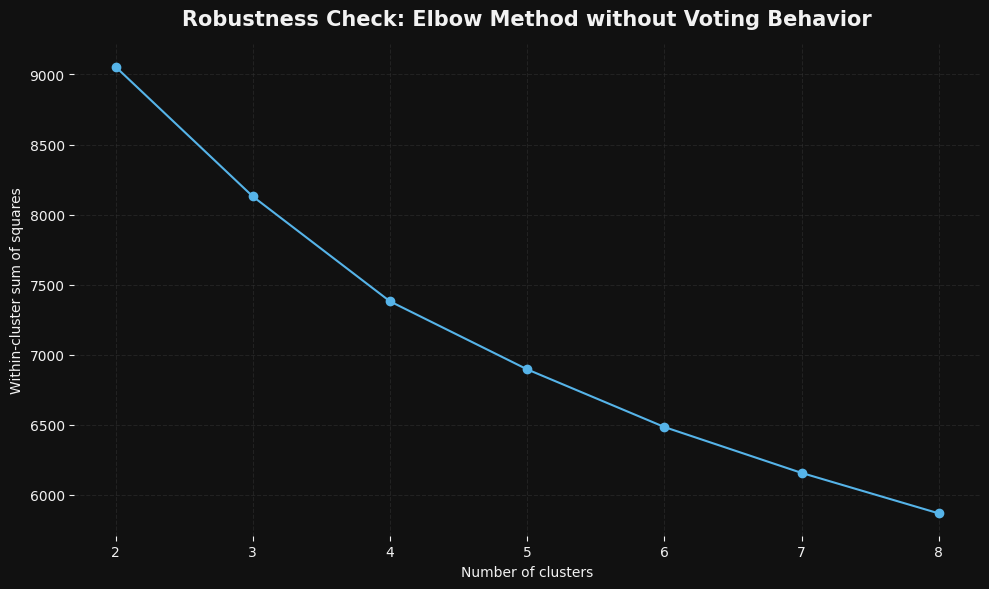

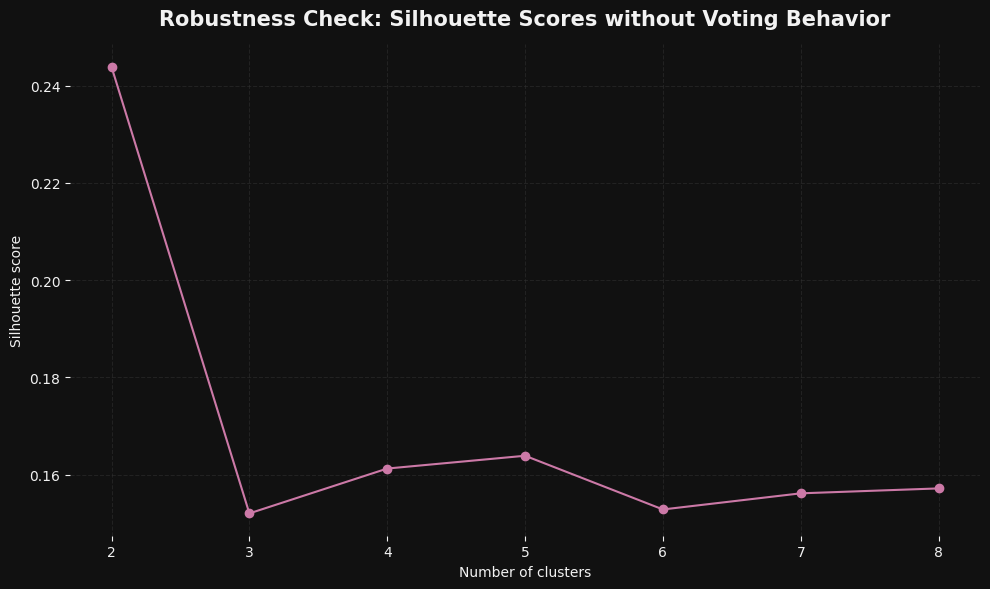

,n_clusters,wcss,silhouette_score
0,2,9055.035,0.244
1,3,8129.520,0.152
2,4,7380.416,0.161
3,5,6894.936,0.164
4,6,6483.383,0.153
5,7,6155.738,0.156
6,8,5866.908,0.157


In [130]:
# 64.17 Visualize robustness check results

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

ax.plot(
    robustness_results_df["n_clusters"],
    robustness_results_df["wcss"],
    marker="o",
    color="#56B4E9"
)

ax.set_title(
    "Robustness Check: Elbow Method without Voting Behavior",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Number of clusters", color=text_col)
ax.set_ylabel("Within-cluster sum of squares", color=text_col)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    viz_path / "12_robustness_elbow_without_voting_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

ax.plot(
    robustness_results_df["n_clusters"],
    robustness_results_df["silhouette_score"],
    marker="o",
    color="#CC79A7"
)

ax.set_title(
    "Robustness Check: Silhouette Scores without Voting Behavior",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Number of clusters", color=text_col)
ax.set_ylabel("Silhouette score", color=text_col)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)
ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.5)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    viz_path / "13_robustness_silhouette_without_voting_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

robustness_results_df.round(3)

### 64.18 Interpretation of the robustness check

The robustness check provides an important methodological insight.

When voting behavior is excluded from the clustering variables, the cluster diagnostics no longer clearly support a three-cluster solution. The highest silhouette score appears for a two-cluster solution. This suggests that the attitudinal structure of democratic connection is mainly organized along a broad high-versus-low connection dimension.

In other words, without voting behavior, the data primarily separates respondents with stronger democratic connection from respondents with weaker democratic connection.

This does not invalidate the previous three-cluster solution. Instead, it clarifies its meaning.

The three-cluster model including voting behavior is more useful for the strategic purpose of this project because political participation is part of democratic connection. Including voting behavior separates low-trust respondents who still vote from low-trust respondents who do not vote. This distinction is politically important because these groups may require different democratic engagement strategies.

Therefore, the project keeps the three-cluster solution with voting behavior as the main profile model, while using the robustness check as a methodological qualification.

The interpretation is:

- without voting behavior, democratic connection mainly separates into higher and lower connection
- with voting behavior included, the model identifies a more actionable third profile of disengaged non-voters
- the final profile model should therefore be interpreted as a strategic segmentation, not as a purely mechanical statistical classification

### 64.19 Final decision on Democratic Connection Profiles

Based on the clustering diagnostics, profile interpretability and strategic relevance, the project proceeds with the three-cluster solution including voting behavior.

This decision is based on three reasons.

First, voting behavior is conceptually relevant. Democratic connection is not only about attitudes toward democracy and institutions, but also about whether people participate politically.

Second, the three-cluster solution produces interpretable and politically meaningful profiles. It distinguishes between respondents with strong democratic connection, respondents with weak democratic connection who still vote, and respondents with weak democratic connection who did not vote.

Third, the robustness check shows that without voting behavior the data mainly separates into a high-connection and a low-connection structure. Including voting behavior adds strategic value by separating different forms of democratic disconnection.

The final profiles are interpreted as exploratory Democratic Connection Profiles. They do not represent fixed social groups or causal types. Instead, they are data-driven profiles that help translate survey patterns into strategic questions for democratic engagement.

In [133]:
# Check available DataFrames that may contain cluster results

available_cluster_objects = [
    name for name in globals()
    if "cluster" in name.lower() or "profile" in name.lower()
]

available_cluster_objects

['cluster_vars',
 'cluster_labels',
 'df_cluster',
 'cluster_scaled',
 'cluster_range',
 'cluster_assignments',
 'df_profiles',
 'profile_summary',
 'profile_means',
 'profile_means_labeled',
 'cluster_size_table',
 'cluster_scaled_df',
 'cluster_profile_z',
 'cluster_name_map',
 'profile_summary_final',
 'robustness_cluster_vars',
 'df_cluster_robust',
 'cluster_label_map']

In [135]:
# 64.19b Define final clustered dataset

df_clustered = df_cluster.copy()

print("df_clustered shape:", df_clustered.shape)
print("Cluster distribution:")
print(df_clustered["cluster"].value_counts().sort_index())

df_clustered shape: (2064, 8)
Cluster distribution:
cluster
0     810
1    1027
2     227
Name: count, dtype: int64


### 64.20 Label Democratic Connection Profiles

This step assigns meaningful names to the three clusters.

The cluster labels translate the numerical cluster solution into interpretable Democratic Connection Profiles.

The labels are based on the observed cluster characteristics:

- democracy satisfaction
- trust in political parties
- political efficacy
- social trust
- income feeling
- left-right placement
- voting behavior

The goal is not to claim that these are fixed social groups. Instead, the labels help communicate the main patterns in a clearer and more strategic way.

In [136]:
# 64.20 Label Democratic Connection Profiles

cluster_label_map = {
    0: "Disappointed Democratic Participants",
    1: "Connected Democratic Core",
    2: "Disengaged Non-voters"
}

df_clustered["democratic_connection_profile"] = df_clustered["cluster"].map(cluster_label_map)

df_clustered[[
    "cluster",
    "democratic_connection_profile",
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "vote_binary"
]].head()

,cluster,democratic_connection_profile,stfdem,trstprt,political_efficacy_index,social_trust_index,hincfel,lrscale,vote_binary
8256,1,Connected Democratic Core,8.0,5.0,2.75,3.333333,1.0,5.0,1
8257,1,Connected Democratic Core,7.0,3.0,2.75,7.333333,2.0,3.0,1
8259,1,Connected Democratic Core,8.0,7.0,2.00,6.666667,1.0,5.0,1
8260,1,Connected Democratic Core,8.0,7.0,3.25,7.333333,1.0,6.0,1
8261,1,Connected Democratic Core,9.0,7.0,3.25,4.666667,2.0,3.0,1


In [137]:
profile_summary

stfdem                    trstprt                     \
         count  mean median   std   count  mean median   std   
cluster                                                        
0          810  3.91    4.0  2.22     810  2.46    3.0  1.62   
1         1027  7.22    7.0  1.51    1027  5.30    5.0  1.51   
2          227  4.42    4.0  2.68     227  2.91    3.0  2.26   

        political_efficacy_index        ... hincfel       lrscale        \
                           count  mean  ...  median   std   count  mean   
cluster                                 ...                               
0                            810  2.14  ...     2.0  0.65     810  5.12   
1                           1027  2.91  ...     1.0  0.53    1027  4.04   
2                            227  2.06  ...     2.0  0.82     227  4.74   

                     vote_binary                   
        median   std       count mean median  std  
cluster                                            
0          5.0  1.74         810  1.0    1.0  0.0  
1          4.0  1.64        1027  1.0    1.0  0.0  
2          5.0  1.78         227  0.0    0.0  0.0  

[3 rows x 28 columns]

In [138]:
# 64.21 Create final Democratic Connection Profile table

profile_summary = (
    df_clustered
    .groupby("democratic_connection_profile")
    .agg(
        n_respondents=("democratic_connection_profile", "count"),
        democracy_satisfaction=("stfdem", "mean"),
        party_trust=("trstprt", "mean"),
        political_efficacy=("political_efficacy_index", "mean"),
        social_trust=("social_trust_index", "mean"),
        income_feeling=("hincfel", "mean"),
        left_right_placement=("lrscale", "mean"),
        voted_share=("vote_binary", "mean")
    )
    .reset_index()
)

profile_summary["percentage"] = (
    profile_summary["n_respondents"] / profile_summary["n_respondents"].sum() * 100
)

profile_summary = profile_summary[
    [
        "democratic_connection_profile",
        "n_respondents",
        "percentage",
        "democracy_satisfaction",
        "party_trust",
        "political_efficacy",
        "social_trust",
        "income_feeling",
        "left_right_placement",
        "voted_share"
    ]
]

profile_summary = profile_summary.round({
    "percentage": 1,
    "democracy_satisfaction": 2,
    "party_trust": 2,
    "political_efficacy": 2,
    "social_trust": 2,
    "income_feeling": 2,
    "left_right_placement": 2,
    "voted_share": 2
})

profile_summary

,democratic_connection_profile,n_respondents,percentage,democracy_satisfaction,party_trust,political_efficacy,social_trust,income_feeling,left_right_placement,voted_share
0,Connected Democratic Core,1027,49.8,7.22,5.30,2.91,6.40,1.36,4.04,1.0
1,Disappointed Democratic Participants,810,39.2,3.91,2.46,2.14,4.82,1.72,5.12,1.0
2,Disengaged Non-voters,227,11.0,4.42,2.91,2.06,4.98,1.95,4.74,0.0


## 65. Visualize Democratic Connection Profiles

This section visualizes the final Democratic Connection Profiles.

The previous clustering step identified three interpretable profiles:

- Connected Democratic Core
- Disappointed Democratic Participants
- Disengaged Non-voters

The goal of this section is to make the profile structure easier to understand for the final presentation, Streamlit app and possible dashboard development.

The visualizations focus on:

- profile size
- profile characteristics
- strategic interpretation

The profiles are exploratory and should be interpreted as data-driven segmentation patterns, not as fixed social groups.

In [139]:
# 65. Visualization setup for Democratic Connection Profiles

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

viz_path = Path("../visualizations")
viz_path.mkdir(parents=True, exist_ok=True)

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

profile_colors = {
    "Connected Democratic Core": "#009E73",
    "Disappointed Democratic Participants": "#CC79A7",
    "Disengaged Non-voters": "#F0E442"
}

print("Profile visualization setup completed.")

Profile visualization setup completed.


### 65.1 Visualize profile sizes

This visualization shows how large each Democratic Connection Profile is.

The chart helps communicate that democratic disconnection is not limited to non-voters. A substantial group still participates electorally but shows low democratic satisfaction and low party trust.

This is important for the project story because it separates democratic dissatisfaction from full political disengagement.

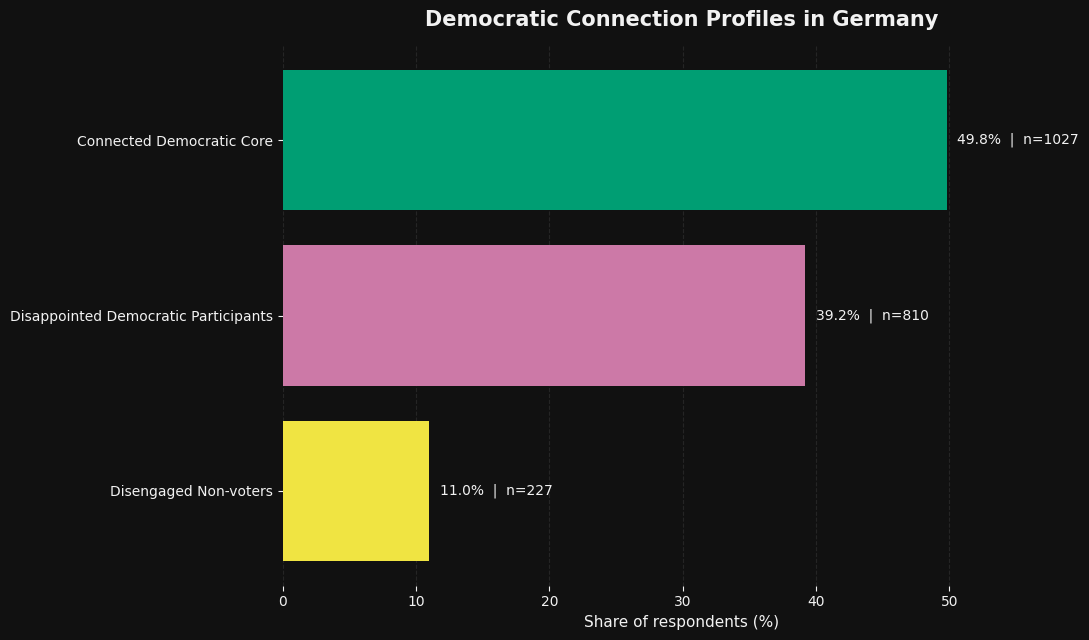

,democratic_connection_profile,n_respondents,percentage,democracy_satisfaction,party_trust,political_efficacy,social_trust,income_feeling,left_right_placement,voted_share
2,Disengaged Non-voters,227,11.0,4.42,2.91,2.06,4.98,1.95,4.74,0.0
1,Disappointed Democratic Participants,810,39.2,3.91,2.46,2.14,4.82,1.72,5.12,1.0
0,Connected Democratic Core,1027,49.8,7.22,5.30,2.91,6.40,1.36,4.04,1.0


In [140]:
# 65.1 Visualize Democratic Connection Profile sizes

profile_size_plot = profile_summary.sort_values("percentage", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

colors = [
    profile_colors/profile_colors.get(profile, "#56B4E9")
    if False else profile_colors.get(profile, "#56B4E9")
    for profile in profile_size_plot["democratic_connection_profile"]
]

bars = ax.barh(
    profile_size_plot["democratic_connection_profile"],
    profile_size_plot["percentage"],
    color=colors
)

ax.set_title(
    "Democratic Connection Profiles in Germany",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel("Share of respondents (%)", color=text_col, fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, max(profile_size_plot["percentage"]) + 10)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar, value, n in zip(
    bars,
    profile_size_plot["percentage"],
    profile_size_plot["n_respondents"]
):
    ax.text(
        value + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%  |  n={n}",
        va="center",
        color=text_col,
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    viz_path / "11_democratic_connection_profile_sizes_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

profile_size_plot

### 65.2 Visualize profile characteristics

This visualization compares the main characteristics of each Democratic Connection Profile.

The selected variables represent the core dimensions of the project:

- democracy satisfaction
- trust in political parties
- political efficacy
- social trust
- income feeling
- left-right placement
- voting participation

Because the variables are measured on different scales, this chart uses the original values and should be interpreted descriptively.

In [141]:
# 65.2 Visualize profile characteristics using original values

profile_characteristics = profile_summary[
    [
        "democratic_connection_profile",
        "democracy_satisfaction",
        "party_trust",
        "political_efficacy",
        "social_trust",
        "income_feeling",
        "left_right_placement",
        "voted_share"
    ]
].copy()

profile_characteristics_long = profile_characteristics.melt(
    id_vars="democratic_connection_profile",
    var_name="indicator",
    value_name="mean_value"
)

indicator_labels = {
    "democracy_satisfaction": "Democracy satisfaction",
    "party_trust": "Party trust",
    "political_efficacy": "Political efficacy",
    "social_trust": "Social trust",
    "income_feeling": "Income feeling",
    "left_right_placement": "Left-right placement",
    "voted_share": "Voted share"
}

profile_characteristics_long["indicator_label"] = profile_characteristics_long["indicator"].map(indicator_labels)

profile_characteristics_long

,democratic_connection_profile,indicator,mean_value,indicator_label
0,Connected Democratic Core,democracy_satisfaction,7.22,Democracy satisfaction
1,Disappointed Democratic Participants,democracy_satisfaction,3.91,Democracy satisfaction
2,Disengaged Non-voters,democracy_satisfaction,4.42,Democracy satisfaction
3,Connected Democratic Core,party_trust,5.30,Party trust
4,Disappointed Democratic Participants,party_trust,2.46,Party trust
5,Disengaged Non-voters,party_trust,2.91,Party trust
6,Connected Democratic Core,political_efficacy,2.91,Political efficacy
7,Disappointed Democratic Participants,political_efficacy,2.14,Political efficacy
8,Disengaged Non-voters,political_efficacy,2.06,Political efficacy
9,Connected Democratic Core,social_trust,6.40,Social trust


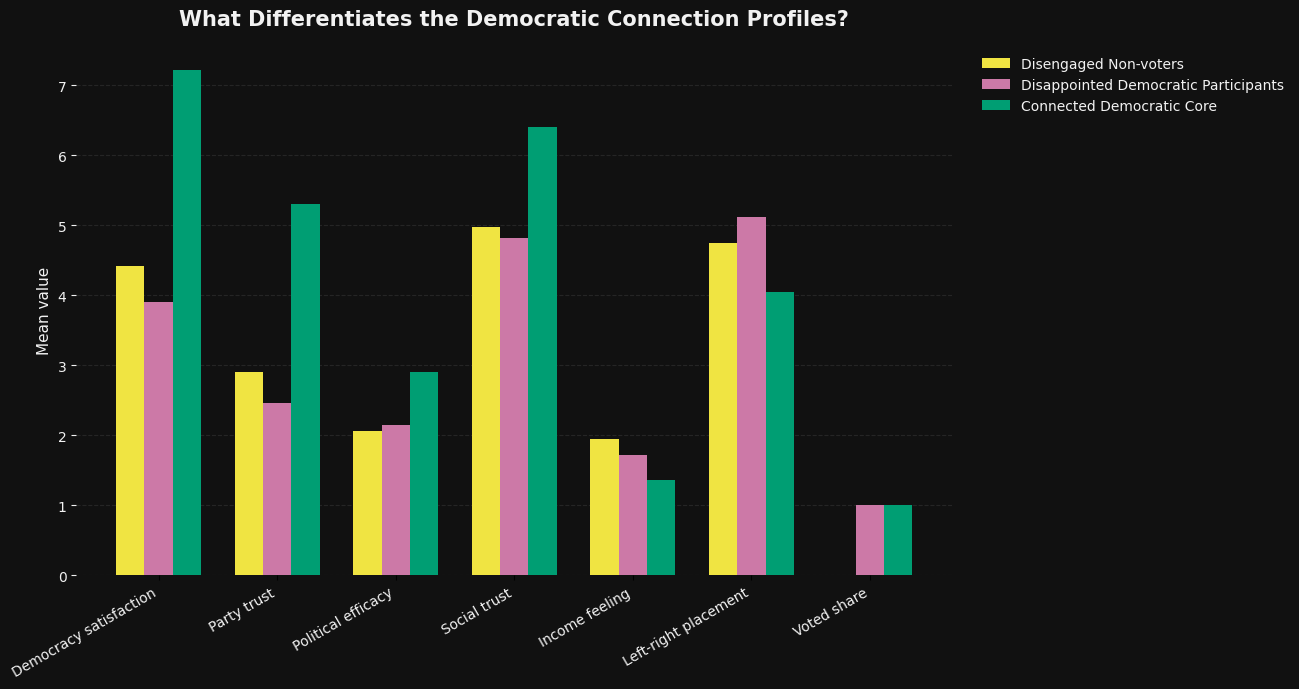

In [142]:
# 65.2b Plot profile characteristics

indicator_order = [
    "Democracy satisfaction",
    "Party trust",
    "Political efficacy",
    "Social trust",
    "Income feeling",
    "Left-right placement",
    "Voted share"
]

profiles_order = [
    "Disengaged Non-voters",
    "Disappointed Democratic Participants",
    "Connected Democratic Core"
]

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

x = np.arange(len(indicator_order))
width = 0.24

for i, profile in enumerate(profiles_order):
    data = (
        profile_characteristics_long[
            profile_characteristics_long["democratic_connection_profile"] == profile
        ]
        .set_index("indicator_label")
        .loc[indicator_order]
    )
    
    ax.bar(
        x + (i - 1) * width,
        data["mean_value"],
        width=width,
        label=profile,
        color=profile_colors.get(profile, "#56B4E9")
    )

ax.set_title(
    "What Differentiates the Democratic Connection Profiles?",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_ylabel("Mean value", color=text_col, fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(indicator_order, rotation=30, ha="right", color=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "12_democratic_connection_profile_characteristics_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### 65.3 Create normalized profile heatmap table

This step creates a normalized profile table.

The purpose is to compare profile characteristics more fairly across variables with different scales.

Each selected indicator is standardized using z-scores. Positive values indicate that a profile is above the sample average for that indicator. Negative values indicate that a profile is below the sample average.

This table is especially useful for profile interpretation and app-style visualizations.

In [143]:
# 65.3 Create normalized profile heatmap table

profile_indicator_vars = [
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "vote_binary"
]

profile_indicator_labels = {
    "stfdem": "Democracy satisfaction",
    "trstprt": "Party trust",
    "political_efficacy_index": "Political efficacy",
    "social_trust_index": "Social trust",
    "hincfel": "Income feeling",
    "lrscale": "Left-right placement",
    "vote_binary": "Voting participation"
}

df_profile_z = df_clustered[
    ["democratic_connection_profile"] + profile_indicator_vars
].copy()

for var in profile_indicator_vars:
    df_profile_z[var + "_z"] = (
        df_profile_z[var] - df_profile_z[var].mean()
    ) / df_profile_z[var].std(ddof=0)

z_vars = [var + "_z" for var in profile_indicator_vars]

profile_z_summary = (
    df_profile_z
    .groupby("democratic_connection_profile")[z_vars]
    .mean()
    .rename(columns={var + "_z": profile_indicator_labels[var] for var in profile_indicator_vars})
    .loc[profiles_order]
    .round(2)
)

profile_z_summary

,Democracy satisfaction,Party trust,Political efficacy,Social trust,Income feeling,Left-right placement,Voting participation
democratic_connection_profile,,,,,,,
Disengaged Non-voters,-0.47,-0.47,-0.64,-0.40,0.59,0.12,-2.84
Disappointed Democratic Participants,-0.67,-0.68,-0.52,-0.50,0.24,0.33,0.35
Connected Democratic Core,0.63,0.64,0.55,0.48,-0.32,-0.28,0.35


### 65.4 Visualize normalized profile differences

This visualization shows how each Democratic Connection Profile differs from the sample average.

Values above zero mean that the profile scores above the average on that indicator. Values below zero mean that the profile scores below the average.

This chart is useful for storytelling because it shows the profile logic more clearly than raw values alone.

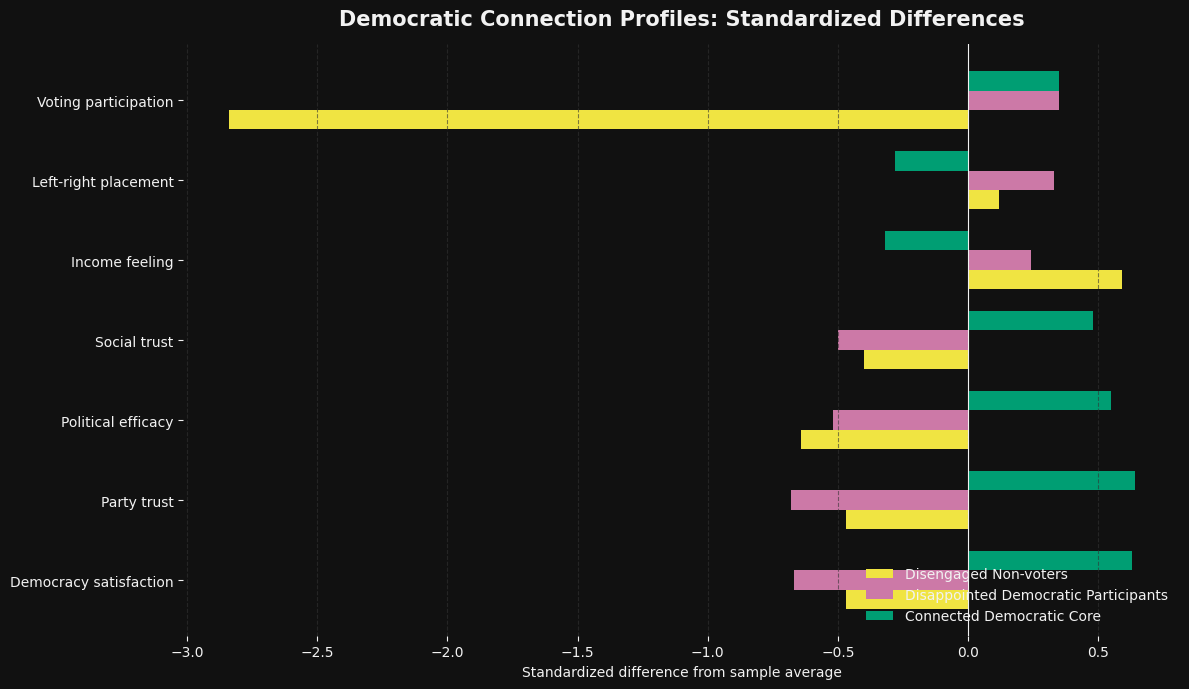

,Democracy satisfaction,Party trust,Political efficacy,Social trust,Income feeling,Left-right placement,Voting participation
democratic_connection_profile,,,,,,,
Disengaged Non-voters,-0.47,-0.47,-0.64,-0.40,0.59,0.12,-2.84
Disappointed Democratic Participants,-0.67,-0.68,-0.52,-0.50,0.24,0.33,0.35
Connected Democratic Core,0.63,0.64,0.55,0.48,-0.32,-0.28,0.35


In [144]:
# 65.4 Visualize normalized profile differences

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

y = np.arange(len(profile_z_summary.columns))
height = 0.24

for i, profile in enumerate(profiles_order):
    values = profile_z_summary.loc[profile].values
    
    ax.barh(
        y + (i - 1) * height,
        values,
        height=height,
        label=profile,
        color=profile_colors.get(profile, "#56B4E9")
    )

ax.axvline(0, color=text_col, linewidth=0.8)

ax.set_yticks(y)
ax.set_yticklabels(profile_z_summary.columns, color=text_col)

ax.set_xlabel("Standardized difference from sample average", color=text_col)
ax.set_title(
    "Democratic Connection Profiles: Standardized Differences",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(frameon=False, loc="lower right")

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "13_democratic_connection_profile_standardized_differences_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

profile_z_summary

### 65.5 Create strategic profile recommendation table

This step translates the Democratic Connection Profiles into strategic implications.

The goal is to connect the data-driven segmentation to possible democratic engagement priorities.

The recommendations are not direct causal claims. They are evidence-informed strategic interpretations based on the observed profile patterns.

In [145]:
# 65.5 Create strategic profile recommendation table

strategic_profile_table = pd.DataFrame([
    {
        "democratic_connection_profile": "Connected Democratic Core",
        "main_pattern": (
            "High democratic satisfaction, higher party trust, higher political efficacy, "
            "higher social trust and full voting participation."
        ),
        "strategic_challenge": (
            "Maintain trust and avoid taking this group for granted."
        ),
        "possible_response": (
            "Use this group as a stabilizing democratic base. Provide credible delivery, "
            "transparent communication and opportunities for meaningful participation."
        )
    },
    {
        "democratic_connection_profile": "Disappointed Democratic Participants",
        "main_pattern": (
            "Low democratic satisfaction and low party trust, but respondents still reported voting."
        ),
        "strategic_challenge": (
            "Rebuild trust before dissatisfaction turns into deeper disengagement."
        ),
        "possible_response": (
            "Focus on responsiveness, visible problem-solving, local listening formats, "
            "and credible explanations of political constraints and progress."
        )
    },
    {
        "democratic_connection_profile": "Disengaged Non-voters",
        "main_pattern": (
            "Low democratic satisfaction, low party trust, low political efficacy and no reported voting participation."
        ),
        "strategic_challenge": (
            "Lower barriers to re-engagement and rebuild basic political efficacy."
        ),
        "possible_response": (
            "Prioritize outreach beyond traditional party channels, practical participation formats, "
            "community-based trust-building and low-threshold civic engagement."
        )
    }
])

strategic_profile_table

,democratic_connection_profile,main_pattern,strategic_challenge,possible_response
0,Connected Democratic Core,"High democratic satisfaction, higher party tru...",Maintain trust and avoid taking this group for...,Use this group as a stabilizing democratic bas...
1,Disappointed Democratic Participants,Low democratic satisfaction and low party trus...,Rebuild trust before dissatisfaction turns int...,"Focus on responsiveness, visible problem-solvi..."
2,Disengaged Non-voters,"Low democratic satisfaction, low party trust, ...",Lower barriers to re-engagement and rebuild ba...,Prioritize outreach beyond traditional party c...


### 65.6 Export final profile visualization tables

This step exports the final profile tables used for visualization, dashboarding and app development.

The exported files can be used in Streamlit, Tableau, final presentation slides and the project documentation.

In [146]:
# 65.6 Export final profile visualization tables

profile_summary.to_csv(
    "../data/processed/democratic_connection_profile_summary_final.csv",
    index=False
)

profile_z_summary.to_csv(
    "../data/processed/democratic_connection_profile_z_summary.csv",
    index=True
)

strategic_profile_table.to_csv(
    "../data/processed/democratic_connection_profile_strategy_table.csv",
    index=False
)

print("Final profile tables exported to ../data/processed/")

Final profile tables exported to ../data/processed/


### 65.7 Interpretation of Democratic Connection Profile visualizations

The profile visualizations strengthen the central storyline of the project.

The analysis does not show one single form of democratic disconnection. Instead, it identifies three different Democratic Connection Profiles.

The Connected Democratic Core is the largest profile. Respondents in this profile show higher democratic satisfaction, higher trust in political parties, higher perceived political efficacy, higher social trust and voting participation.

The Disappointed Democratic Participants are especially important for strategic interpretation. This group still participates electorally, but shows low democratic satisfaction, low party trust, lower political efficacy and lower social trust. This suggests that democratic participation can coexist with strong dissatisfaction.

The Disengaged Non-voters show the clearest disengagement pattern because low democratic connection is combined with non-voting. This group may require different engagement strategies than disappointed voters.

The profile analysis supports the main project argument: different democratic trust problems require different democratic responses.

For democratic actors, this means that strategy should not only focus on general communication. It should distinguish between maintaining democratic connection, rebuilding trust among disappointed participants and lowering barriers for disengaged non-voters.

The cluster analysis is exploratory and does not prove causality. However, it provides a useful segmentation framework for storytelling, dashboard development and evidence-informed democratic engagement recommendations.

## 66. Create final app-ready and dashboard-ready datasets

This step consolidates the final analytical outputs into clean files that can be used for Streamlit, Tableau, GitHub documentation and the final presentation.

The previous sections created several important outputs:

- validated trust gap results
- regression results
- Democratic Connection Profiles
- normalized profile summaries
- strategic recommendation tables

This step creates a final export layer so that the analytical results can be reused without rerunning the full notebook.

The exported files are designed for:

- interactive Streamlit app development
- optional Tableau dashboarding
- final presentation charts
- README documentation
- reproducible project structure

The raw ESS data is not exported. Only cleaned, transformed and analysis-ready datasets are exported.

In [148]:
# 66. Create final app-ready and dashboard-ready datasets

from pathlib import Path
import pandas as pd

# Define output folders
clean_path = Path("../data/clean")
processed_path = Path("../data/processed")
app_path = Path("../data/app")

clean_path.mkdir(parents=True, exist_ok=True)
processed_path.mkdir(parents=True, exist_ok=True)
app_path.mkdir(parents=True, exist_ok=True)

print("Export folders checked or created.")

Export folders checked or created.


### 66.1 Create final respondent-level app dataset

This step creates a respondent-level dataset for app and dashboard use.

The dataset includes the most relevant variables for the final project:

- democratic satisfaction
- party trust
- political efficacy
- social trust
- income feeling
- left-right placement
- voting behavior
- Democratic Connection Profile

This file can be used in Streamlit for interactive filtering and profile exploration.

In [149]:
# 66.1 Create final respondent-level app dataset

app_respondent_dataset = df_clustered.copy()

# Add readable variable labels for app use
app_respondent_dataset = app_respondent_dataset.rename(columns={
    "stfdem": "democracy_satisfaction",
    "trstprt": "party_trust",
    "political_efficacy_index": "political_efficacy",
    "social_trust_index": "social_trust",
    "hincfel": "income_feeling",
    "lrscale": "left_right_placement",
    "vote_binary": "voted"
})

app_respondent_dataset = app_respondent_dataset[
    [
        "democratic_connection_profile",
        "democracy_satisfaction",
        "party_trust",
        "political_efficacy",
        "social_trust",
        "income_feeling",
        "left_right_placement",
        "voted"
    ]
].copy()

app_respondent_dataset.head()

,democratic_connection_profile,democracy_satisfaction,party_trust,political_efficacy,social_trust,income_feeling,left_right_placement,voted
8256,Connected Democratic Core,8.0,5.0,2.75,3.333333,1.0,5.0,1
8257,Connected Democratic Core,7.0,3.0,2.75,7.333333,2.0,3.0,1
8259,Connected Democratic Core,8.0,7.0,2.00,6.666667,1.0,5.0,1
8260,Connected Democratic Core,8.0,7.0,3.25,7.333333,1.0,6.0,1
8261,Connected Democratic Core,9.0,7.0,3.25,4.666667,2.0,3.0,1


### 66.2 Create final profile summary for app and dashboard

This step creates a final profile-level summary table.

Each row represents one Democratic Connection Profile and includes:

- number of respondents
- percentage of the analysis sample
- average democratic satisfaction
- average party trust
- average political efficacy
- average social trust
- average income feeling
- average left-right placement
- voting share

This table is useful for high-level profile cards, summary charts and presentation slides.

In [150]:
# 66.2 Create final profile summary for app and dashboard

app_profile_summary = profile_summary.copy()

app_profile_summary = app_profile_summary.sort_values(
    "percentage",
    ascending=False
).reset_index(drop=True)

app_profile_summary

,democratic_connection_profile,n_respondents,percentage,democracy_satisfaction,party_trust,political_efficacy,social_trust,income_feeling,left_right_placement,voted_share
0,Connected Democratic Core,1027,49.8,7.22,5.30,2.91,6.40,1.36,4.04,1.0
1,Disappointed Democratic Participants,810,39.2,3.91,2.46,2.14,4.82,1.72,5.12,1.0
2,Disengaged Non-voters,227,11.0,4.42,2.91,2.06,4.98,1.95,4.74,0.0


### 66.3 Create final normalized profile summary

This step creates a normalized profile summary using standardized differences from the sample average.

This table is useful because the profile indicators are measured on different scales.

Positive values mean that a profile scores above the sample average on that indicator.  
Negative values mean that a profile scores below the sample average.

This output is especially useful for heatmaps, radar-style comparisons and profile interpretation.

In [151]:
# 66.3 Create final normalized profile summary

app_profile_z_summary = profile_z_summary.copy()

app_profile_z_summary = app_profile_z_summary.reset_index()

app_profile_z_summary

,democratic_connection_profile,Democracy satisfaction,Party trust,Political efficacy,Social trust,Income feeling,Left-right placement,Voting participation
0,Disengaged Non-voters,-0.47,-0.47,-0.64,-0.40,0.59,0.12,-2.84
1,Disappointed Democratic Participants,-0.67,-0.68,-0.52,-0.50,0.24,0.33,0.35
2,Connected Democratic Core,0.63,0.64,0.55,0.48,-0.32,-0.28,0.35


### 66.4 Create final strategic recommendation table

This step prepares the strategic recommendation table for use in the final app, presentation and README.

The table translates each Democratic Connection Profile into:

- main pattern
- strategic challenge
- possible democratic response

The recommendations are evidence-informed interpretations based on observed profile patterns. They are not causal claims.

In [152]:
# 66.4 Create final strategic recommendation table

app_strategy_table = strategic_profile_table.copy()

app_strategy_table

,democratic_connection_profile,main_pattern,strategic_challenge,possible_response
0,Connected Democratic Core,"High democratic satisfaction, higher party tru...",Maintain trust and avoid taking this group for...,Use this group as a stabilizing democratic bas...
1,Disappointed Democratic Participants,Low democratic satisfaction and low party trus...,Rebuild trust before dissatisfaction turns int...,"Focus on responsiveness, visible problem-solvi..."
2,Disengaged Non-voters,"Low democratic satisfaction, low party trust, ...",Lower barriers to re-engagement and rebuild ba...,Prioritize outreach beyond traditional party c...


### 66.5 Create final trust gap summary table

This step creates a compact trust gap summary table.

The table summarizes the main validated analytical gaps:

- Participation Gap
- Political Efficacy Gap
- Social Trust Gap
- Economic Security Gap
- Political Orientation Pattern

This output is useful for storytelling, dashboard navigation and final presentation structure.

In [153]:
# 66.5 Create final trust gap summary table

app_trust_gap_summary = priority_table.copy()

app_trust_gap_summary

,priority,trust_gap,analytical_strength,strategic_relevance,reason,recommended_role_in_story
0,1,Political Efficacy Gap,Very strong,Very high,Shows large effects for trust in parliament an...,Core finding
1,2,Social Trust Gap,Strong,High,Shows medium effects across all outcomes and c...,Core finding
2,3,Participation Gap,Strong,Very high,Shows medium effects between voters and non-vo...,Core finding / political action point
3,4,Economic Security Gap,Moderate,High,Shows consistent but smaller effects; importan...,Supporting factor
4,5,Political Orientation Pattern,Weak to moderate,Medium,Shows statistically significant but small effe...,Contextual pattern


### 66.6 Create final regression summary table

This step creates a compact regression summary for the two main models:

- democratic satisfaction
- trust in political parties

The table highlights model fit and the strongest predictors.

This output is useful for explaining that the key findings remain visible after controlling for other variables.

In [154]:
# 66.6 Create final regression summary table

app_regression_summary = model_comparison.copy()

app_regression_summary

,model,outcome,n_observations,r_squared,adj_r_squared,strongest_predictor,main_interpretation
0,Democracy satisfaction,stfdem,2064,0.254,0.251,Political efficacy,Political efficacy and social trust are the st...
1,Trust in political parties,trstprt,2064,0.281,0.278,Political efficacy,Political efficacy and social trust are the st...


### 66.7 Export all final app-ready datasets

This step exports all final app-ready and dashboard-ready datasets.

The files are saved in `../data/app/` to separate final application inputs from intermediate processed outputs.

These files can be used directly in Streamlit or Tableau.

In [155]:
# 66.7 Export all final app-ready datasets

app_respondent_dataset.to_csv(
    app_path / "app_respondent_level_profiles.csv",
    index=False
)

app_profile_summary.to_csv(
    app_path / "app_profile_summary.csv",
    index=False
)

app_profile_z_summary.to_csv(
    app_path / "app_profile_z_summary.csv",
    index=False
)

app_strategy_table.to_csv(
    app_path / "app_strategy_table.csv",
    index=False
)

app_trust_gap_summary.to_csv(
    app_path / "app_trust_gap_summary.csv",
    index=False
)

app_regression_summary.to_csv(
    app_path / "app_regression_summary.csv",
    index=False
)

print("Final app-ready datasets exported to ../data/app/")

Final app-ready datasets exported to ../data/app/


### 66.8 Check final exported files

This step checks whether all expected app-ready files were created successfully.

This is a simple reproducibility check before moving into Streamlit or Tableau development.

In [156]:
# 66.8 Check final exported files

exported_app_files = sorted([file.name for file in app_path.glob("*.csv")])

exported_app_files

['app_profile_summary.csv',
 'app_profile_z_summary.csv',
 'app_regression_summary.csv',
 'app_respondent_level_profiles.csv',
 'app_strategy_table.csv',
 'app_trust_gap_summary.csv']

### 66.9 Interpretation of final export layer

The final export layer prepares the project for communication and product development.

The analysis now has a clean set of reusable files for Streamlit, Tableau, presentation slides and GitHub documentation.

The most important final outputs are:

- respondent-level Democratic Connection Profile dataset
- profile summary table
- normalized profile comparison table
- strategic recommendation table
- trust gap priority table
- regression model summary table

This means the project can now move from analysis to presentation and interactive storytelling.

The next step is to build a lightweight Streamlit app that presents the project logic, key findings, Democratic Connection Profiles and strategic implications.

In [158]:
from pathlib import Path

for folder in ["../data/processed", "../data/clean"]:
    print("\n", folder)
    for file in Path(folder).glob("*.csv"):
        print(file)


 ../data/processed
../data/processed/economic_security_gap_original_groups_validation.csv
../data/processed/regression_results_democracy_satisfaction_party_trust.csv
../data/processed/social_trust_gap_validation.csv
../data/processed/outcome_correlation_summary.csv
../data/processed/final_variable_correlation_matrix.csv
../data/processed/regression_model_comparison.csv
../data/processed/analytical_priority_table.csv
../data/processed/democratic_connection_profile_summary.csv
../data/processed/participation_gap_validation.csv
../data/processed/regression_vif_results.csv
../data/processed/democratic_connection_profile_summary_final.csv
../data/processed/political_efficacy_gap_validation.csv
../data/processed/trust_gap_strength_ranking.csv
../data/processed/regression_diagnostic_summary.csv
../data/processed/economic_security_gap_binary_validation.csv
../data/processed/democratic_connection_profile_z_summary.csv
../data/processed/party_trust_correlation_ranking.csv
../data/processed/demo

## 66. PCA Map of Democratic Connection Profiles

This section translates the multidimensional Democratic Connection Profiles into a two-dimensional visual map.

The cluster model is based on several variables at the same time:

- satisfaction with democracy
- trust in political parties
- political efficacy
- social trust
- subjective income feeling
- left-right self-placement
- voting participation

Because this is difficult to visualize directly, Principal Component Analysis is used.

PCA reduces the selected clustering variables into new synthetic dimensions called principal components. These components summarize the largest patterns of variation in the data.

The first principal component captures the strongest overall pattern in the data. In this project, it is expected to represent a broad democratic connection dimension, because democratic satisfaction, party trust, political efficacy and social trust are strongly related.

The second principal component captures the next strongest pattern that is not already explained by the first component. It may help separate different forms of democratic disconnection, for example between disappointed voters and disengaged non-voters.

The PCA map is exploratory. It does not prove causal relationships and it does not replace the cluster analysis. Instead, it helps visualize whether the Democratic Connection Profiles occupy different regions of the multidimensional data space.

### 66.1 Prepare PCA input

This step prepares the data for Principal Component Analysis.

The PCA uses the same variables as the main cluster model. This ensures that the PCA map visualizes the same analytical space that was used to create the Democratic Connection Profiles.

The variables are standardized before applying PCA because they are measured on different scales. Standardization ensures that no variable dominates the PCA only because it has a larger numerical range.

In [159]:
# 66.1 Prepare PCA input

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pca_vars = [
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "vote_binary"
]

pca_var_labels = {
    "stfdem": "Democracy satisfaction",
    "trstprt": "Party trust",
    "political_efficacy_index": "Political efficacy",
    "social_trust_index": "Social trust",
    "hincfel": "Income feeling",
    "lrscale": "Left-right placement",
    "vote_binary": "Voting participation"
}

# Use the final clustered dataset created in the previous section
df_pca = df_clustered[pca_vars + ["cluster", "democratic_connection_profile"]].dropna().copy()

# Standardize PCA variables
pca_scaler = StandardScaler()
X_pca_scaled = pca_scaler.fit_transform(df_pca[pca_vars])

print("PCA dataset shape:", df_pca.shape)
df_pca.head()

PCA dataset shape: (2064, 9)


,stfdem,trstprt,political_efficacy_index,social_trust_index,hincfel,lrscale,vote_binary,cluster,democratic_connection_profile
8256,8.0,5.0,2.75,3.333333,1.0,5.0,1,1,Connected Democratic Core
8257,7.0,3.0,2.75,7.333333,2.0,3.0,1,1,Connected Democratic Core
8259,8.0,7.0,2.00,6.666667,1.0,5.0,1,1,Connected Democratic Core
8260,8.0,7.0,3.25,7.333333,1.0,6.0,1,1,Connected Democratic Core
8261,9.0,7.0,3.25,4.666667,2.0,3.0,1,1,Connected Democratic Core


### 66.2 Run PCA

This step runs Principal Component Analysis with two components.

The two components are used to create a two-dimensional map of respondents.

The explained variance ratio shows how much of the original multidimensional variation is captured by each principal component.

A higher explained variance means that the two-dimensional map represents more of the original data structure.

In [160]:
# 66.2 Run PCA

pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(X_pca_scaled)

df_pca["PC1"] = pca_components[:, 0]
df_pca["PC2"] = pca_components[:, 1]

explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "explained_variance_percent": pca.explained_variance_ratio_ * 100
}).round(3)

explained_variance

,component,explained_variance_ratio,explained_variance_percent
0,PC1,0.362,36.178
1,PC2,0.151,15.056


### 66.3 Inspect PCA loadings

This step inspects the PCA loadings.

Loadings show how strongly each original variable contributes to each principal component.

They help interpret the meaning of the PCA axes.

Positive and negative signs are not meaningful by themselves. What matters is which variables load strongly on each component and whether they point in similar or opposite directions.

If democratic satisfaction, party trust, political efficacy and social trust load strongly in the same direction on PC1, this supports interpreting PC1 as a broad democratic connection axis.

In [161]:
# 66.3 Inspect PCA loadings

pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=[pca_var_labels[var] for var in pca_vars]
).round(3)

pca_loadings

,PC1_loading,PC2_loading
Democracy satisfaction,0.491,-0.159
Party trust,0.492,-0.197
Political efficacy,0.436,0.047
Social trust,0.391,-0.107
Income feeling,-0.273,-0.561
Left-right placement,-0.194,0.520
Voting participation,0.248,0.581


### 66.4 Create PCA dataset for visualization

This step creates a clean PCA visualization dataset.

It includes the two PCA coordinates, the numerical cluster label and the final Democratic Connection Profile name.

This dataset can later be exported and used in Streamlit or Tableau.

In [162]:
# 66.4 Create PCA dataset for visualization

pca_plot_df = df_pca[
    [
        "PC1",
        "PC2",
        "cluster",
        "democratic_connection_profile"
    ] + pca_vars
].copy()

pca_plot_df = pca_plot_df.rename(columns=pca_var_labels)

pca_plot_df.head()

,PC1,PC2,cluster,democratic_connection_profile,Democracy satisfaction,Party trust,Political efficacy,Social trust,Income feeling,Left-right placement,Voting participation
8256,0.569361,0.745867,1,Connected Democratic Core,8.0,5.0,2.75,3.333333,1.0,5.0,1
8257,0.690592,-0.725763,1,Connected Democratic Core,7.0,3.0,2.75,7.333333,2.0,3.0,1
8259,1.379966,0.291138,1,Connected Democratic Core,8.0,7.0,2.00,6.666667,1.0,5.0,1
8260,2.195786,0.622099,1,Connected Democratic Core,8.0,7.0,3.25,7.333333,1.0,6.0,1
8261,1.650420,-1.006821,1,Connected Democratic Core,9.0,7.0,3.25,4.666667,2.0,3.0,1


### 66.5 Visualize PCA map

This visualization shows the Democratic Connection Profiles in a two-dimensional PCA space.

Each point represents one respondent.

The position of each point is based on the respondent's values across the selected democratic connection variables.

The color indicates the Democratic Connection Profile assigned by the cluster model.

The chart helps assess whether the profiles form recognizable areas in the data space. Some overlap is expected because political attitudes and democratic trust are complex and continuous, not perfectly separated categories.

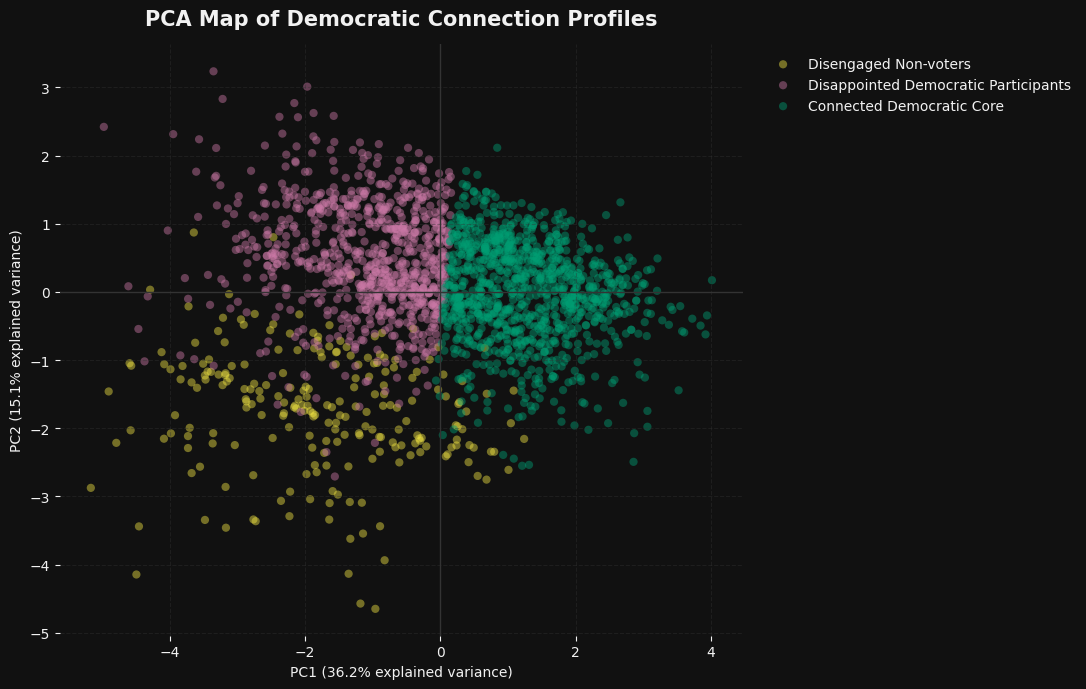

In [163]:
# 66.5 Visualize PCA map of Democratic Connection Profiles

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

profile_colors = {
    "Connected Democratic Core": "#009E73",
    "Disappointed Democratic Participants": "#CC79A7",
    "Disengaged Non-voters": "#F0E442"
}

profiles_order = [
    "Disengaged Non-voters",
    "Disappointed Democratic Participants",
    "Connected Democratic Core"
]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

for profile in profiles_order:
    data = df_pca[df_pca["democratic_connection_profile"] == profile]
    
    ax.scatter(
        data["PC1"],
        data["PC2"],
        label=profile,
        color=profile_colors.get(profile, "#56B4E9"),
        alpha=0.45,
        s=35,
        edgecolors="none"
    )

ax.axhline(0, color=grid_col, linewidth=1)
ax.axvline(0, color=grid_col, linewidth=1)

pc1_var = explained_variance.loc[explained_variance["component"] == "PC1", "explained_variance_percent"].iloc[0]
pc2_var = explained_variance.loc[explained_variance["component"] == "PC2", "explained_variance_percent"].iloc[0]

ax.set_title(
    "PCA Map of Democratic Connection Profiles",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel(f"PC1 ({pc1_var:.1f}% explained variance)", color=text_col)
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% explained variance)", color=text_col)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.4)
ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "14_pca_map_democratic_connection_profiles_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### 66.6 Add cluster centroids to the PCA map

This step adds profile centroids to the PCA map.

A centroid represents the average PCA position of each Democratic Connection Profile.

This makes the profile structure easier to read because it shows the central tendency of each group, even when individual respondents overlap.

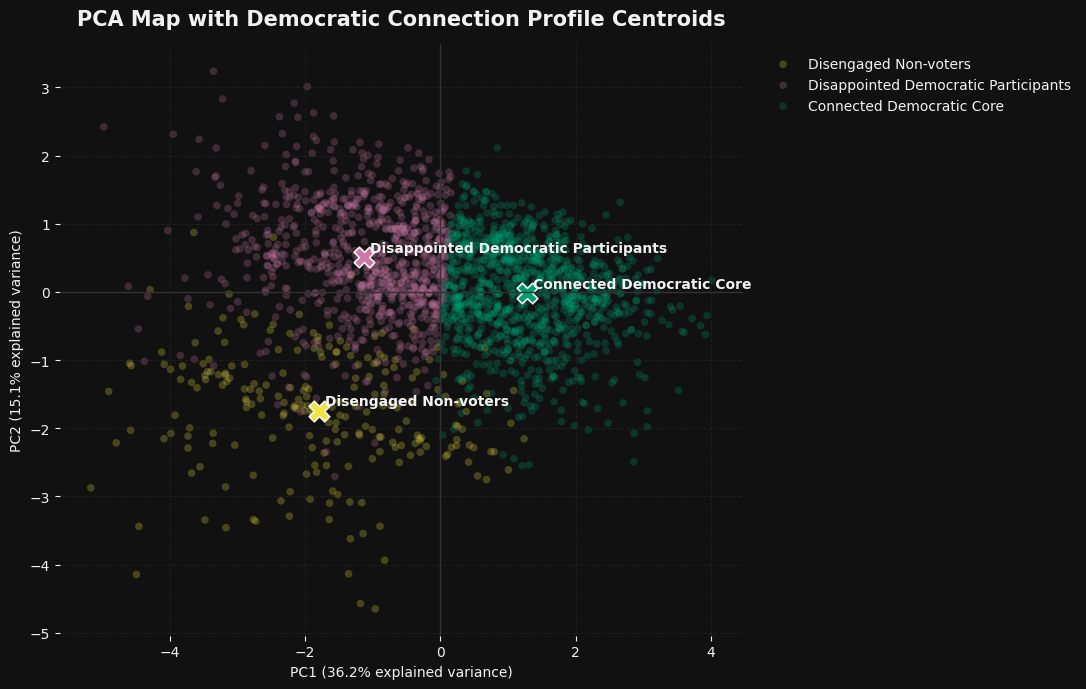

,PC1,PC2
democratic_connection_profile,,
Disengaged Non-voters,-1.79,-1.74
Disappointed Democratic Participants,-1.13,0.51
Connected Democratic Core,1.28,-0.02


In [164]:
# 66.6 Visualize PCA map with profile centroids

pca_centroids = (
    df_pca
    .groupby("democratic_connection_profile")[["PC1", "PC2"]]
    .mean()
    .loc[profiles_order]
)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

for profile in profiles_order:
    data = df_pca[df_pca["democratic_connection_profile"] == profile]
    
    ax.scatter(
        data["PC1"],
        data["PC2"],
        label=profile,
        color=profile_colors.get(profile, "#56B4E9"),
        alpha=0.25,
        s=30,
        edgecolors="none"
    )

for profile in profiles_order:
    ax.scatter(
        pca_centroids.loc[profile, "PC1"],
        pca_centroids.loc[profile, "PC2"],
        color=profile_colors.get(profile, "#56B4E9"),
        s=220,
        edgecolor=text_col,
        linewidth=1.2,
        marker="X"
    )
    
    ax.text(
        pca_centroids.loc[profile, "PC1"] + 0.08,
        pca_centroids.loc[profile, "PC2"] + 0.08,
        profile,
        color=text_col,
        fontsize=10,
        weight="bold"
    )

ax.axhline(0, color=grid_col, linewidth=1)
ax.axvline(0, color=grid_col, linewidth=1)

ax.set_title(
    "PCA Map with Democratic Connection Profile Centroids",
    color=text_col,
    fontsize=15,
    weight="bold",
    pad=14
)

ax.set_xlabel(f"PC1 ({pc1_var:.1f}% explained variance)", color=text_col)
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% explained variance)", color=text_col)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.4)
ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "15_pca_map_democratic_connection_profiles_centroids_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

pca_centroids.round(2)

### 66.7 Export PCA outputs

This step exports the PCA results.

The exported files can be used for Streamlit, Tableau, final visualizations and project documentation.

The respondent-level PCA file includes the PCA coordinates and profile labels.

The loading table helps interpret the meaning of the PCA axes.

The explained variance table documents how much of the original multidimensional variation is captured by the two-dimensional PCA map.

In [175]:
# 66.7 Export PCA outputs

pca_plot_df.to_csv(
    "../data/processed/democratic_connection_profiles_pca_coordinates.csv",
    index=False
)

pca_loadings.to_csv(
    "../data/processed/democratic_connection_profiles_pca_loadings.csv",
    index=True
)

explained_variance.to_csv(
    "../data/processed/democratic_connection_profiles_pca_explained_variance.csv",
    index=False
)

print("PCA coordinates exported to ../data/processed/")
print("PCA loadings exported to ../data/processed/")
print("PCA explained variance exported to ../data/processed/")

PCA coordinates exported to ../data/processed/
PCA loadings exported to ../data/processed/
PCA explained variance exported to ../data/processed/


### 66.8 Interpretation of the PCA results

The PCA results support the interpretation of the Democratic Connection Profiles.

The first principal component explains 36.2 percent of the variation in the selected profile variables. The loadings show that democracy satisfaction, party trust, political efficacy and social trust all load strongly and positively on this component. This suggests that PC1 can be interpreted as a broad democratic connection axis.

Respondents with higher PC1 values tend to report higher democratic satisfaction, higher trust in political parties, higher perceived political efficacy and higher social trust. Respondents with lower PC1 values tend to show weaker democratic connection.

The second principal component explains 15.1 percent of the variation. Its loadings are more mixed. It is mainly shaped by voting participation, subjective income feeling and left-right self-placement. Therefore, PC2 should not be interpreted as one simple trust dimension. Instead, it helps distinguish different forms of democratic disconnection.

The PCA map shows that the Connected Democratic Core is mainly located on the positive side of PC1. This is consistent with its higher democratic satisfaction, higher party trust, higher political efficacy and higher social trust.

The Disappointed Democratic Participants are mainly located on the negative side of PC1 but tend to differ from Disengaged Non-voters along PC2. This supports the strategic distinction between respondents who still participate electorally despite low trust and respondents who combine low trust with non-voting.

The Disengaged Non-voters are concentrated in the lower-left area of the PCA map. This reflects their lower democratic connection and their lack of reported voting participation.

Overall, the PCA does not prove that the profiles are fixed social groups. There is visible overlap between respondents, which is expected in social survey data. However, the PCA map provides a useful visual and analytical plausibility check. It shows that the Democratic Connection Profiles occupy meaningful regions in the reduced multidimensional data space.

The main interpretation is that democratic disconnection is not one single phenomenon. The PCA visualization supports the project argument that different forms of weak democratic connection require different strategic responses.

In [165]:
# 67. Enhanced PCA setup

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

viz_path = Path("../visualizations")
viz_path.mkdir(parents=True, exist_ok=True)

dark_bg = "#111111"
text_col = "#F2F2F2"
grid_col = "#333333"

profile_colors = {
    "Connected Democratic Core": "#009E73",
    "Disappointed Democratic Participants": "#CC79A7",
    "Disengaged Non-voters": "#F0E442"
}

cluster_vars = [
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "vote_binary"
]

cluster_labels = {
    "stfdem": "Democracy satisfaction",
    "trstprt": "Party trust",
    "political_efficacy_index": "Political efficacy",
    "social_trust_index": "Social trust",
    "hincfel": "Income feeling",
    "lrscale": "Left-right placement",
    "vote_binary": "Voting participation"
}

# Prepare PCA dataset
pca_source = df_clustered[
    cluster_vars + ["cluster", "democratic_connection_profile"]
].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_source[cluster_vars])

# Fit PCA with three components
pca = PCA(n_components=3, random_state=42)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2", "PC3"],
    index=pca_source.index
)

pca_df["cluster"] = pca_source["cluster"]
pca_df["democratic_connection_profile"] = pca_source["democratic_connection_profile"]

for var in cluster_vars:
    pca_df[cluster_labels[var]] = pca_source[var]

explained_variance_df = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "explained_variance_percent": pca.explained_variance_ratio_ * 100
}).round(3)

explained_variance_df

,component,explained_variance_ratio,explained_variance_percent
0,PC1,0.362,36.178
1,PC2,0.151,15.056
2,PC3,0.129,12.879


### 67.1 Interpret PCA explained variance

This step shows how much of the variation in the selected profile variables is captured by the first three principal components.

The first component usually captures the strongest underlying pattern in the data. In this project, PC1 is expected to represent a broad democratic connection dimension.

The second and third components capture additional differences between respondents that are not fully explained by PC1.

The cumulative explained variance indicates how much information is retained when the original seven variables are reduced to two or three dimensions.

In [166]:
# 67.1 PCA explained variance summary

explained_variance_df["cumulative_explained_variance_percent"] = (
    explained_variance_df["explained_variance_percent"].cumsum()
).round(1)

explained_variance_df

,component,explained_variance_ratio,explained_variance_percent,cumulative_explained_variance_percent
0,PC1,0.362,36.178,36.2
1,PC2,0.151,15.056,51.2
2,PC3,0.129,12.879,64.1


### 67.2 PCA loadings

This step shows how strongly each original variable contributes to the PCA components.

Loadings help interpret what each component means substantively.

Positive loadings indicate that a variable moves in the same direction as the component. Negative loadings indicate that a variable moves in the opposite direction.

The interpretation focuses on the strongest loadings rather than every small difference.

In [167]:
# 67.2 PCA loadings

pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading", "PC3_loading"],
    index=[cluster_labels[var] for var in cluster_vars]
).round(3)

pca_loadings

,PC1_loading,PC2_loading,PC3_loading
Democracy satisfaction,0.491,-0.159,0.211
Party trust,0.492,-0.197,0.263
Political efficacy,0.436,0.047,-0.008
Social trust,0.391,-0.107,0.178
Income feeling,-0.273,-0.561,0.132
Left-right placement,-0.194,0.520,0.813
Voting participation,0.248,0.581,-0.420


### 67.3 Interpretation of PCA dimensions

The PCA results should be interpreted as a simplified map of multidimensional democratic connection.

PC1 is the most important dimension because it explains the largest share of variation. If democracy satisfaction, party trust, political efficacy, social trust and voting participation load positively on PC1, while income difficulty loads negatively, PC1 can be interpreted as a broad democratic connection dimension.

PC2 and PC3 should be interpreted more carefully. They may separate different forms of democratic disconnection, such as economically strained respondents, more right-leaning respondents or non-voters.

The PCA map is useful because it shows whether the three Democratic Connection Profiles are visually plausible in a reduced analytical space. However, it does not prove that these profiles are fixed social groups.

### 67.4 Enhanced 2D PCA map with profile centroids

This visualization shows the Democratic Connection Profiles in the space of the first two principal components.

Each point represents one respondent. Colors represent the assigned Democratic Connection Profile.

The larger markers show the centroid of each profile in PCA space. The centroid represents the average position of each profile.

This plot is useful for static communication because it shows both overlap and separation between profiles.

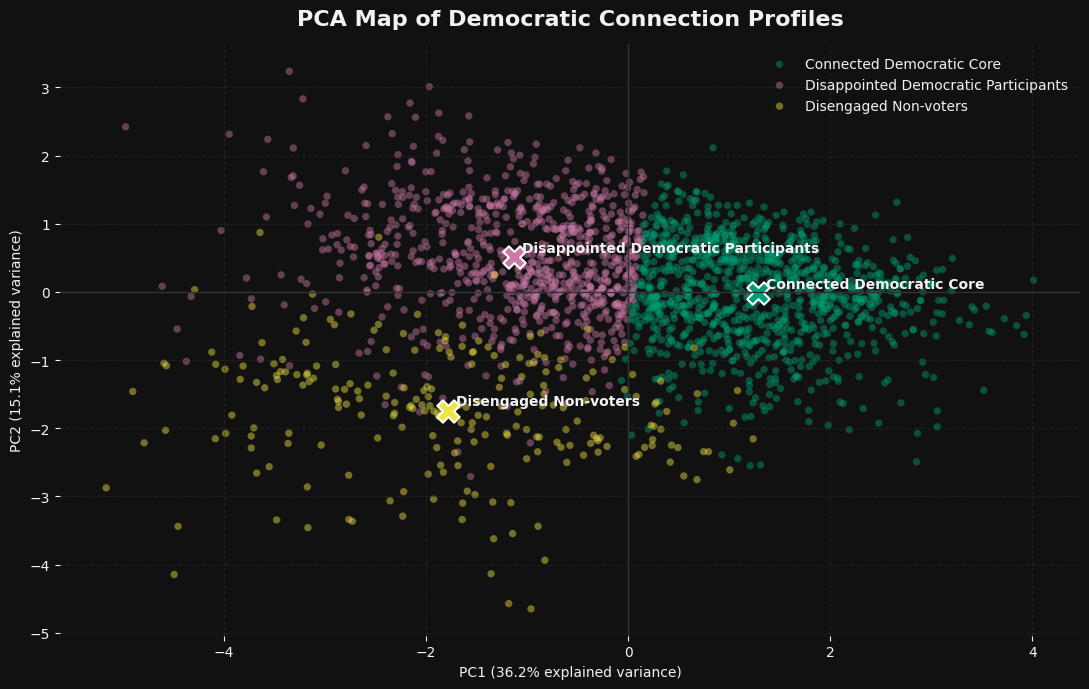

In [168]:
# 67.4 Enhanced 2D PCA map with centroids

pc1_var = explained_variance_df.loc[explained_variance_df["component"] == "PC1", "explained_variance_percent"].iloc[0]
pc2_var = explained_variance_df.loc[explained_variance_df["component"] == "PC2", "explained_variance_percent"].iloc[0]

centroids_2d = (
    pca_df
    .groupby("democratic_connection_profile")[["PC1", "PC2"]]
    .mean()
    .loc[
        [
            "Disengaged Non-voters",
            "Disappointed Democratic Participants",
            "Connected Democratic Core"
        ]
    ]
)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

for profile, data in pca_df.groupby("democratic_connection_profile"):
    ax.scatter(
        data["PC1"],
        data["PC2"],
        label=profile,
        alpha=0.45,
        s=28,
        color=profile_colors.get(profile, "#56B4E9"),
        edgecolors="none"
    )

for profile, row in centroids_2d.iterrows():
    ax.scatter(
        row["PC1"],
        row["PC2"],
        s=260,
        marker="X",
        color=profile_colors.get(profile, "#FFFFFF"),
        edgecolor="white",
        linewidth=1.5
    )
    
    ax.text(
        row["PC1"] + 0.08,
        row["PC2"] + 0.08,
        profile,
        color=text_col,
        fontsize=10,
        weight="bold"
    )

ax.axhline(0, color=grid_col, linewidth=1)
ax.axvline(0, color=grid_col, linewidth=1)

ax.set_title(
    "PCA Map of Democratic Connection Profiles",
    color=text_col,
    fontsize=16,
    weight="bold",
    pad=14
)

ax.set_xlabel(f"PC1 ({pc1_var:.1f}% explained variance)", color=text_col)
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% explained variance)", color=text_col)

ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.45)
ax.yaxis.grid(True, color=grid_col, linestyle="--", alpha=0.45)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(frameon=False, loc="upper right")

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "14_pca_2d_democratic_connection_profiles_centroids_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

## 68. Interactive 3D PCA map

This section creates an interactive 3D PCA map.

The map uses the first three principal components as axes. This allows the multidimensional structure of Democratic Connection Profiles to be explored more flexibly than in a static 2D plot.

The 3D map is especially useful for the Streamlit app because users can rotate, zoom and inspect individual points.

However, the 3D PCA map should be interpreted as an exploratory visualization. The main substantive interpretation should still be based on the validated statistical findings, profile summaries and regression results.

In [169]:
# 68. Interactive 3D PCA map using Plotly

import plotly.express as px

pc3_var = explained_variance_df.loc[explained_variance_df["component"] == "PC3", "explained_variance_percent"].iloc[0]

pca_plotly_df = pca_df.copy()

fig_3d = px.scatter_3d(
    pca_plotly_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="democratic_connection_profile",
    color_discrete_map=profile_colors,
    opacity=0.72,
    hover_data={
        "democratic_connection_profile": True,
        "Democracy satisfaction": ":.1f",
        "Party trust": ":.1f",
        "Political efficacy": ":.2f",
        "Social trust": ":.2f",
        "Income feeling": ":.1f",
        "Left-right placement": ":.1f",
        "Voting participation": True,
        "PC1": ":.2f",
        "PC2": ":.2f",
        "PC3": ":.2f"
    },
    title="Interactive 3D PCA Map of Democratic Connection Profiles"
)

fig_3d.update_traces(
    marker=dict(size=4)
)

fig_3d.update_layout(
    template="plotly_dark",
    paper_bgcolor="#111111",
    plot_bgcolor="#111111",
    font=dict(color="#F2F2F2"),
    legend_title_text="Democratic Connection Profile",
    scene=dict(
        xaxis_title=f"PC1 ({pc1_var:.1f}%)",
        yaxis_title=f"PC2 ({pc2_var:.1f}%)",
        zaxis_title=f"PC3 ({pc3_var:.1f}%)"
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    height=750
)

fig_3d.show()

### 68.1 Export interactive 3D PCA map

This step exports the interactive 3D PCA visualization as an HTML file.

The exported HTML file can be opened in a browser and can also serve as a reference for the Streamlit version of the visualization.

In [170]:
# 68.1 Export interactive 3D PCA map

html_output_path = viz_path / "15_interactive_3d_pca_democratic_connection_profiles.html"

fig_3d.write_html(html_output_path)

print(f"Interactive 3D PCA map exported to: {html_output_path}")

Interactive 3D PCA map exported to: ../visualizations/15_interactive_3d_pca_democratic_connection_profiles.html


### 68.2 Interpretation of the 3D PCA map

The 3D PCA map adds an exploratory layer to the profile analysis.

It shows how the three Democratic Connection Profiles are positioned when the seven profile variables are reduced to three principal components.

The visualization is useful because it allows profile overlap and profile separation to be inspected interactively.

The map should not be interpreted as a precise statistical proof of cluster quality. Instead, it helps communicate the multidimensional structure behind the profile segmentation.

If the Connected Democratic Core appears more clearly separated along PC1, this supports the interpretation that PC1 reflects a broad democratic connection dimension.

If Disengaged Non-voters separate more strongly along PC2 or PC3, this indicates that non-voting adds a distinct participation dimension to the profile structure.

In [176]:
# 68.3 Export PCA files for Streamlit app compatibility

from pathlib import Path

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Export PCA respondent-level coordinates for Streamlit
pca_df.to_csv(
    processed_path / "pca_democratic_connection_profiles.csv",
    index=False
)

# Export PCA loadings for Streamlit
pca_loadings.to_csv(
    processed_path / "pca_component_loadings.csv",
    index=True
)

# Export PCA explained variance for Streamlit
explained_variance_df.to_csv(
    processed_path / "pca_explained_variance.csv",
    index=False
)

print("Streamlit PCA files exported successfully:")
print(processed_path / "pca_democratic_connection_profiles.csv")
print(processed_path / "pca_component_loadings.csv")
print(processed_path / "pca_explained_variance.csv")

Streamlit PCA files exported successfully:
../data/processed/pca_democratic_connection_profiles.csv
../data/processed/pca_component_loadings.csv
../data/processed/pca_explained_variance.csv


## 69. Standardized Profile Difference Chart

This section creates a final standardized profile comparison chart.

Compared with the PCA map, this visualization is more directly interpretable. It shows how each Democratic Connection Profile differs from the sample average on the core analytical variables.

Values above zero indicate that a profile is above the sample average. Values below zero indicate that a profile is below the sample average.

This chart is especially important for the final storyline because it translates the technical cluster solution into substantive differences between profiles.

In [171]:
# 69. Standardized Profile Difference Chart

profile_indicator_vars = [
    "stfdem",
    "trstprt",
    "political_efficacy_index",
    "social_trust_index",
    "hincfel",
    "lrscale",
    "vote_binary"
]

profile_indicator_labels = {
    "stfdem": "Democracy satisfaction",
    "trstprt": "Party trust",
    "political_efficacy_index": "Political efficacy",
    "social_trust_index": "Social trust",
    "hincfel": "Income difficulty",
    "lrscale": "Left-right placement",
    "vote_binary": "Voting participation"
}

profiles_order = [
    "Disengaged Non-voters",
    "Disappointed Democratic Participants",
    "Connected Democratic Core"
]

df_profile_z = df_clustered[
    ["democratic_connection_profile"] + profile_indicator_vars
].copy()

for var in profile_indicator_vars:
    df_profile_z[var + "_z"] = (
        df_profile_z[var] - df_profile_z[var].mean()
    ) / df_profile_z[var].std(ddof=0)

z_vars = [var + "_z" for var in profile_indicator_vars]

profile_z_summary = (
    df_profile_z
    .groupby("democratic_connection_profile")[z_vars]
    .mean()
    .rename(columns={var + "_z": profile_indicator_labels[var] for var in profile_indicator_vars})
    .loc[profiles_order]
    .round(2)
)

profile_z_summary

,Democracy satisfaction,Party trust,Political efficacy,Social trust,Income difficulty,Left-right placement,Voting participation
democratic_connection_profile,,,,,,,
Disengaged Non-voters,-0.47,-0.47,-0.64,-0.40,0.59,0.12,-2.84
Disappointed Democratic Participants,-0.67,-0.68,-0.52,-0.50,0.24,0.33,0.35
Connected Democratic Core,0.63,0.64,0.55,0.48,-0.32,-0.28,0.35


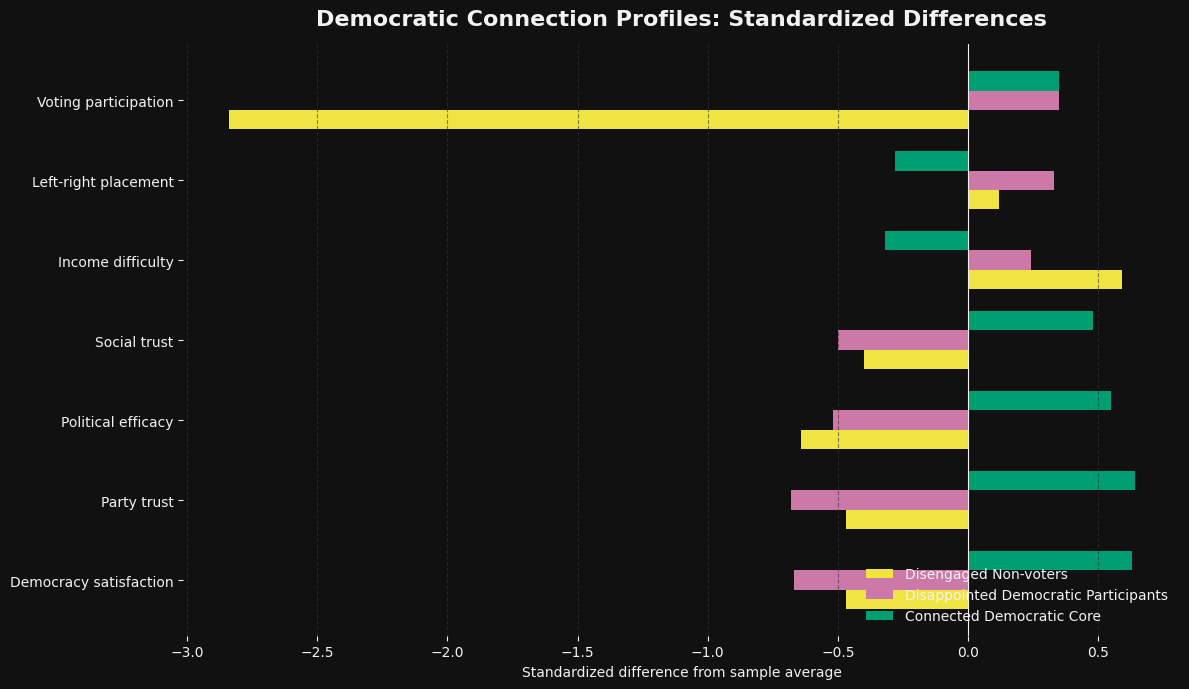

In [172]:
# 69.1 Visualize standardized profile differences

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

y = np.arange(len(profile_z_summary.columns))
height = 0.24

for i, profile in enumerate(profiles_order):
    values = profile_z_summary.loc[profile].values
    
    ax.barh(
        y + (i - 1) * height,
        values,
        height=height,
        label=profile,
        color=profile_colors.get(profile, "#56B4E9")
    )

ax.axvline(0, color=text_col, linewidth=0.8)

ax.set_yticks(y)
ax.set_yticklabels(profile_z_summary.columns, color=text_col)

ax.set_xlabel("Standardized difference from sample average", color=text_col)
ax.set_title(
    "Democratic Connection Profiles: Standardized Differences",
    color=text_col,
    fontsize=16,
    weight="bold",
    pad=14
)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(frameon=False, loc="lower right")

for text in legend.get_texts():
    text.set_color(text_col)

plt.tight_layout()

plt.savefig(
    viz_path / "16_profile_standardized_differences_final_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### 69.2 Interpretation of standardized profile differences

The standardized profile chart is one of the most important substantive visualizations in the project.

It shows that the Connected Democratic Core scores above the sample average on democracy satisfaction, party trust, political efficacy and social trust.

The Disappointed Democratic Participants show below-average democratic satisfaction, party trust, political efficacy and social trust, although they still report voting. This is strategically important because democratic dissatisfaction is visible even among electoral participants.

The Disengaged Non-voters show low democratic connection combined with no reported voting participation. This profile is distinct because disengagement is not only attitudinal, but also behavioral.

This chart supports the core project argument: democratic disconnection is not one single problem. Different profiles show different combinations of low trust, low efficacy, lower social confidence and participation behavior.

## 70. Regression Coefficient Evidence Plot

This section creates a final regression coefficient plot.

The purpose is to show which variables remain associated with democratic satisfaction and trust in political parties after controlling for other predictors.

This visualization complements the profile analysis. The profile analysis shows different types of democratic connection. The regression models show which variables are most strongly associated with the main outcomes.

The plot includes confidence intervals. If a confidence interval crosses zero, the coefficient should be interpreted as statistically uncertain.

The models remain associational and do not imply causality.

In [173]:
# 70. Prepare regression coefficient plot

regression_plot_df = regression_results_df.copy()

regression_plot_df = regression_plot_df[
    regression_plot_df["term"] != "Intercept"
].copy()

term_labels = {
    "C(gndr)[T.2.0]": "Gender",
    "political_efficacy_index_z": "Political efficacy",
    "social_trust_index_z": "Social trust",
    "hincfel_z": "Income difficulty",
    "lrscale_z": "Left-right placement",
    "eduyrs_z": "Education",
    "agea_z": "Age",
    "vote_binary": "Voted"
}

regression_plot_df["label"] = regression_plot_df["term"].map(term_labels)

regression_plot_df["significance"] = np.where(
    regression_plot_df["p_value"] < 0.05,
    "p < 0.05",
    "not significant"
)

regression_plot_df[[
    "model",
    "label",
    "coefficient",
    "p_value",
    "conf_low",
    "conf_high",
    "significance"
]]

,model,label,coefficient,p_value,conf_low,conf_high,significance
1,Democracy satisfaction,Gender,-0.087,0.38291,-0.282,0.108,not significant
2,Democracy satisfaction,Political efficacy,0.758,0.00000,0.647,0.870,p < 0.05
3,Democracy satisfaction,Social trust,0.626,0.00000,0.514,0.738,p < 0.05
4,Democracy satisfaction,Income difficulty,-0.257,0.00000,-0.363,-0.151,p < 0.05
5,Democracy satisfaction,Left-right placement,-0.246,0.00001,-0.357,-0.135,p < 0.05
6,Democracy satisfaction,Education,-0.051,0.32778,-0.154,0.052,not significant
7,Democracy satisfaction,Age,0.026,0.60638,-0.072,0.123,not significant
8,Democracy satisfaction,Voted,0.327,0.06767,-0.024,0.677,not significant
10,Trust in political parties,Gender,0.267,0.00127,0.105,0.430,p < 0.05
11,Trust in political parties,Political efficacy,0.730,0.00000,0.633,0.826,p < 0.05


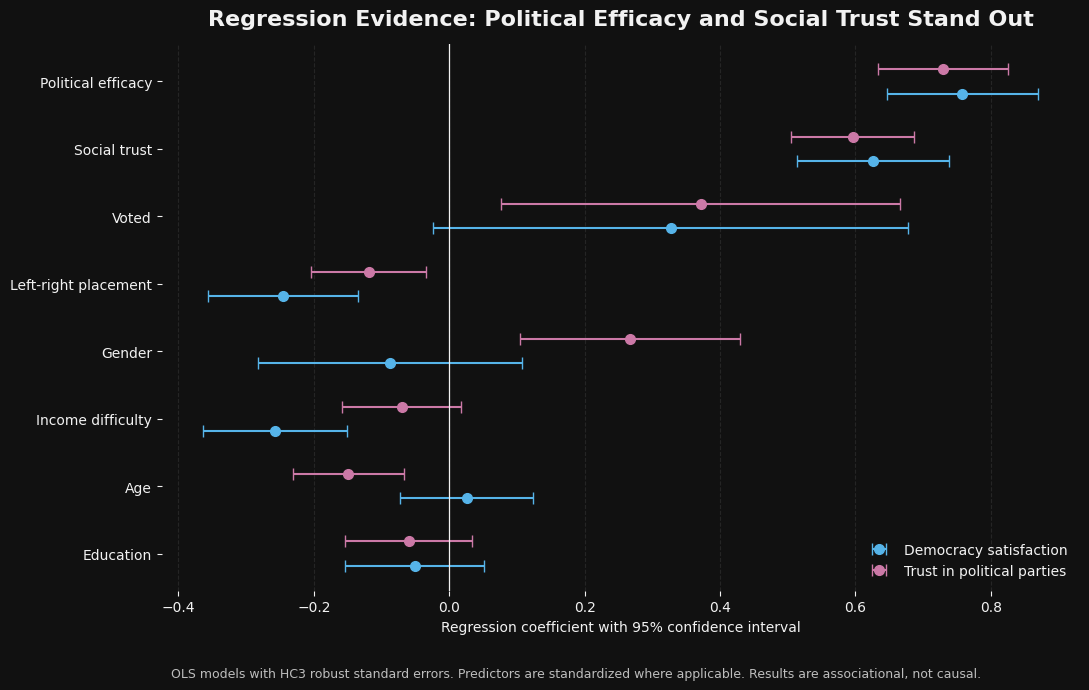

In [174]:
# 70.1 Visualize regression coefficients with confidence intervals

order = (
    regression_plot_df
    .groupby("label")["coefficient"]
    .apply(lambda x: x.abs().mean())
    .sort_values(ascending=True)
    .index
)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

models = [
    "Democracy satisfaction",
    "Trust in political parties"
]

model_colors = {
    "Democracy satisfaction": "#56B4E9",
    "Trust in political parties": "#CC79A7"
}

y_positions = np.arange(len(order))
offset = 0.18

for i, model in enumerate(models):
    data = (
        regression_plot_df[regression_plot_df["model"] == model]
        .set_index("label")
        .loc[order]
    )
    
    y = y_positions + (i - 0.5) * offset * 2
    
    ax.errorbar(
        data["coefficient"],
        y,
        xerr=[
            data["coefficient"] - data["conf_low"],
            data["conf_high"] - data["coefficient"]
        ],
        fmt="o",
        capsize=4,
        markersize=7,
        label=model,
        color=model_colors[model]
    )

ax.axvline(0, color=text_col, linewidth=0.9)

ax.set_yticks(y_positions)
ax.set_yticklabels(order, color=text_col)

ax.set_xlabel("Regression coefficient with 95% confidence interval", color=text_col)
ax.set_title(
    "Regression Evidence: Political Efficacy and Social Trust Stand Out",
    color=text_col,
    fontsize=16,
    weight="bold",
    pad=14
)

ax.xaxis.grid(True, color=grid_col, linestyle="--", alpha=0.6)
ax.tick_params(axis="x", colors=text_col)
ax.tick_params(axis="y", colors=text_col)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(frameon=False, loc="lower right")

for text in legend.get_texts():
    text.set_color(text_col)

method_note = (
    "OLS models with HC3 robust standard errors. "
    "Predictors are standardized where applicable. "
    "Results are associational, not causal."
)

ax.text(
    0.01,
    -0.14,
    method_note,
    transform=ax.transAxes,
    color="#BDBDBD",
    fontsize=9,
    ha="left",
    va="top"
)

plt.tight_layout()

plt.savefig(
    viz_path / "17_regression_coefficients_final_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

### 70.2 Interpretation of regression coefficient plot

The regression coefficient plot confirms the main analytical finding.

Political efficacy and social trust are the strongest positive predictors of both democratic satisfaction and trust in political parties.

This means that respondents who feel more politically influential and who show higher social trust also tend to report higher democratic satisfaction and higher party trust, even when controlling for income feeling, left-right placement, education, age, gender and voting behavior.

Income feeling and left-right placement are associated with democratic satisfaction, but their coefficients are smaller than those of political efficacy and social trust.

For trust in political parties, voting behavior also remains relevant. Respondents who reported voting show higher party trust than respondents who did not vote.

The regression results support the project’s central argument: democratic connection is strongly linked to perceived political efficacy and social confidence, not only to demographics, ideology or economic insecurity.

The models are associational and do not prove causality.

## 67. Final Interpretation and Project Conclusion

This final section summarizes the analytical results and translates them into the main project conclusion.

The project started from the question of what builds or weakens democratic connection in Germany. Instead of treating democratic disconnection as one single problem, the analysis tested whether different dimensions of trust, efficacy, social confidence, economic security, political orientation and participation reveal different patterns.

The analysis used European Social Survey Round 11 data for Germany and moved through a structured pipeline:

1. selecting relevant democratic trust and explanatory variables
2. constructing political efficacy and social trust indices
3. exploring institutional trust patterns
4. validating trust gaps through statistical tests and effect sizes
5. estimating regression models
6. identifying Democratic Connection Profiles through clustering
7. visualizing the profile structure through PCA
8. deriving evidence-informed strategic implications

### 67.1 Main Analytical Findings

The results show that democratic connection is shaped by multiple dimensions.

First, trust in political parties and politicians is lower than trust in other institutions such as the police or the legal system. This supports the focus on party trust as a specific democratic connection issue.

Second, the Participation Gap is clearly visible. Respondents who reported voting in the last national election show higher democratic satisfaction and institutional trust than respondents who did not vote.

Third, the Political Efficacy Gap is one of the strongest analytical signals. Respondents who feel more politically influential and capable of participation show substantially higher democratic satisfaction and higher institutional trust.

Fourth, the Social Trust Gap is also meaningful. Respondents with higher social trust show higher democratic satisfaction and higher trust in parliament, politicians and political parties.

Fifth, subjective economic security is associated with democratic trust, but the effect sizes are smaller than for political efficacy, social trust and voting participation.

Sixth, political orientation is associated with trust differences, but the effects are comparatively small. This suggests that democratic connection should not be reduced to ideology alone.

### 67.2 Regression-Based Interpretation

The regression models confirm the central analytical direction of the project.

Political efficacy and social trust remain the strongest predictors of both democratic satisfaction and trust in political parties, even when controlling for income feeling, left-right placement, education, age, gender and voting behavior.

This means that the core findings are not only visible in simple group comparisons. They remain visible when several explanatory variables are considered at the same time.

The models explain around one quarter of the variation in democratic satisfaction and party trust. For cross-sectional social survey data, this is a meaningful level of explanatory power.

However, the results remain associational. The analysis does not prove that political efficacy or social trust causally produce democratic trust.

### 67.3 Democratic Connection Profiles

The cluster analysis translates the variable-based findings into exploratory Democratic Connection Profiles.

The final profile solution identifies three groups:

| Profile | Main interpretation |
|---|---|
| Connected Democratic Core | Respondents with higher democratic satisfaction, higher party trust, higher political efficacy, higher social trust and voting participation |
| Disappointed Democratic Participants | Respondents who still vote, but show low democratic satisfaction, low party trust, lower political efficacy and lower social trust |
| Disengaged Non-voters | Respondents with no reported voting participation, low political efficacy and low party trust |

The most important profile finding is that democratic disconnection is not limited to non-voters.

A large group still participates electorally but already shows low democratic satisfaction, low trust in political parties and lower political efficacy. This group is strategically important because democratic participation can coexist with strong dissatisfaction.

### 67.4 PCA-Based Interpretation

PCA was used to visualize the multidimensional profile structure.

The first principal component captures a broad democratic connection dimension. Higher values are associated with higher democratic satisfaction, higher party trust, higher political efficacy, higher social trust and voting participation.

The PCA visualization supports the profile logic, but the profiles overlap. This is expected in social survey data. Democratic attitudes are complex and do not form perfectly separated groups.

Therefore, the PCA should be interpreted as a visualization aid, not as proof of fixed population types.

### 67.5 Strategic Implications

The findings suggest that democratic actors should not rely on one generic trust-building strategy.

Different profiles imply different strategic priorities.

For the Connected Democratic Core, the main challenge is to maintain trust and avoid taking democratic support for granted.

For the Disappointed Democratic Participants, the main challenge is to rebuild trust before dissatisfaction turns into deeper disengagement. This group may require visible problem-solving, credible responsiveness, meaningful participation formats and better explanations of political constraints and progress.

For the Disengaged Non-voters, the main challenge is to lower barriers to re-engagement and rebuild basic political efficacy. This may require outreach beyond traditional party channels, community-based trust-building and low-threshold civic engagement.

### 67.6 Final Project Conclusion

The central conclusion of this project is that democratic disconnection in Germany is not one single problem.

The strongest analytical signals are political efficacy and social trust.

Non-voting matters, but the more strategically important finding is that a large group still votes while already showing low democratic satisfaction, low party trust and lower perceived political efficacy.

This supports the main project argument:

> To strengthen democracy, democratic actors should not only communicate better. They need to rebuild political efficacy, social confidence and credible democratic responsiveness.

The project therefore provides an evidence-informed framework for understanding democratic trust not only as a communication challenge, but as a broader question of political agency, social confidence and institutional responsiveness.

### 67.7 Limitations

The analysis has several limitations.

First, the data is cross-sectional. Therefore, the analysis identifies associations, not causal effects.

Second, all measures are based on survey responses. This means that results may be affected by self-reporting, recall bias or social desirability.

Third, the cluster analysis is exploratory. The Democratic Connection Profiles are analytical segmentation patterns, not fixed social groups.

Fourth, PCA is used for visualization and should not be interpreted as proof of cluster validity.

Fifth, the current analysis focuses on Germany only. Cross-country comparison could strengthen the interpretation in a future extension.

### 67.8 Possible Next Steps

Future extensions could include:

- comparing Germany with other European countries
- adding media use and political interest variables
- analyzing party choice variables if suitable
- testing regional or socio-demographic differences in more detail
- developing a more advanced Streamlit dashboard
- translating the findings into more concrete democratic engagement recommendations

For the current capstone project, the analysis provides a coherent and defensible evidence base: democratic connection appears strongest where people feel politically efficacious, socially trusting and meaningfully connected to democratic participation.

## 71. Hypothesis testing summary for app and presentation

This section consolidates the hypothesis testing results into one compact summary table.

The project tested five analytical hypotheses:

1. Participation Gap
2. Political Efficacy Gap
3. Social Trust Gap
4. Economic Security Gap
5. Political Orientation Pattern

The goal is not to verify causal hypotheses. The ESS11 data is cross-sectional survey data, so the results show associations, not causality.

The hypothesis summary table translates statistical test results into a format that can be used in the Streamlit app, README, final presentation and project documentation.

The table includes:

- hypothesis name
- expected pattern
- test used
- main statistical result
- effect size interpretation
- overall evidence assessment
- short interpretation

The wording uses "supported" instead of "verified" because the analysis tests whether the observed data is consistent with the hypotheses, not whether the hypotheses are causally proven.

In [177]:
# 71. Hypothesis testing summary for app and presentation

from pathlib import Path
import pandas as pd

app_path = Path("../data/app")
processed_path = Path("../data/processed")

app_path.mkdir(parents=True, exist_ok=True)
processed_path.mkdir(parents=True, exist_ok=True)

hypothesis_summary = pd.DataFrame([
    {
        "hypothesis_id": "H1",
        "hypothesis": "Participation Gap",
        "expected_pattern": (
            "Respondents who voted show higher democratic satisfaction and higher institutional trust "
            "than respondents who did not vote."
        ),
        "test_used": "Welch's t-test and Cohen's d",
        "main_result": (
            "Voters show higher mean scores across democracy satisfaction, trust in parliament, "
            "trust in politicians and trust in political parties."
        ),
        "effect_size_summary": "Medium effects across all tested outcomes; strongest for trust in parliament.",
        "evidence_strength": "Supported",
        "interpretation": (
            "Non-voting is associated with weaker democratic connection, but the result is associational "
            "and does not prove that low trust causes non-voting."
        )
    },
    {
        "hypothesis_id": "H2",
        "hypothesis": "Political Efficacy Gap",
        "expected_pattern": (
            "Respondents with higher perceived political efficacy show higher democratic satisfaction "
            "and higher institutional trust."
        ),
        "test_used": "Kruskal-Wallis test and epsilon-squared",
        "main_result": (
            "Trust and democratic satisfaction increase clearly from low to medium to high political efficacy groups."
        ),
        "effect_size_summary": "Medium to large effects; strongest validated signal in the project.",
        "evidence_strength": "Strongly supported",
        "interpretation": (
            "Political efficacy is one of the strongest dimensions of democratic connection. "
            "People who feel politically influential tend to show higher democratic satisfaction and party trust."
        )
    },
    {
        "hypothesis_id": "H3",
        "hypothesis": "Social Trust Gap",
        "expected_pattern": (
            "Respondents with higher social trust show higher democratic satisfaction and higher institutional trust."
        ),
        "test_used": "Kruskal-Wallis test and epsilon-squared",
        "main_result": (
            "Democratic satisfaction and institutional trust increase from low to medium to high social trust groups."
        ),
        "effect_size_summary": "Medium effects across all tested outcomes.",
        "evidence_strength": "Supported",
        "interpretation": (
            "Democratic trust is associated not only with evaluations of institutions, but also with broader social confidence."
        )
    },
    {
        "hypothesis_id": "H4",
        "hypothesis": "Economic Security Gap",
        "expected_pattern": (
            "Respondents who feel economically strained show lower democratic satisfaction and lower institutional trust."
        ),
        "test_used": "Kruskal-Wallis test, Welch's t-test and Cohen's d",
        "main_result": (
            "Economically secure or coping respondents show higher trust than economically strained respondents."
        ),
        "effect_size_summary": "Statistically significant but smaller effects than efficacy, social trust and participation.",
        "evidence_strength": "Supported, weaker",
        "interpretation": (
            "Subjective economic security matters, but it is not the strongest explanatory dimension in this project."
        )
    },
    {
        "hypothesis_id": "H5",
        "hypothesis": "Political Orientation Pattern",
        "expected_pattern": (
            "Democratic satisfaction and institutional trust differ across left, center and right self-placement groups."
        ),
        "test_used": "Kruskal-Wallis test and epsilon-squared",
        "main_result": (
            "Trust differs across political orientation groups, but the effect sizes are small."
        ),
        "effect_size_summary": "Statistically significant but small effects.",
        "evidence_strength": "Partly supported",
        "interpretation": (
            "Political orientation is associated with democratic trust, but democratic connection should not be reduced to ideology alone."
        )
    }
])

hypothesis_summary

,hypothesis_id,hypothesis,expected_pattern,test_used,main_result,effect_size_summary,evidence_strength,interpretation
0,H1,Participation Gap,Respondents who voted show higher democratic s...,Welch's t-test and Cohen's d,Voters show higher mean scores across democrac...,Medium effects across all tested outcomes; str...,Supported,Non-voting is associated with weaker democrati...
1,H2,Political Efficacy Gap,Respondents with higher perceived political ef...,Kruskal-Wallis test and epsilon-squared,Trust and democratic satisfaction increase cle...,Medium to large effects; strongest validated s...,Strongly supported,Political efficacy is one of the strongest dim...
2,H3,Social Trust Gap,Respondents with higher social trust show high...,Kruskal-Wallis test and epsilon-squared,Democratic satisfaction and institutional trus...,Medium effects across all tested outcomes.,Supported,Democratic trust is associated not only with e...
3,H4,Economic Security Gap,Respondents who feel economically strained sho...,"Kruskal-Wallis test, Welch's t-test and Cohen's d",Economically secure or coping respondents show...,Statistically significant but smaller effects ...,"Supported, weaker","Subjective economic security matters, but it i..."
4,H5,Political Orientation Pattern,Democratic satisfaction and institutional trus...,Kruskal-Wallis test and epsilon-squared,Trust differs across political orientation gro...,Statistically significant but small effects.,Partly supported,Political orientation is associated with democ...


In [178]:
# 71.1 Export hypothesis testing summary

hypothesis_summary.to_csv(
    app_path / "app_hypothesis_testing_summary.csv",
    index=False
)

hypothesis_summary.to_csv(
    processed_path / "hypothesis_testing_summary.csv",
    index=False
)

print("Hypothesis testing summary exported to:")
print(app_path / "app_hypothesis_testing_summary.csv")
print(processed_path / "hypothesis_testing_summary.csv")

Hypothesis testing summary exported to:
../data/app/app_hypothesis_testing_summary.csv
../data/processed/hypothesis_testing_summary.csv


In [180]:
# 71.2 Check exported hypothesis summary files

expected_files = [
    app_path / "app_hypothesis_testing_summary.csv",
    processed_path / "hypothesis_testing_summary.csv"
]

for file in expected_files:
    print(file, "exists:", file.exists())

../data/app/app_hypothesis_testing_summary.csv exists: True
../data/processed/hypothesis_testing_summary.csv exists: True
